# Analysis of Player Physical Profiling Data: Unravelling the nexus with on-field Performance metrics

Plan of Action

1. Data Preprocessing
2. Feature Selection
3. Descriptive Analysis
4. Statistical Analysis
5. Performance Analysis
6. Injury Risk Prediction

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Required Libraries

In [ ]:
# Required Installations
!pip install scikit-plot
!pip install Shap
!pip install transformers --upgrade
!pip install accelerate --upgrade
!pip install accelerate>=0.21.0
!pip install transformers[torch]
!pip install lime
!pip install evaluate --q


In [ ]:
# Analysis Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from scipy.stats import f_oneway
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.tools.sm_exceptions import ConvergenceWarning

# Prediction Libraries
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score,recall_score
from sklearn.metrics import f1_score,accuracy_score
from scikitplot.estimators import plot_feature_importances
from scikitplot.metrics import plot_confusion_matrix, plot_roc
import scikitplot as skplt
from sklearn.metrics import classification_report, confusion_matrix
import shap
shap.initjs()
import warnings
warnings.filterwarnings("ignore")
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
import joblib

# LLM Libraries
from lime.lime_text import LimeTextExplainer
import torch
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset
import evaluate


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 538.2/538.2 kB 8.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 297.6/297.6 kB 5.2 MB/s eta 0:00:00
  Using cached nvidia_cuda_nvrtc_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (23.7 MB)
  Using cached nvidia_cuda_runtime_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (823 kB)
  Using cached nvidia_cuda_cupti_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (14.1 MB)
  Using cached nvidia_cudnn_cu12-8.9.2.26-py3-none-manylinux1_x86_64.whl (731.7 MB)
  Using cached nvidia_cublas_cu12-12.1.3.1-py3-none-manylinux1_x86_64.whl (410.6 MB)
  Using cached nvidia_cufft_cu12-11.0.2.54-py3-none-manylinux1_x86_64.whl (121.6 MB)
  Using cached nvidia_curand_cu12-10.3.2.106-py3-none-manylinux1_x86_64.whl (56.5 MB)
  Using cached nvidia_cusolver_cu12-11.4.5.107-py3-none-manylinux1_x86_64.whl (124.2 MB)
  Using cached nvidia_cusparse_cu12-12.1.0.106-py3-none-manylinux1_x86_64.whl (196.0 MB)
  Using cached nvidia_nccl_cu12-2.19.3-py3-none-manyl

## Data Loading

Please ensure that data path matches to your path on your drive

In [ ]:
# Import the datasets from your drive
saf_df = pd.read_excel('/content/drive/MyDrive/Ddrive/Physical Profiling Data/Speed, Agility and Fitness Single Anon Data Set.xlsx')
strength_df = pd.read_excel('/content/drive/MyDrive/Ddrive/Physical Profiling Data/Strength and Power Single Anon Data Set.xlsx', sheet_name='WholeBodyStrength Data')
aerial_df = pd.read_excel('/content/drive/MyDrive/Ddrive/Physical Profiling Data/Strength and Power Single Anon Data Set.xlsx', sheet_name='Jump Test Data')
benchmarks_df = pd.read_excel('/content/drive/MyDrive/Ddrive/Benchmarks.xlsx')
gps = pd.read_excel('/content/drive/MyDrive/Ddrive/GPS Data/GPS Data Set Single Anon.xlsx')

# make the first row a columns
new_header = saf_df.iloc[0]
saf_df = saf_df[1:]
saf_df.columns = new_header

# do same for strength and Power
new_header = strength_df.iloc[0]
strength_df = strength_df[1:]
strength_df.columns = new_header

# for Aerial
new_header = aerial_df.iloc[0]
aerial_df = aerial_df[1:]
aerial_df.columns = new_header

# for GPS
new_header = gps.iloc[0]
gps = gps[1:]
gps.columns = new_header

## Data PreProcessing

### Speed, Agility and Fitness

In [ ]:
print('Unique Dates:', len(saf_df['Date of measurement'].unique()))

def data_description(df):
    # Check initial data description
    print('Number of Unique Player IDs:', len(df['PlayerID'].unique()))
    print("Total number of rows and columns are: ", df.shape)
    print("Total number of null values are: ", df.isnull().sum())  # checking if there is any null data

    # Calculate the total number of rows
    total_rows = df.shape[0]

    # Calculate the percentage of missing values in each column
    percentage_missing = (df.isnull().sum() / total_rows) * 100

    # Filter columns with missing values
    columns_with_missing_values = percentage_missing[percentage_missing > 0]

    # Display the columns with missing values
    print("Columns with missing values:")
    print(columns_with_missing_values)

# Example usage:
data_description(saf_df)

Unique Dates: 84
Number of Unique Player IDs: 179
Total number of rows and columns are:  (946, 16)
Total number of null values are:  0
Period                                              0
PlayerID                                            0
Date of measurement                                 0
Position                                           21
Age (yr)                                           30
Squad                                               1
Jump Height (cm) Recorded on OPTOJUMP             201
Jump Height (cm) recorded on Vald force plates    704
30-15 Fitness Test Score (km/h)                   444
Agility 505 Right (seconds)                       429
Agility 505 Left (seconds)                        429
Agility R/L Diff.                                 430
Sprint 5m (seconds)                               362
Sprint 10m (seconds)                              363
Sprint 20m (seconds)                              365
Sprint 30m (seconds)                              368
d

### Strength and Power

In [ ]:
print('Unique Dates:', len(strength_df['Date'].unique()))

# Data Description Example usage:
data_description(strength_df)

Unique Dates: 18
Number of Unique Player IDs: 66
Total number of rows and columns are:  (160, 27)
Total number of null values are:  0
PlayerID                                      0
Test Type                                     0
Date                                          0
Time                                          0
BW [KG]                                       0
Peak Vertical Force [N]                       0
Peak Vertical Force / BM [N/kg]               0
Peak Vertical Force [N] (L)                   0
Peak Vertical Force [N] (R)                   0
Peak Vertical Force [N] (Asym) (%)            0
Force at 200ms [N]                            0
Force at 200ms [N] (Asym) (%)                 0
RFD - 200ms [N/s]                             0
RFD - 200ms [N/s] (Asym) (%)                  0
Force at 200ms [N] (L)                        0
Force at 200ms [N] (R)                        0
Absolute Impulse - 200ms [N s]                0
Impulse (Net of BW) - 200ms [N s]             0
Ab

In [ ]:
Test_data = {}

for test in strength_df['Test Type']:
  Test_data[test] = strength_df[strength_df['Test Type'] == test]


rfd_df = Test_data['IMTP RFD TRIAL']

print("total number of rows and columns are: ", rfd_df.shape)
#print(rfd_df.isnull().sum())  # checking if there is any null data
#rfd_df.info()  # this shows that there are no missing data from any column.

max_force_df = Test_data['IMTP MAX FORCE TRIAL']
#max_force_df.info()

total number of rows and columns are:  (79, 27)


### Aerial (Jump Ability)

In [ ]:
print('Unique Dates:', len(aerial_df['Date'].unique()))

# Data Description Example usage:
data_description(aerial_df)

Unique Dates: 141
Number of Unique Player IDs: 155
Total number of rows and columns are:  (1180, 32)
Total number of null values are:  0
PlayerID                                      0
Test Type                                     0
Date                                          0
Time                                          0
BW [KG]                                       0
Jump Height (Imp-Mom) [cm]                    0
RSI-modified (Imp-Mom) [m/s]                  0
Takeoff Peak Force [N]                        0
Takeoff Peak Force [N] (Asym) (%)             0
Countermovement Depth [cm]                    0
Eccentric Duration [ms]                       0
Eccentric Mean Power / BM [W/kg]              0
Concentric Peak Velocity [m/s]                0
Concentric Impulse (Abs) / BM [N s]           0
Concentric Duration [ms]                      0
Braking Phase Duration [s]                    0
Concentric Peak Force [N] (Asym) (%)          0
Concentric Mean Power                         0

### GPS Training

In [ ]:
print('Unique Dates:', len(gps['Date'].unique()))

# Data Description Example usage:
data_description(gps)

Unique Dates: 546
Number of Unique Player IDs: 152
Total number of rows and columns are:  (81829, 106)
Total number of null values are:  0
PlayerID                         0
Period Name                      0
Period Number                   72
Date                             0
Month Name                       0
                              ... 
Athlete Participation Tags    6706
ACC + DEC                       58
ACC + DEC/min                   61
Distance >85% Max Speed        395
Duration (minutes)              87
Length: 106, dtype: int64
Columns with missing values:
0
Period Number                 0.087988
Day Name                      0.028107
Position Name                 0.116096
Activity Name                 0.058659
Start Time                    0.205306
                                ...   
Athlete Participation Tags    8.195139
ACC + DEC                     0.070880
ACC + DEC/min                 0.074546
Distance >85% Max Speed       0.482714
Duration (minutes)           

### Summary Preprocessing

we find out the playerIDs present in all the dataset and use them for our analysis

In [ ]:
def filter_datasets(*datasets):
    # Initialize a set to store unique player IDs found in the first dataset
    unique_ids = set(datasets[0]['PlayerID'])

    # Iterate through the rest of the datasets and find common player IDs
    for df in datasets[1:]:
        unique_ids = unique_ids.intersection(set(df['PlayerID']))

    # Filter each dataset to keep only rows with player IDs present in all datasets
    filtered_datasets = [df[df['PlayerID'].isin(unique_ids)] for df in datasets]

    return filtered_datasets


# Example usage:
saf_common_df, rfd_common_df, max_force_common_df, aerial_common_df, gps_common_df = filter_datasets(saf_df, rfd_df, max_force_df, aerial_df, gps)

print('Total number of unique player IDs:', len(saf_common_df['PlayerID'].unique()))


Total number of unique player IDs: 59


In [ ]:
print('unique player squad:', saf_common_df['Squad'].unique())
print('unique player squad:', rfd_common_df['Squad'].unique())

nan_squad = saf_common_df[saf_common_df['Squad'].isna()]['PlayerID'].unique()

print('unique player IDs in the NaN squad:', nan_squad)

#
nan_squad = rfd_common_df[rfd_common_df['Squad'].isna()]['PlayerID'].unique()

print('unique player IDs in the NaN squad:', nan_squad)

def update_squad(df):
    # Update squad for PlayerID 77 to 'U18'
    df.loc[(df['PlayerID'] == 77) & (df['Squad'].isnull()), 'Squad'] = 'U18'

    # Update squad for PlayerID 121 to '1st Team'
    df.loc[(df['PlayerID'] == 121) & (df['Squad'].isnull()), 'Squad'] = '1st Team'

    # Update squad for PlayerID 61 to 'U21'
    df.loc[(df['PlayerID'] == 61) & (df['Squad'].isnull()), 'Squad'] = 'U21'

# Example usage:
update_squad(saf_common_df)
update_squad(rfd_common_df)
update_squad(max_force_common_df)

print('unique player squad:', saf_common_df['Squad'].unique())
print('unique player squad:', rfd_common_df['Squad'].unique())

unique player squad: ['U18' 'U23' 'U16' 'Trialist' 'U15' '1st Team' nan 'U21']
unique player squad: ['U18' 'U21' '1st Team' nan]
unique player IDs in the NaN squad: [61]
unique player IDs in the NaN squad: [77 121]
unique player squad: ['U18' 'U23' 'U16' 'Trialist' 'U15' '1st Team' 'U21']
unique player squad: ['U18' 'U21' '1st Team']


In [ ]:
# Group Players into professionals and academies
def group_players_by_squad(players_df, squad_list):
    professionals = players_df[players_df['Squad'].isin(['U23', 'Trialist', '1st Team', 'U21'])]
    academy = players_df[players_df['Squad'].isin(['U18', 'U16', 'U15'])]
    return professionals, academy

# Example usage:
pro_saf, acad_saf = group_players_by_squad(saf_common_df, ['U18', 'U23', 'U16', 'Trialist', 'U15', '1st Team', 'U21'])
pro_rfd, acad_rfd = group_players_by_squad(rfd_common_df, ['U18', 'U23', 'U16', 'Trialist', 'U15', '1st Team', 'U21'])
pro_max, acad_max = group_players_by_squad(max_force_common_df, ['U18', 'U23', 'U16', 'Trialist', 'U15', '1st Team', 'U21'])
pro_aerial, acad_aerial = group_players_by_squad(aerial_common_df, ['U18', 'U23', 'U16', 'Trialist', 'U15', '1st Team', 'U21'])

In [ ]:
# Group Players into professionals and academies
def group_players_gps_by_squad(players_df, squad_list):
    professionals = players_df[players_df['Team Name'].isin(['MFC U23', 'MFC 1st Team'])]
    academy = players_df[players_df['Team Name'].isin(['MFC U18'])]
    return professionals, academy

# Example usage:
pro_gps, acad_gps = group_players_gps_by_squad(gps_common_df, ['MFC U18', 'MFC U23', 'MFC 1st Team'])

### Clustering

Grouping players based on their playing positions. Some players may need their positions updated

In [ ]:
def update_positions(df):
    # Update position for PlayerID 77 to 'AM'
    df.loc[(df['PlayerID'] == 77) & (df['Position'].isnull()), 'Position'] = 'AM'

    # Update position for PlayerID 5 to 'ST'
    df.loc[(df['PlayerID'] == 5) & (df['Position'].isnull()), 'Position'] = 'ST'

# Example usage:
# Assuming rfd_common_df is your dataframe containing player data
update_positions(rfd_common_df)
update_positions(aerial_common_df)
update_positions(max_force_common_df)

In [ ]:
# Filter only total sessions from the training data
def filter_data_for_period(df, period_number):
    # Filter the dataframe for period number 0
    period_0_data = df[df['Period Number'] == period_number]
    return period_0_data

# Example usage:
# Assuming gps_common_df is your dataframe containing player data
gps_0 = filter_data_for_period(gps_common_df, 0)


def rename_positions(df):
    # Define a mapping dictionary
    position_mapping = {
        'Centre Back': 'CB',
        'Striker': 'ST',
        'Attacking Midfielder': 'AM',
        'Central Midfielder': 'CM',
        'GK': 'GK',
        'Full Back': 'FB',
        'Wing': 'AM',  # If 'Wing' doesn't need to be renamed
        'Wing Back': 'FB',  # Assuming 'Wing Back' is equivalent to 'Full Back'
        'Attacker': 'ST',  # Assuming 'Attacker' is equivalent to 'Striker'
        'Forward': 'ST',  # If 'Forward' doesn't need to be renamed
        'Left Back': 'FB',  # Assuming 'Left Back' is equivalent to 'Full Back'
        'Goalkeeper': 'GK',
        'Goal Keeper': 'GK',  # Assuming 'Goal Keeper' is equivalent to 'Goalkeeper'
        'Srtiker': 'ST',  # Assuming 'Srtiker' is a typo of 'Striker'
        'Central Defender': 'CB',  # Assuming 'Central Defender' is equivalent to 'Centre Back'
        'Fullback': 'FB'  # Assuming 'Fullback' is equivalent to 'Full Back'
    }

    # Map positions using the dictionary
    df['Position'] = df['Position Name'].map(position_mapping)

    # Drop rows with positions that are not in the mapping dictionary


    return df


# Example usage:
# Assuming df is your dataframe
gps_common_df1 = rename_positions(gps_0)
print(gps_common_df1['Position'].unique())

['CB' 'ST' 'AM' 'CM' 'GK' 'FB' nan]


In [ ]:
# check positions with null
def check_null_positions(df):
    # Filter dataframe for rows where Position is null
    null_positions_df = df[df['Position'].isnull()]

    # Extract unique PlayerIDs from those rows
    player_ids_with_null_position = null_positions_df['PlayerID'].unique()

    return player_ids_with_null_position

# Example usage:
# Assuming rfd_common_df is your dataframe containing player data
player_ids_with_null_position = check_null_positions(gps_common_df1)

# Print the player IDs with null position values
print("Player IDs with null position values:", player_ids_with_null_position)


# Update it
gps_common_df1['PlayerID'].unique()
def update_gps_positions(df):
    # Update position for PlayerID 58
    df.loc[(df['PlayerID'] == 58) & (df['Position'].isnull()), 'Position'] = 'CB'
    # Update position for PlayerID 22
    df.loc[(df['PlayerID'] == 22) & (df['Position'].isnull()), 'Position'] = 'CM'
    # Update position for PlayerID 3
    df.loc[(df['PlayerID'] == 3) & (df['Position'].isnull()), 'Position'] = 'CB'
    # Update position for PlayerID 101
    df.loc[(df['PlayerID'] == 101) & (df['Position'].isnull()), 'Position'] = 'FB'
    # Update position for PlayerID 46
    df.loc[(df['PlayerID'] == 46) & (df['Position'].isnull()), 'Position'] = 'CM'
    # Update position for PlayerID 51
    df.loc[(df['PlayerID'] == 51) & (df['Position'].isnull()), 'Position'] = 'CB'
    # Update position for PlayerID 52
    df.loc[(df['PlayerID'] == 52) & (df['Position'].isnull()), 'Position'] = 'FB'
    # Update position for PlayerID 76
    df.loc[(df['PlayerID'] == 76) & (df['Position'].isnull()), 'Position'] = 'AM'
    # Update position for PlayerID 115
    df.loc[(df['PlayerID'] == 115) & (df['Position'].isnull()), 'Position'] = 'FB'
    # Update position for PlayerID 134
    df.loc[(df['PlayerID'] == 134) & (df['Position'].isnull()), 'Position'] = 'AM'


# Example usage:
# Assuming rfd_common_df is your dataframe containing player data
update_gps_positions(gps_common_df1)

print(gps_common_df1['Position'].unique())

Player IDs with null position values: [58 101 3 22 46 51 52 76 115 134]
['CB' 'ST' 'AM' 'CM' 'GK' 'FB']


In [ ]:
# filling missing values as 0 as test was not taken on said date
saf_common_df = saf_common_df.fillna(0, inplace=False)
rfd_common_df = rfd_common_df.fillna(0, inplace=False)
max_force_common_df = max_force_common_df.fillna(0, inplace=False)
aerial_common_df = aerial_common_df.fillna(0, inplace=False)

In [ ]:
saf_data = {}

for test in saf_common_df['Position']:
  saf_data[test] = saf_common_df[saf_common_df['Position'] == test]


GK_saf = saf_data['GK']
CB_saf = saf_data['CB']
FB_saf = saf_data['FB']
CM_saf = saf_data['CM']
AM_saf = saf_data['AM']
ST_saf = saf_data['ST']

# Print unique player IDs for each position
print('Goalkeepers:', len(GK_saf['PlayerID'].unique()))
print('Defenders:', len(CB_saf['PlayerID'].unique()))
print('FullBacks:', len(FB_saf['PlayerID'].unique()))
print('Midfielders:', len(CM_saf['PlayerID'].unique()))
print('Attacking Midfielders:', len(AM_saf['PlayerID'].unique()))
print('Forwards:', len(ST_saf['PlayerID'].unique()))

Goalkeepers: 5
Defenders: 11
FullBacks: 12
Midfielders: 13
Attacking Midfielders: 9
Forwards: 9


In [ ]:
rfd_data = {}

for test in rfd_common_df['Position']:
  rfd_data[test] = rfd_common_df[rfd_common_df['Position'] == test]


GK_rfd = rfd_data['GK']
CB_rfd = rfd_data['CB']
FB_rfd = rfd_data['FB']
CM_rfd = rfd_data['CM']
AM_rfd = rfd_data['AM']
ST_rfd = rfd_data['ST']

# Print unique player IDs for each position
print('Goalkeepers:', len(GK_rfd['PlayerID'].unique()))
print('Defenders:', len(CB_rfd['PlayerID'].unique()))
print('FullBacks:', len(FB_rfd['PlayerID'].unique()))
print('Midfielders:', len(CM_rfd['PlayerID'].unique()))
print('Attacking Midfielders:', len(AM_rfd['PlayerID'].unique()))
print('Forwards:', len(ST_rfd['PlayerID'].unique()))

Goalkeepers: 5
Defenders: 11
FullBacks: 12
Midfielders: 13
Attacking Midfielders: 9
Forwards: 9


In [ ]:
common_id = GK_saf['PlayerID'].unique()
common_id1 = CB_saf['PlayerID'].unique()
common_id2 = FB_saf['PlayerID'].unique()
common_id3 = CM_saf['PlayerID'].unique()
common_id4 = AM_saf['PlayerID'].unique()
common_id5 = ST_saf['PlayerID'].unique()

# Filter 'GPS' based on the same grouping
GK_gps = gps_common_df1[gps_common_df1['PlayerID'].isin(common_id)]
CB_gps = gps_common_df1[gps_common_df1['PlayerID'].isin(common_id1)]
FB_gps = gps_common_df1[gps_common_df1['PlayerID'].isin(common_id2)]
CM_gps = gps_common_df1[gps_common_df1['PlayerID'].isin(common_id3)]
AM_gps = gps_common_df1[gps_common_df1['PlayerID'].isin(common_id4)]
ST_gps = gps_common_df1[gps_common_df1['PlayerID'].isin(common_id5)]

# Filter 'max_force' based on the same grouping
GK_mf = max_force_common_df[max_force_common_df['PlayerID'].isin(common_id)]
CB_mf = max_force_common_df[max_force_common_df['PlayerID'].isin(common_id1)]
FB_mf = max_force_common_df[max_force_common_df['PlayerID'].isin(common_id2)]
CM_mf = max_force_common_df[max_force_common_df['PlayerID'].isin(common_id3)]
AM_mf = max_force_common_df[max_force_common_df['PlayerID'].isin(common_id4)]
ST_mf = max_force_common_df[max_force_common_df['PlayerID'].isin(common_id5)]

# Filter 'Aerial' based on the same grouping
GK_aerial = aerial_common_df[aerial_common_df['PlayerID'].isin(common_id)]
CB_aerial = aerial_common_df[aerial_common_df['PlayerID'].isin(common_id1)]
FB_aerial = aerial_common_df[aerial_common_df['PlayerID'].isin(common_id2)]
CM_aerial = aerial_common_df[aerial_common_df['PlayerID'].isin(common_id3)]
AM_aerial = aerial_common_df[aerial_common_df['PlayerID'].isin(common_id4)]
ST_aerial = aerial_common_df[aerial_common_df['PlayerID'].isin(common_id5)]


### Clustering - Professionals/Academies

In [ ]:
#check for professionals
print('Positions: ', pro_aerial['Position'].unique())
# Calculate the total number of rows
total_rows = pro_aerial['Position'].shape[0]

# Calculate the percentage of missing values in each column
percentage_missing = (pro_aerial['Position'].isnull().sum() / total_rows) * 100

# Filter columns with missing values
columns_with_missing_values = percentage_missing[percentage_missing > 0]

# Display the columns with missing values
print("Column with missing values:")
print(columns_with_missing_values)

def update_positions(df):
    # Update position for PlayerID 77 to 'AM'
    df.loc[(df['PlayerID'] == 77) & (df['Position'].isnull()), 'Position'] = 'AM'

    # Update position for PlayerID 5 to 'ST'
    df.loc[(df['PlayerID'] == 5) & (df['Position'].isnull()), 'Position'] = 'ST'

# Example usage:
# Assuming rfd_common_df is your dataframe containing player data
update_positions(pro_aerial)

# Drop rows with positions that are not in the mapping dictionary
#rfd_common_df = rfd_common_df.dropna(subset=['Position'])

pro_aerial['Position'].unique()

Positions:  ['GK' 'CB' 'CM' 'FB' 'AM' 'ST' nan]
Column with missing values:
[5.51181102]


array(['GK', 'CB', 'CM', 'FB', 'AM', 'ST'], dtype=object)

In [ ]:
#check for academies
print('Positions: ', acad_aerial['Position'].unique())
# Calculate the total number of rows
total_rows = acad_aerial['Position'].shape[0]

# Calculate the percentage of missing values in each column
percentage_missing = (acad_aerial['Position'].isnull().sum() / total_rows) * 100

# Filter columns with missing values
columns_with_missing_values = percentage_missing[percentage_missing > 0]

# Display the columns with missing values
print("Column with missing values:")
print(columns_with_missing_values)

def update_positions(df):
    # Update position for PlayerID 77 to 'AM'
    df.loc[(df['PlayerID'] == 77) & (df['Position'].isnull()), 'Position'] = 'AM'

    # Update position for PlayerID 5 to 'ST'
    df.loc[(df['PlayerID'] == 5) & (df['Position'].isnull()), 'Position'] = 'ST'

# Example usage:
# Assuming rfd_common_df is your dataframe containing player data
update_positions(acad_aerial)
update_positions(acad_rfd)
update_positions(acad_max)
# Drop rows with positions that are not in the mapping dictionary
#rfd_common_df = rfd_common_df.dropna(subset=['Position'])

acad_aerial['Position'].unique()

Positions:  ['GK' 'AM' 'ST' 'FB' 'CM' 'CB' nan]
Column with missing values:
[2.75229358]


array(['GK', 'AM', 'ST', 'FB', 'CM', 'CB'], dtype=object)

In [ ]:
# Filter period
gps_0 = filter_data_for_period(pro_gps, 0)

pro_gps1 = rename_positions(gps_0)
print(pro_gps1['Position'].unique())

player_ids_with_null_position = check_null_positions(pro_gps1)

# Print the player IDs with null position values
print("Player IDs with null position values:", player_ids_with_null_position)

update_gps_positions(pro_gps1)

print(pro_gps1['Position'].unique())

['CB' 'ST' 'AM' 'CM' 'GK' 'FB' nan]
Player IDs with null position values: [58 101 3 22 46 51 52 76 115 134]
['CB' 'ST' 'AM' 'CM' 'GK' 'FB']


In [ ]:
# Filter period
gps_0 = filter_data_for_period(acad_gps, 0)

acad_gps1 = rename_positions(gps_0)
print(acad_gps1['Position'].unique())

player_ids_with_null_position = check_null_positions(acad_gps1)

# Print the player IDs with null position values
print("Player IDs with null position values:", player_ids_with_null_position)

update_gps_positions(acad_gps1)

print(acad_gps1['Position'].unique())

['ST' 'CB' 'AM' 'CM' 'FB' 'GK']
Player IDs with null position values: []
['ST' 'CB' 'AM' 'CM' 'FB' 'GK']


In [ ]:
pro_saf = pro_saf.fillna(0, inplace=False)
pro_rfd = pro_rfd.fillna(0, inplace=False)
pro_max = pro_max.fillna(0, inplace=False)
pro_aerial = pro_aerial.fillna(0, inplace=False)

# for academies
acad_saf = acad_saf.fillna(0, inplace=False)
acad_rfd = acad_rfd.fillna(0, inplace=False)
acad_max = acad_max.fillna(0, inplace=False)
acad_aerial = acad_aerial.fillna(0, inplace=False)


#### Professionals

In [ ]:
saf_data = {}

for test in pro_saf['Position']:
  saf_data[test] = pro_saf[pro_saf['Position'] == test]


pro_GK_saf = saf_data['GK']
pro_CB_saf = saf_data['CB']
pro_FB_saf = saf_data['FB']
pro_CM_saf = saf_data['CM']
pro_AM_saf = saf_data['AM']
pro_ST_saf = saf_data['ST']

# Print unique player IDs for each position
print('Goalkeepers:', len(pro_GK_saf['PlayerID'].unique()))
print('Defenders:', len(pro_CB_saf['PlayerID'].unique()))
print('FullBacks:', len(pro_FB_saf['PlayerID'].unique()))
print('Midfielders:', len(pro_CM_saf['PlayerID'].unique()))
print('Attacking Midfielders:', len(pro_AM_saf['PlayerID'].unique()))
print('Forwards:', len(pro_ST_saf['PlayerID'].unique()))

Goalkeepers: 5
Defenders: 8
FullBacks: 8
Midfielders: 7
Attacking Midfielders: 6
Forwards: 5


In [ ]:
common_id = pro_GK_saf['PlayerID'].unique()
common_id1 = pro_CB_saf['PlayerID'].unique()
common_id2 = pro_FB_saf['PlayerID'].unique()
common_id3 = pro_CM_saf['PlayerID'].unique()
common_id4 = pro_AM_saf['PlayerID'].unique()
common_id5 = pro_ST_saf['PlayerID'].unique()

# Filter 'GPS' based on the same grouping
pro_GK_gps = pro_gps1[pro_gps1['PlayerID'].isin(common_id)]
pro_CB_gps = pro_gps1[pro_gps1['PlayerID'].isin(common_id1)]
pro_FB_gps = pro_gps1[pro_gps1['PlayerID'].isin(common_id2)]
pro_CM_gps = pro_gps1[pro_gps1['PlayerID'].isin(common_id3)]
pro_AM_gps = pro_gps1[pro_gps1['PlayerID'].isin(common_id4)]
pro_ST_gps = pro_gps1[pro_gps1['PlayerID'].isin(common_id5)]

# Filter 'max_force' based on the same grouping
pro_GK_mf = pro_max[pro_max['PlayerID'].isin(common_id)]
pro_CB_mf = pro_max[pro_max['PlayerID'].isin(common_id1)]
pro_FB_mf = pro_max[pro_max['PlayerID'].isin(common_id2)]
pro_CM_mf = pro_max[pro_max['PlayerID'].isin(common_id3)]
pro_AM_mf = pro_max[pro_max['PlayerID'].isin(common_id4)]
pro_ST_mf = pro_max[pro_max['PlayerID'].isin(common_id5)]

# Filter 'RFD' based on the same grouping
pro_GK_rfd = pro_rfd[pro_rfd['PlayerID'].isin(common_id)]
pro_CB_rfd = pro_rfd[pro_rfd['PlayerID'].isin(common_id1)]
pro_FB_rfd = pro_rfd[pro_rfd['PlayerID'].isin(common_id2)]
pro_CM_rfd = pro_rfd[pro_rfd['PlayerID'].isin(common_id3)]
pro_AM_rfd = pro_rfd[pro_rfd['PlayerID'].isin(common_id4)]
pro_ST_rfd = pro_rfd[pro_rfd['PlayerID'].isin(common_id5)]

# Filter 'Aerial' based on the same grouping
pro_GK_aerial = pro_aerial[pro_aerial['PlayerID'].isin(common_id)]
pro_CB_aerial = pro_aerial[pro_aerial['PlayerID'].isin(common_id1)]
pro_FB_aerial = pro_aerial[pro_aerial['PlayerID'].isin(common_id2)]
pro_CM_aerial = pro_aerial[pro_aerial['PlayerID'].isin(common_id3)]
pro_AM_aerial = pro_aerial[pro_aerial['PlayerID'].isin(common_id4)]
pro_ST_aerial = pro_aerial[pro_aerial['PlayerID'].isin(common_id5)]

print(pro_AM_gps['PlayerID'].unique())
print(pro_AM_saf['PlayerID'].unique())

[76 87 134 77 128 110]
[ 77  76 134  87 128 110]


#### Academies

In [ ]:
saf_data = {}

for test in acad_saf['Position']:
  saf_data[test] = acad_saf[acad_saf['Position'] == test]


acad_GK_saf = saf_data['GK']
acad_CB_saf = saf_data['CB']
acad_FB_saf = saf_data['FB']
acad_CM_saf = saf_data['CM']
acad_AM_saf = saf_data['AM']
acad_ST_saf = saf_data['ST']

# Print unique player IDs for each position
print('Goalkeepers:', len(acad_GK_saf['PlayerID'].unique()))
print('Defenders:', len(acad_CB_saf['PlayerID'].unique()))
print('FullBacks:', len(acad_FB_saf['PlayerID'].unique()))
print('Midfielders:', len(acad_CM_saf['PlayerID'].unique()))
print('Attacking Midfielders:', len(acad_AM_saf['PlayerID'].unique()))
print('Forwards:', len(acad_ST_saf['PlayerID'].unique()))

Goalkeepers: 5
Defenders: 8
FullBacks: 8
Midfielders: 9
Attacking Midfielders: 5
Forwards: 7


In [ ]:
common_id = acad_GK_saf['PlayerID'].unique()
common_id1 = acad_CB_saf['PlayerID'].unique()
common_id2 = acad_FB_saf['PlayerID'].unique()
common_id3 = acad_CM_saf['PlayerID'].unique()
common_id4 = acad_AM_saf['PlayerID'].unique()
common_id5 = acad_ST_saf['PlayerID'].unique()

# Filter 'GPS' based on the same grouping
acad_GK_gps = acad_gps1[acad_gps1['PlayerID'].isin(common_id)]
acad_CB_gps = acad_gps1[acad_gps1['PlayerID'].isin(common_id1)]
acad_FB_gps = acad_gps1[acad_gps1['PlayerID'].isin(common_id2)]
acad_CM_gps = acad_gps1[acad_gps1['PlayerID'].isin(common_id3)]
acad_AM_gps = acad_gps1[acad_gps1['PlayerID'].isin(common_id4)]
acad_ST_gps = acad_gps1[acad_gps1['PlayerID'].isin(common_id5)]

# Filter 'max_force' based on the same grouping
acad_GK_mf = acad_max[acad_max['PlayerID'].isin(common_id)]
acad_CB_mf = acad_max[acad_max['PlayerID'].isin(common_id1)]
acad_FB_mf = acad_max[acad_max['PlayerID'].isin(common_id2)]
acad_CM_mf = acad_max[acad_max['PlayerID'].isin(common_id3)]
acad_AM_mf = acad_max[acad_max['PlayerID'].isin(common_id4)]
acad_ST_mf = acad_max[acad_max['PlayerID'].isin(common_id5)]

# Filter 'RFD' based on the same grouping
acad_GK_rfd = acad_rfd[acad_rfd['PlayerID'].isin(common_id)]
acad_CB_rfd = acad_rfd[acad_rfd['PlayerID'].isin(common_id1)]
acad_FB_rfd = acad_rfd[acad_rfd['PlayerID'].isin(common_id2)]
acad_CM_rfd = acad_rfd[acad_rfd['PlayerID'].isin(common_id3)]
acad_AM_rfd = acad_rfd[acad_rfd['PlayerID'].isin(common_id4)]
acad_ST_rfd = acad_rfd[acad_rfd['PlayerID'].isin(common_id5)]

# Filter 'Aerial' based on the same grouping
acad_GK_aerial = acad_aerial[acad_aerial['PlayerID'].isin(common_id)]
acad_CB_aerial = acad_aerial[acad_aerial['PlayerID'].isin(common_id1)]
acad_FB_aerial = acad_aerial[acad_aerial['PlayerID'].isin(common_id2)]
acad_CM_aerial = acad_aerial[acad_aerial['PlayerID'].isin(common_id3)]
acad_AM_aerial = acad_aerial[acad_aerial['PlayerID'].isin(common_id4)]
acad_ST_aerial = acad_aerial[acad_aerial['PlayerID'].isin(common_id5)]

print(acad_AM_gps['PlayerID'].unique())
print(acad_AM_saf['PlayerID'].unique())

[27 129 110 134 90]
[134 110  90  27 129]


## Feature Engineering

This involves selecting features that will be important in analysis

### Feature Selection

In [ ]:
# Feature selection for Speed, Agility and Fitness

def preprocess_saf_data(input_df):
    # Make a copy of the input DataFrame to avoid modifying the original DataFrame
    saf_df = input_df.copy()

    # Convert 'Date of measurement' column to datetime
    saf_df['Date of measurement'] = pd.to_datetime(saf_df['Date of measurement'])

    # Now, you can create the 'Month/Year' column
    saf_df['Month/Year'] = saf_df['Date of measurement'].dt.strftime('%Y-%m')

    # Group the data for jump tests
    jump_df = saf_df.groupby(['PlayerID', 'Date of measurement', 'Month/Year']).agg({
        'Jump Height (cm) Recorded on OPTOJUMP': 'mean',
        'Jump Height (cm) recorded on Vald force plates': 'mean'
    }).reset_index()

    # Group the data for speed, agility, and fitness
    saf_df_grouped = saf_df.groupby(['PlayerID', 'Date of measurement', 'Month/Year']).agg({
        'Sprint 5m (seconds)': 'mean',
        'Sprint 10m (seconds)': 'mean',
        'Sprint 20m (seconds)': 'mean',
        'Sprint 30m (seconds)': 'mean',
        '30-15 Fitness Test Score (km/h)': 'mean',
        'Agility 505 Right (seconds)': 'mean',
        'Agility 505 Left (seconds)': 'mean',
        # Add other columns as needed
    }).reset_index()

    # Calculate average agility
    saf_df_grouped['Agility_Average'] = (saf_df_grouped['Agility 505 Left (seconds)'] + saf_df_grouped['Agility 505 Right (seconds)']) / 2

    return jump_df, saf_df_grouped


# Assuming 'defense_saf' is your DataFrame
GK_jump_df, GK_saf_grouped = preprocess_saf_data(GK_saf)
CB_jump_df, CB_saf_grouped = preprocess_saf_data(CB_saf)
FB_jump_df, FB_saf_grouped = preprocess_saf_data(FB_saf)
CM_jump_df, CM_saf_grouped = preprocess_saf_data(CM_saf)
AM_jump_df, AM_saf_grouped = preprocess_saf_data(AM_saf)
ST_jump_df, ST_saf_grouped = preprocess_saf_data(ST_saf)

#ST_saf_grouped

In [ ]:
# Feature selection for Strength and Power
def preprocess_rfd_data(input_df):
    # Make a copy of the input DataFrame to avoid modifying the original DataFrame
    rfd_df = input_df.copy()

    # Convert 'Date' to Month/Year format
    rfd_df['Month/Year'] = rfd_df['Date'].dt.strftime('%Y-%m')

    # Group the data
    rfd_df_grouped = rfd_df.groupby(['PlayerID', 'Date', 'Month/Year']).agg({
        'BW [KG]': 'mean',
        'Peak Vertical Force [N] ': 'mean',
        'Force at 200ms [N] ': 'mean',
        'RFD - 200ms [N/s] ': 'mean',
        'Absolute Impulse - 200ms [N s] ': 'mean',
        'Relative Peak Force': 'mean'
        # Add other columns as needed
    }).reset_index()

    return rfd_df_grouped


# Assuming 'rfd_df' is your DataFrame
GK_rfd_grouped = preprocess_rfd_data(GK_rfd)
CB_rfd_grouped = preprocess_rfd_data(CB_rfd)
FB_rfd_grouped = preprocess_rfd_data(FB_rfd)
CM_rfd_grouped = preprocess_rfd_data(CM_rfd)
AM_rfd_grouped = preprocess_rfd_data(AM_rfd)
ST_rfd_grouped = preprocess_rfd_data(ST_rfd)

#ST_rfd_grouped

In [ ]:
# Feature selection for Strength and Power
def preprocess_mf_data(input_df):
    # Make a copy of the input DataFrame to avoid modifying the original DataFrame
    rfd_df = input_df.copy()

    # Convert 'Date' to Month/Year format
    rfd_df['Month/Year'] = rfd_df['Date'].dt.strftime('%Y-%m')

    # Group the data
    rfd_df_grouped = rfd_df.groupby(['PlayerID', 'Date', 'Month/Year']).agg({
        'BW [KG]': 'mean',
        'Peak Vertical Force [N] ': 'mean',
        'Force at 200ms [N] ': 'mean',
        'RFD - 200ms [N/s] ': 'mean',
        'Absolute Impulse - 200ms [N s] ': 'mean',
        'Relative Peak Force': 'mean'
        # Add other columns as needed
    }).reset_index()

    return rfd_df_grouped


# Assuming 'rfd_df' is your DataFrame
GK_mf_grouped = preprocess_mf_data(GK_mf)
CB_mf_grouped = preprocess_mf_data(CB_mf)
FB_mf_grouped = preprocess_mf_data(FB_mf)
CM_mf_grouped = preprocess_mf_data(CM_mf)
AM_mf_grouped = preprocess_mf_data(AM_mf)
ST_mf_grouped = preprocess_mf_data(ST_mf)

#ST_mf_grouped

In [ ]:
selected_cols = ['PlayerID', 'Peak Vertical Force [N] ', 'Force at 200ms [N] ', 'Relative Peak Force']
GK_max = GK_mf_grouped[selected_cols].copy()
CB_max = CB_mf_grouped[selected_cols].copy()
FB_max = FB_mf_grouped[selected_cols].copy()
CM_max = CM_mf_grouped[selected_cols].copy()
AM_max = AM_mf_grouped[selected_cols].copy()
ST_max = ST_mf_grouped[selected_cols].copy()

# rename columns
GK_max = GK_max.rename(columns={"Peak Vertical Force [N] ": "Max Peak Vertical Force [N] ", "Force at 200ms [N] ": "Max Force at 200ms [N] ",
                                "Relative Peak Force": "Max Relative Peak Force" })

CB_max = CB_max.rename(columns={"Peak Vertical Force [N] ": "Max Peak Vertical Force [N] ", "Force at 200ms [N] ": "Max Force at 200ms [N] ",
                                "Relative Peak Force": "Max Relative Peak Force" })

FB_max = FB_max.rename(columns={"Peak Vertical Force [N] ": "Max Peak Vertical Force [N] ", "Force at 200ms [N] ": "Max Force at 200ms [N] ",
                                "Relative Peak Force": "Max Relative Peak Force" })

CM_max = CM_max.rename(columns={"Peak Vertical Force [N] ": "Max Peak Vertical Force [N] ", "Force at 200ms [N] ": "Max Force at 200ms [N] ",
                                "Relative Peak Force": "Max Relative Peak Force" })

AM_max = AM_max.rename(columns={"Peak Vertical Force [N] ": "Max Peak Vertical Force [N] ", "Force at 200ms [N] ": "Max Force at 200ms [N] ",
                                "Relative Peak Force": "Max Relative Peak Force" })

ST_max = ST_max.rename(columns={"Peak Vertical Force [N] ": "Max Peak Vertical Force [N] ", "Force at 200ms [N] ": "Max Force at 200ms [N] ",
                                "Relative Peak Force": "Max Relative Peak Force" })

# Merge Data

GK_rfd_grouped = pd.merge(GK_rfd_grouped, GK_max, on='PlayerID', how='outer')
CB_rfd_grouped = pd.merge(CB_rfd_grouped, CB_max, on='PlayerID', how='outer')
FB_rfd_grouped = pd.merge(FB_rfd_grouped, FB_max, on='PlayerID', how='outer')
CM_rfd_grouped = pd.merge(CM_rfd_grouped, CM_max, on='PlayerID', how='outer')
AM_rfd_grouped = pd.merge(AM_rfd_grouped, AM_max, on='PlayerID', how='outer')
ST_rfd_grouped = pd.merge(ST_rfd_grouped, ST_max, on='PlayerID', how='outer')

# Calculating player peak strength

GK_rfd_grouped['Strength'] = (GK_rfd_grouped['Peak Vertical Force [N] '] / GK_rfd_grouped['Max Peak Vertical Force [N] ']) * 100
CB_rfd_grouped['Strength'] = (CB_rfd_grouped['Peak Vertical Force [N] '] / CB_rfd_grouped['Max Peak Vertical Force [N] ']) * 100
FB_rfd_grouped['Strength'] = (FB_rfd_grouped['Peak Vertical Force [N] '] / FB_rfd_grouped['Max Peak Vertical Force [N] ']) * 100
CM_rfd_grouped['Strength'] = (CM_rfd_grouped['Peak Vertical Force [N] '] / CM_rfd_grouped['Max Peak Vertical Force [N] ']) * 100
AM_rfd_grouped['Strength'] = (AM_rfd_grouped['Peak Vertical Force [N] '] / AM_rfd_grouped['Max Peak Vertical Force [N] ']) * 100
ST_rfd_grouped['Strength'] = (ST_rfd_grouped['Peak Vertical Force [N] '] / ST_rfd_grouped['Max Peak Vertical Force [N] ']) * 100

#ST_rfd_grouped

In [ ]:
# Feature selection for Aerial

def preprocess_aerial_data(input_df):
    # Make a copy of the input DataFrame to avoid modifying the original DataFrame
    aerial_df = input_df.copy()

    # Convert 'Date' to Month/Year format
    aerial_df['Month/Year'] = aerial_df['Date'].dt.strftime('%Y-%m')

    # Group the data
    aerial_df_grouped = aerial_df.groupby(['PlayerID', 'Date', 'Time', 'Month/Year']).agg({
        'BW [KG]': 'mean',
        'Jump Height (Imp-Mom) [cm] ': 'mean',
        'Countermovement Depth [cm] ': 'mean',
        'Eccentric Duration [ms] ': 'mean',
        'Eccentric Mean Power / BM [W/kg] ': 'mean',
        'Concentric Duration [ms] ': 'mean',
        'Concentric Mean Power / BM [W/kg]': 'mean',
        'Eccentric Deceleration RFD [N/s] ': 'mean',
        'Concentric Peak Force [N] ': 'mean'
        # Add other columns as needed
    }).reset_index()

    # Calculate additional columns
    aerial_df_grouped['Jump Speed [ms]'] = aerial_df_grouped['Eccentric Duration [ms] '] + aerial_df_grouped['Concentric Duration [ms] ']
    aerial_df_grouped['Jump Mean Power/BM [W/kg]'] = aerial_df_grouped['Eccentric Mean Power / BM [W/kg] '] + aerial_df_grouped['Concentric Mean Power / BM [W/kg]']

    return aerial_df_grouped



# Assuming 'aerial_df' is your DataFrame
GK_aerial_grouped = preprocess_aerial_data(GK_aerial)
CB_aerial_grouped = preprocess_aerial_data(CB_aerial)
FB_aerial_grouped = preprocess_aerial_data(FB_aerial)
CM_aerial_grouped = preprocess_aerial_data(CM_aerial)
AM_aerial_grouped = preprocess_aerial_data(AM_aerial)
ST_aerial_grouped = preprocess_aerial_data(ST_aerial)

#ST_aerial_grouped

In [ ]:
def preprocess_gps_data(input_df):
    # Make a copy of the input DataFrame to avoid modifying the original DataFrame
    gps_df = input_df.copy()

    # Convert 'Date' to datetime format
    gps_df['Date'] = pd.to_datetime(gps_df['Date'])

    # Create 'Month/Year' column
    gps_df['Month/Year'] = gps_df['Date'].dt.to_period('M')

    # Group the data
    grouped_gps_df = gps_df.groupby(['PlayerID', 'Date', 'Month/Year']).agg({
        'Total Distance': 'mean',
        'Duration (minutes)': 'mean',
        'Meters Per Minute': 'mean',
        'HSR & Sprinting': 'mean',
        'HSR & Sprinting Per Minute': 'mean',
        'Sprinting': 'mean',
        'Sprinting Per Minute': 'mean',
        'Acceleration B3 Distance (Gen 2)': 'mean',
        'Max Speed (km/h)': 'mean',
        'High Metabolic Power Efforts': 'mean',
        'Player Load (1D Up)': 'mean',
        'Explosive Efforts': 'mean',
        'IMA CoD Left High': 'mean',
        'IMA CoD Right High': 'mean',
        'RHIE Total Bouts': 'mean',
        'RHIE Efforts Per Bout - Mean': 'mean',
        'RHIE Effort Recovery - Mean': 'mean',
        'RHIE Effort Duration - Mean': 'mean',
        'RHIE Bout Recovery - Mean': 'mean',
        'Equivalent Distance': 'mean',
        'HMLD': 'mean',
        'Meta Energy (Cal/kg)': 'mean',
        'EDI': 'mean',
        'ACC + DEC': 'mean',
        'ACC + DEC/min': 'mean',
        # Add other columns as needed
    }).reset_index()

    return grouped_gps_df


# Assuming 'gps_df' is your DataFrame
GK_gps_grouped = preprocess_gps_data(GK_gps)
CB_gps_grouped = preprocess_gps_data(CB_gps)
FB_gps_grouped = preprocess_gps_data(FB_gps)
CM_gps_grouped = preprocess_gps_data(CM_gps)
AM_gps_grouped = preprocess_gps_data(AM_gps)
ST_gps_grouped = preprocess_gps_data(ST_gps)


#ST_gps_grouped

In [ ]:
# create a physical  profile dataframe
all_gps = [GK_gps_grouped, CB_gps_grouped, FB_gps_grouped, CM_gps_grouped, AM_gps_grouped, ST_gps_grouped]
all_gps = pd.concat(all_gps, ignore_index=True)
all_gps


all_saf = [GK_saf_grouped, CB_saf_grouped, FB_saf_grouped, CM_saf_grouped, AM_saf_grouped, ST_saf_grouped]
all_saf = pd.concat(all_saf, ignore_index=True)
all_saf['Date'] = pd.to_datetime(all_saf['Date of measurement'])
all_saf = all_saf.drop(columns='Date of measurement')


all_rfd = [GK_rfd_grouped, CB_rfd_grouped, FB_rfd_grouped, CM_rfd_grouped, AM_rfd_grouped, ST_rfd_grouped]
all_rfd = pd.concat(all_rfd, ignore_index=True)

all_aerial = [GK_aerial_grouped, CB_aerial_grouped, FB_aerial_grouped, CM_aerial_grouped, AM_aerial_grouped, ST_aerial_grouped]
all_aerial = pd.concat(all_aerial, ignore_index=True)



all_phys = pd.merge(all_saf, all_rfd, on='PlayerID', how='outer')
# Combine the two date columns into a single date column
all_phys['Date'] = all_phys['Date_x'].combine_first(all_phys['Date_y'])
all_phys['Month/Year'] = all_phys['Month/Year_x'].combine_first(all_phys['Month/Year_y'])
all_phys = all_phys.drop(columns=['Date_x', 'Date_y', 'Month/Year_x', 'Month/Year_y'], inplace=False)
all_phys = pd.merge(all_phys, all_aerial, on='PlayerID', how='outer')
###
all_phys['Date'] = all_phys['Date_x'].combine_first(all_phys['Date_y'])
all_phys['Month/Year'] = all_phys['Month/Year_x'].combine_first(all_phys['Month/Year_y'])
all_phys['BW [KG]'] = all_phys['BW [KG]_x'].combine_first(all_phys['BW [KG]_y'])
all_phys = all_phys.drop(columns=['Date_x', 'Date_y', 'Month/Year_x', 'Month/Year_y', 'BW [KG]_x', 'BW [KG]_y'], inplace=False)
#all_phys.info()


### Feature Selection - Professionals/Academies

#### Professionals

In [ ]:
# Feature selection for Speed, Agility and Fitness

# Assuming 'defense_saf' is your DataFrame
pro_GK_jump_df, pro_GK_saf_grouped = preprocess_saf_data(pro_GK_saf)
pro_CB_jump_df, pro_CB_saf_grouped = preprocess_saf_data(pro_CB_saf)
pro_FB_jump_df, pro_FB_saf_grouped = preprocess_saf_data(pro_FB_saf)
pro_CM_jump_df, pro_CM_saf_grouped = preprocess_saf_data(pro_CM_saf)
pro_AM_jump_df, pro_AM_saf_grouped = preprocess_saf_data(pro_AM_saf)
pro_ST_jump_df, pro_ST_saf_grouped = preprocess_saf_data(pro_ST_saf)

#pro_ST_saf_grouped

In [ ]:
# Feature selection for Strength and Power

# Assuming 'pro_rfd_df' is your DataFrame
pro_GK_rfd_grouped = preprocess_rfd_data(pro_GK_rfd)
pro_CB_rfd_grouped = preprocess_rfd_data(pro_CB_rfd)
pro_FB_rfd_grouped = preprocess_rfd_data(pro_FB_rfd)
pro_CM_rfd_grouped = preprocess_rfd_data(pro_CM_rfd)
pro_AM_rfd_grouped = preprocess_rfd_data(pro_AM_rfd)
pro_ST_rfd_grouped = preprocess_rfd_data(pro_ST_rfd)



# Assuming 'pro_rfd_df' is your DataFrame
pro_GK_mf_grouped = preprocess_mf_data(pro_GK_mf)
pro_CB_mf_grouped = preprocess_mf_data(pro_CB_mf)
pro_FB_mf_grouped = preprocess_mf_data(pro_FB_mf)
pro_CM_mf_grouped = preprocess_mf_data(pro_CM_mf)
pro_AM_mf_grouped = preprocess_mf_data(pro_AM_mf)
pro_ST_mf_grouped = preprocess_mf_data(pro_ST_mf)

#pro_ST_mf_grouped

In [ ]:
selected_cols = ['PlayerID', 'Peak Vertical Force [N] ', 'Force at 200ms [N] ', 'Relative Peak Force']
pro_GK_max = pro_GK_mf_grouped[selected_cols].copy()
pro_CB_max = pro_CB_mf_grouped[selected_cols].copy()
pro_FB_max = pro_FB_mf_grouped[selected_cols].copy()
pro_CM_max = pro_CM_mf_grouped[selected_cols].copy()
pro_AM_max = pro_AM_mf_grouped[selected_cols].copy()
pro_ST_max = pro_ST_mf_grouped[selected_cols].copy()

# rename columns
pro_GK_max = pro_GK_max.rename(columns={"Peak Vertical Force [N] ": "Max Peak Vertical Force [N] ", "Force at 200ms [N] ": "Max Force at 200ms [N] ",
                                "Relative Peak Force": "Max Relative Peak Force" })

pro_CB_max = pro_CB_max.rename(columns={"Peak Vertical Force [N] ": "Max Peak Vertical Force [N] ", "Force at 200ms [N] ": "Max Force at 200ms [N] ",
                                "Relative Peak Force": "Max Relative Peak Force" })

pro_FB_max = pro_FB_max.rename(columns={"Peak Vertical Force [N] ": "Max Peak Vertical Force [N] ", "Force at 200ms [N] ": "Max Force at 200ms [N] ",
                                "Relative Peak Force": "Max Relative Peak Force" })

pro_CM_max = pro_CM_max.rename(columns={"Peak Vertical Force [N] ": "Max Peak Vertical Force [N] ", "Force at 200ms [N] ": "Max Force at 200ms [N] ",
                                "Relative Peak Force": "Max Relative Peak Force" })

pro_AM_max = pro_AM_max.rename(columns={"Peak Vertical Force [N] ": "Max Peak Vertical Force [N] ", "Force at 200ms [N] ": "Max Force at 200ms [N] ",
                                "Relative Peak Force": "Max Relative Peak Force" })

pro_ST_max = pro_ST_max.rename(columns={"Peak Vertical Force [N] ": "Max Peak Vertical Force [N] ", "Force at 200ms [N] ": "Max Force at 200ms [N] ",
                                "Relative Peak Force": "Max Relative Peak Force" })

# Merge Data

pro_GK_rfd_grouped = pd.merge(pro_GK_rfd_grouped, pro_GK_max, on='PlayerID', how='outer')
pro_CB_rfd_grouped = pd.merge(pro_CB_rfd_grouped, pro_CB_max, on='PlayerID', how='outer')
pro_FB_rfd_grouped = pd.merge(pro_FB_rfd_grouped, pro_FB_max, on='PlayerID', how='outer')
pro_CM_rfd_grouped = pd.merge(pro_CM_rfd_grouped, pro_CM_max, on='PlayerID', how='outer')
pro_AM_rfd_grouped = pd.merge(pro_AM_rfd_grouped, pro_AM_max, on='PlayerID', how='outer')
pro_ST_rfd_grouped = pd.merge(pro_ST_rfd_grouped, pro_ST_max, on='PlayerID', how='outer')

# Calculating player peak strength

pro_GK_rfd_grouped['Strength'] = (pro_GK_rfd_grouped['Peak Vertical Force [N] '] / pro_GK_rfd_grouped['Max Peak Vertical Force [N] ']) * 100
pro_CB_rfd_grouped['Strength'] = (pro_CB_rfd_grouped['Peak Vertical Force [N] '] / pro_CB_rfd_grouped['Max Peak Vertical Force [N] ']) * 100
pro_FB_rfd_grouped['Strength'] = (pro_FB_rfd_grouped['Peak Vertical Force [N] '] / pro_FB_rfd_grouped['Max Peak Vertical Force [N] ']) * 100
pro_CM_rfd_grouped['Strength'] = (pro_CM_rfd_grouped['Peak Vertical Force [N] '] / pro_CM_rfd_grouped['Max Peak Vertical Force [N] ']) * 100
pro_AM_rfd_grouped['Strength'] = (pro_AM_rfd_grouped['Peak Vertical Force [N] '] / pro_AM_rfd_grouped['Max Peak Vertical Force [N] ']) * 100
pro_ST_rfd_grouped['Strength'] = (pro_ST_rfd_grouped['Peak Vertical Force [N] '] / pro_ST_rfd_grouped['Max Peak Vertical Force [N] ']) * 100

#pro_ST_rfd_grouped

In [ ]:
# Feature selection for Aerial

# Assuming 'pro_aerial_df' is your DataFrame
pro_GK_aerial_grouped = preprocess_aerial_data(pro_GK_aerial)
pro_CB_aerial_grouped = preprocess_aerial_data(pro_CB_aerial)
pro_FB_aerial_grouped = preprocess_aerial_data(pro_FB_aerial)
pro_CM_aerial_grouped = preprocess_aerial_data(pro_CM_aerial)
pro_AM_aerial_grouped = preprocess_aerial_data(pro_AM_aerial)
pro_ST_aerial_grouped = preprocess_aerial_data(pro_ST_aerial)

#pro_ST_aerial_grouped

In [ ]:

# Assuming 'pro_gps_df' is your DataFrame
pro_GK_gps_grouped = preprocess_gps_data(pro_GK_gps)
pro_CB_gps_grouped = preprocess_gps_data(pro_CB_gps)
pro_FB_gps_grouped = preprocess_gps_data(pro_FB_gps)
pro_CM_gps_grouped = preprocess_gps_data(pro_CM_gps)
pro_AM_gps_grouped = preprocess_gps_data(pro_AM_gps)
pro_ST_gps_grouped = preprocess_gps_data(pro_ST_gps)


#pro_ST_gps_grouped

In [ ]:
# create a physical  profile dataframe
pro_all_gps = [pro_GK_gps_grouped, pro_CB_gps_grouped, pro_FB_gps_grouped, pro_CM_gps_grouped, pro_AM_gps_grouped, pro_ST_gps_grouped]
pro_all_gps = pd.concat(pro_all_gps, ignore_index=True)
pro_all_gps


pro_all_saf = [pro_GK_saf_grouped, pro_CB_saf_grouped, pro_FB_saf_grouped, pro_CM_saf_grouped, pro_AM_saf_grouped, pro_ST_saf_grouped]
pro_all_saf = pd.concat(pro_all_saf, ignore_index=True)
pro_all_saf['Date'] = pd.to_datetime(pro_all_saf['Date of measurement'])
pro_all_saf = pro_all_saf.drop(columns='Date of measurement')


pro_all_rfd = [pro_GK_rfd_grouped, pro_CB_rfd_grouped, pro_FB_rfd_grouped, pro_CM_rfd_grouped, pro_AM_rfd_grouped, pro_ST_rfd_grouped]
pro_all_rfd = pd.concat(pro_all_rfd, ignore_index=True)

pro_all_aerial = [pro_GK_aerial_grouped, pro_CB_aerial_grouped, pro_FB_aerial_grouped, pro_CM_aerial_grouped, pro_AM_aerial_grouped, pro_ST_aerial_grouped]
pro_all_aerial = pd.concat(pro_all_aerial, ignore_index=True)



pro_all_phys = pd.merge(pro_all_saf, pro_all_rfd, on='PlayerID', how='outer')
# Combine the two date columns into a single date column
pro_all_phys['Date'] = pro_all_phys['Date_x'].combine_first(pro_all_phys['Date_y'])
pro_all_phys['Month/Year'] = pro_all_phys['Month/Year_x'].combine_first(pro_all_phys['Month/Year_y'])
pro_all_phys = pro_all_phys.drop(columns=['Date_x', 'Date_y', 'Month/Year_x', 'Month/Year_y'], inplace=False)
pro_all_phys = pd.merge(pro_all_phys, pro_all_aerial, on='PlayerID', how='outer')
###
pro_all_phys['Date'] = pro_all_phys['Date_x'].combine_first(pro_all_phys['Date_y'])
pro_all_phys['Month/Year'] = pro_all_phys['Month/Year_x'].combine_first(pro_all_phys['Month/Year_y'])
pro_all_phys['BW [KG]'] = pro_all_phys['BW [KG]_x'].combine_first(pro_all_phys['BW [KG]_y'])
pro_all_phys = pro_all_phys.drop(columns=['Date_x', 'Date_y', 'Month/Year_x', 'Month/Year_y', 'BW [KG]_x', 'BW [KG]_y'], inplace=False)
#all_phys.info()


#### Academies

In [ ]:
# Feature selection for Speed, Agility and Fitness

# Assuming 'defense_saf' is your DataFrame
acad_GK_jump_df, acad_GK_saf_grouped = preprocess_saf_data(acad_GK_saf)
acad_CB_jump_df, acad_CB_saf_grouped = preprocess_saf_data(acad_CB_saf)
acad_FB_jump_df, acad_FB_saf_grouped = preprocess_saf_data(acad_FB_saf)
acad_CM_jump_df, acad_CM_saf_grouped = preprocess_saf_data(acad_CM_saf)
acad_AM_jump_df, acad_AM_saf_grouped = preprocess_saf_data(acad_AM_saf)
acad_ST_jump_df, acad_ST_saf_grouped = preprocess_saf_data(acad_ST_saf)


# Feature selection for Strength and Power
# Assuming 'pro_rfd_df' is your DataFrame
acad_GK_rfd_grouped = preprocess_rfd_data(acad_GK_rfd)
acad_CB_rfd_grouped = preprocess_rfd_data(acad_CB_rfd)
acad_FB_rfd_grouped = preprocess_rfd_data(acad_FB_rfd)
acad_CM_rfd_grouped = preprocess_rfd_data(acad_CM_rfd)
acad_AM_rfd_grouped = preprocess_rfd_data(acad_AM_rfd)
acad_ST_rfd_grouped = preprocess_rfd_data(acad_ST_rfd)

# Assuming 'pro_rfd_df' is your DataFrame
acad_GK_mf_grouped = preprocess_mf_data(acad_GK_mf)
acad_CB_mf_grouped = preprocess_mf_data(acad_CB_mf)
acad_FB_mf_grouped = preprocess_mf_data(acad_FB_mf)
acad_CM_mf_grouped = preprocess_mf_data(acad_CM_mf)
acad_AM_mf_grouped = preprocess_mf_data(acad_AM_mf)
acad_ST_mf_grouped = preprocess_mf_data(acad_ST_mf)


selected_cols = ['PlayerID', 'Peak Vertical Force [N] ', 'Force at 200ms [N] ', 'Relative Peak Force']
acad_GK_max = acad_GK_mf_grouped[selected_cols].copy()
acad_CB_max = acad_CB_mf_grouped[selected_cols].copy()
acad_FB_max = acad_FB_mf_grouped[selected_cols].copy()
acad_CM_max = acad_CM_mf_grouped[selected_cols].copy()
acad_AM_max = acad_AM_mf_grouped[selected_cols].copy()
acad_ST_max = acad_ST_mf_grouped[selected_cols].copy()

# rename columns
acad_GK_max = acad_GK_max.rename(columns={"Peak Vertical Force [N] ": "Max Peak Vertical Force [N] ", "Force at 200ms [N] ": "Max Force at 200ms [N] ",
                                "Relative Peak Force": "Max Relative Peak Force" })

acad_CB_max = acad_CB_max.rename(columns={"Peak Vertical Force [N] ": "Max Peak Vertical Force [N] ", "Force at 200ms [N] ": "Max Force at 200ms [N] ",
                                "Relative Peak Force": "Max Relative Peak Force" })

acad_FB_max = acad_FB_max.rename(columns={"Peak Vertical Force [N] ": "Max Peak Vertical Force [N] ", "Force at 200ms [N] ": "Max Force at 200ms [N] ",
                                "Relative Peak Force": "Max Relative Peak Force" })

acad_CM_max = acad_CM_max.rename(columns={"Peak Vertical Force [N] ": "Max Peak Vertical Force [N] ", "Force at 200ms [N] ": "Max Force at 200ms [N] ",
                                "Relative Peak Force": "Max Relative Peak Force" })

acad_AM_max = acad_AM_max.rename(columns={"Peak Vertical Force [N] ": "Max Peak Vertical Force [N] ", "Force at 200ms [N] ": "Max Force at 200ms [N] ",
                                "Relative Peak Force": "Max Relative Peak Force" })

acad_ST_max = acad_ST_max.rename(columns={"Peak Vertical Force [N] ": "Max Peak Vertical Force [N] ", "Force at 200ms [N] ": "Max Force at 200ms [N] ",
                                "Relative Peak Force": "Max Relative Peak Force" })

# Merge Data
acad_GK_rfd_grouped = pd.merge(acad_GK_rfd_grouped, acad_GK_max, on='PlayerID', how='outer')
acad_CB_rfd_grouped = pd.merge(acad_CB_rfd_grouped, acad_CB_max, on='PlayerID', how='outer')
acad_FB_rfd_grouped = pd.merge(acad_FB_rfd_grouped, acad_FB_max, on='PlayerID', how='outer')
acad_CM_rfd_grouped = pd.merge(acad_CM_rfd_grouped, acad_CM_max, on='PlayerID', how='outer')
acad_AM_rfd_grouped = pd.merge(acad_AM_rfd_grouped, acad_AM_max, on='PlayerID', how='outer')
acad_ST_rfd_grouped = pd.merge(acad_ST_rfd_grouped, acad_ST_max, on='PlayerID', how='outer')

# Calculating player peak strength
acad_GK_rfd_grouped['Strength'] = (acad_GK_rfd_grouped['Peak Vertical Force [N] '] / acad_GK_rfd_grouped['Max Peak Vertical Force [N] ']) * 100
acad_CB_rfd_grouped['Strength'] = (acad_CB_rfd_grouped['Peak Vertical Force [N] '] / acad_CB_rfd_grouped['Max Peak Vertical Force [N] ']) * 100
acad_FB_rfd_grouped['Strength'] = (acad_FB_rfd_grouped['Peak Vertical Force [N] '] / acad_FB_rfd_grouped['Max Peak Vertical Force [N] ']) * 100
acad_CM_rfd_grouped['Strength'] = (acad_CM_rfd_grouped['Peak Vertical Force [N] '] / acad_CM_rfd_grouped['Max Peak Vertical Force [N] ']) * 100
acad_AM_rfd_grouped['Strength'] = (acad_AM_rfd_grouped['Peak Vertical Force [N] '] / acad_AM_rfd_grouped['Max Peak Vertical Force [N] ']) * 100
acad_ST_rfd_grouped['Strength'] = (acad_ST_rfd_grouped['Peak Vertical Force [N] '] / acad_ST_rfd_grouped['Max Peak Vertical Force [N] ']) * 100


# Feature selection for Aerial
# Assuming 'pro_aerial_df' is your DataFrame
acad_GK_aerial_grouped = preprocess_aerial_data(acad_GK_aerial)
acad_CB_aerial_grouped = preprocess_aerial_data(acad_CB_aerial)
acad_FB_aerial_grouped = preprocess_aerial_data(acad_FB_aerial)
acad_CM_aerial_grouped = preprocess_aerial_data(acad_CM_aerial)
acad_AM_aerial_grouped = preprocess_aerial_data(acad_AM_aerial)
acad_ST_aerial_grouped = preprocess_aerial_data(acad_ST_aerial)

In [ ]:

# Assuming 'pro_gps_df' is your DataFrame
acad_GK_gps_grouped = preprocess_gps_data(acad_GK_gps)
acad_CB_gps_grouped = preprocess_gps_data(acad_CB_gps)
acad_FB_gps_grouped = preprocess_gps_data(acad_FB_gps)
acad_CM_gps_grouped = preprocess_gps_data(acad_CM_gps)
acad_AM_gps_grouped = preprocess_gps_data(acad_AM_gps)
acad_ST_gps_grouped = preprocess_gps_data(acad_ST_gps)

# create a physical  profile dataframe
acad_all_gps = [acad_GK_gps_grouped, acad_CB_gps_grouped, acad_FB_gps_grouped, acad_CM_gps_grouped, acad_AM_gps_grouped, acad_ST_gps_grouped]
acad_all_gps = pd.concat(acad_all_gps, ignore_index=True)
acad_all_gps


acad_all_saf = [acad_GK_saf_grouped, acad_CB_saf_grouped, acad_FB_saf_grouped, acad_CM_saf_grouped, acad_AM_saf_grouped, acad_ST_saf_grouped]
acad_all_saf = pd.concat(acad_all_saf, ignore_index=True)
acad_all_saf['Date'] = pd.to_datetime(acad_all_saf['Date of measurement'])
acad_all_saf = acad_all_saf.drop(columns='Date of measurement')


acad_all_rfd = [acad_GK_rfd_grouped, acad_CB_rfd_grouped, acad_FB_rfd_grouped, acad_CM_rfd_grouped, acad_AM_rfd_grouped, acad_ST_rfd_grouped]
acad_all_rfd = pd.concat(acad_all_rfd, ignore_index=True)

acad_all_aerial = [acad_GK_aerial_grouped, acad_CB_aerial_grouped, acad_FB_aerial_grouped, acad_CM_aerial_grouped, acad_AM_aerial_grouped, acad_ST_aerial_grouped]
acad_all_aerial = pd.concat(acad_all_aerial, ignore_index=True)



acad_all_phys = pd.merge(acad_all_saf, acad_all_rfd, on='PlayerID', how='outer')
# Combine the two date columns into a single date column
acad_all_phys['Date'] = acad_all_phys['Date_x'].combine_first(acad_all_phys['Date_y'])
acad_all_phys['Month/Year'] = acad_all_phys['Month/Year_x'].combine_first(acad_all_phys['Month/Year_y'])
acad_all_phys = acad_all_phys.drop(columns=['Date_x', 'Date_y', 'Month/Year_x', 'Month/Year_y'], inplace=False)
acad_all_phys = pd.merge(acad_all_phys, acad_all_aerial, on='PlayerID', how='outer')
###
acad_all_phys['Date'] = acad_all_phys['Date_x'].combine_first(acad_all_phys['Date_y'])
acad_all_phys['Month/Year'] = acad_all_phys['Month/Year_x'].combine_first(acad_all_phys['Month/Year_y'])
acad_all_phys['BW [KG]'] = acad_all_phys['BW [KG]_x'].combine_first(acad_all_phys['BW [KG]_y'])
acad_all_phys =acad_all_phys.drop(columns=['Date_x', 'Date_y', 'Month/Year_x', 'Month/Year_y', 'BW [KG]_x', 'BW [KG]_y'], inplace=False)
#all_phys.info()


## Descriptive Analysis

### Univariate

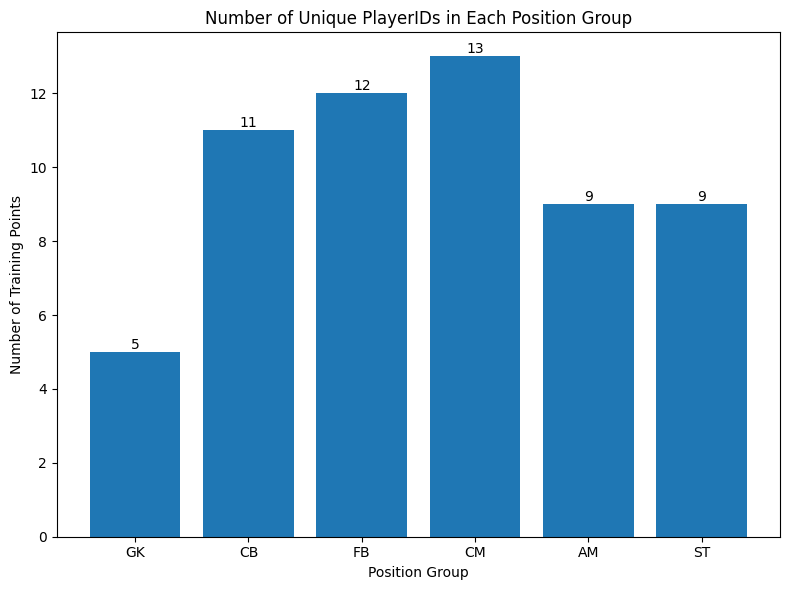

In [ ]:
def plot_unique_player(GK, CB, FB, CM, AM, ST):
    # Count the number of unique player IDs in each dataset
    # Count occurrences of each unique month
    Player_counts_GK = GK['PlayerID'].nunique()
    Player_counts_CB = CB['PlayerID'].nunique()
    Player_counts_FB = FB['PlayerID'].nunique()
    Player_counts_CM = CM['PlayerID'].nunique()
    Player_counts_AM = AM['PlayerID'].nunique()
    Player_counts_ST = ST['PlayerID'].nunique()

    # Plotting
    plt.figure(figsize=(8, 6))

    # Plot bar chart for unique players in each position
    positions = ['GK', 'CB', 'FB', 'CM', 'AM', 'ST']
    player_counts = [Player_counts_GK, Player_counts_CB, Player_counts_FB, Player_counts_CM, Player_counts_AM, Player_counts_ST]
    plt.bar(positions, player_counts)

    # Add labels with values on each bar
    for i, value in enumerate(player_counts):
        plt.text(i, value, str(value), ha='center', va='bottom')

    plt.title('Number of Unique PlayerIDs in Each Position Group')
    plt.xlabel('Position Group')
    plt.ylabel('Number of Training Points')
    plt.tight_layout()
    plt.show()

# Call the function with your datasets
plot_unique_player(GK_gps_grouped, CB_gps_grouped, FB_gps_grouped, CM_gps_grouped, AM_gps_grouped, ST_gps_grouped)

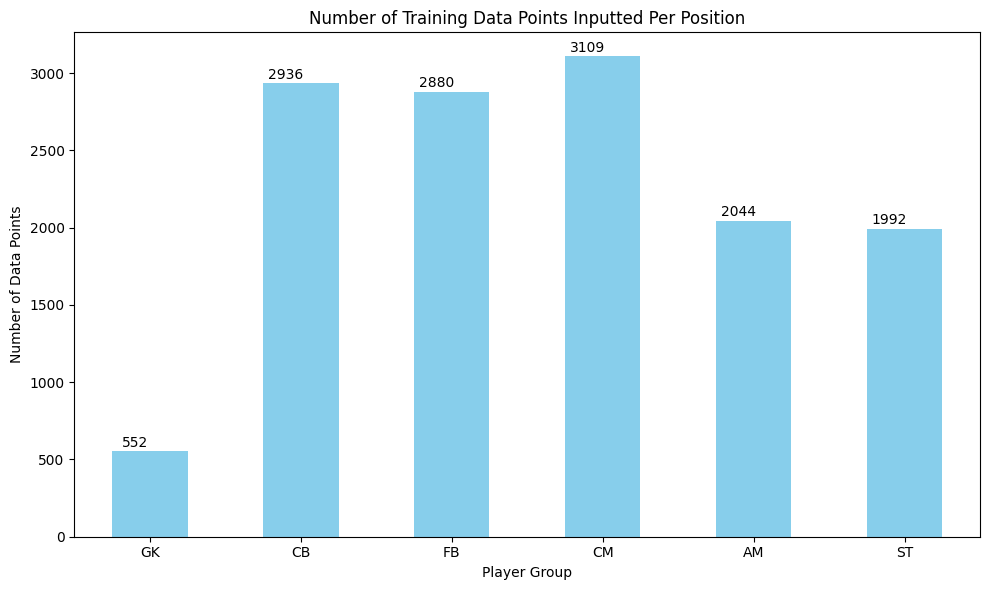

In [ ]:
def plot_data_points(GK, CB, FB, CM, AM, ST):
    # Count the number of data points in each dataset
    Player_counts_GK = GK.shape[0]
    Player_counts_CB = CB.shape[0]
    Player_counts_FB = FB.shape[0]
    Player_counts_CM = CM.shape[0]
    Player_counts_AM = AM.shape[0]
    Player_counts_ST = ST.shape[0]

    # Combine counts into a single Series
    Player_counts = pd.Series({
        'GK': Player_counts_GK,
        'CB': Player_counts_CB,
        'FB': Player_counts_FB,
        'CM': Player_counts_CM,
        'AM': Player_counts_AM,
        'ST': Player_counts_ST
    })

    # Plotting
    plt.figure(figsize=(10, 6))
    bars = Player_counts.plot(kind='bar', color='skyblue')

    # Add labels with values on top of each bar
    for bar in bars.patches:
        plt.text(bar.get_x() + bar.get_width() / 2 - 0.1,
                 bar.get_height() + 10,
                 f'{int(bar.get_height())}',
                 ha='center', va='bottom')

    plt.title('Number of Training Data Points Inputted Per Position')
    plt.xlabel('Player Group')
    plt.ylabel('Number of Data Points')
    plt.xticks(ticks=range(len(Player_counts)), labels=Player_counts.index, rotation=0)
    plt.tight_layout()
    plt.show()

# Call the function with your datasets
plot_data_points(GK_gps_grouped, CB_gps_grouped, FB_gps_grouped, CM_gps_grouped, AM_gps_grouped, ST_gps_grouped)


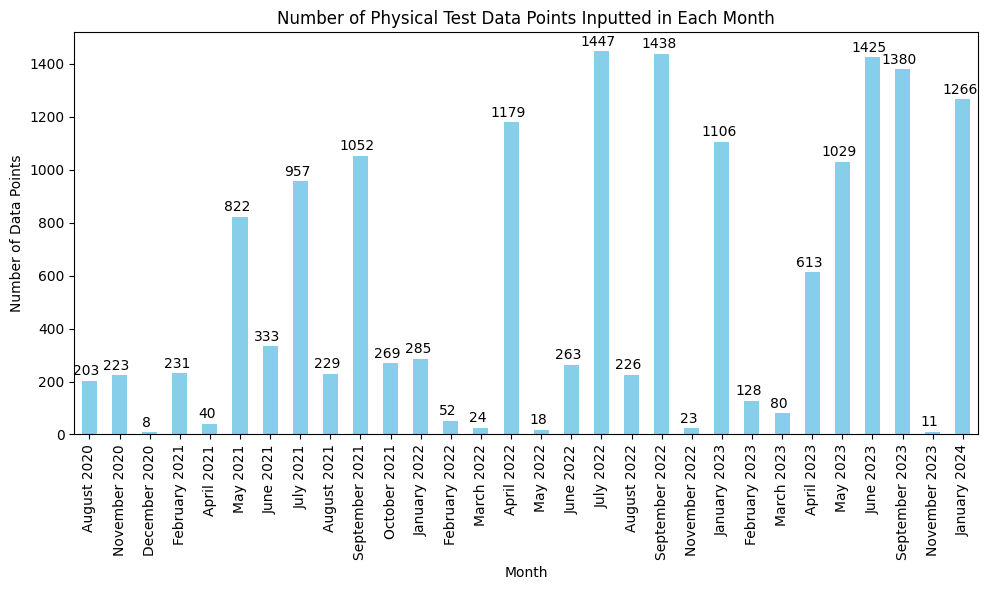

In [ ]:
# Assuming 'Month/Year' is a string column, convert it to datetime
all_phys['Month/Year'] = pd.to_datetime(all_phys['Month/Year'])

# Count occurrences of each unique month and sort them chronologically
month_counts = all_phys['Month/Year'].dt.strftime('%B %Y').value_counts()
month_counts = month_counts.reindex(pd.to_datetime(month_counts.index, format='%B %Y').sort_values().strftime('%B %Y'))

# Plotting
plt.figure(figsize=(10, 6))
bars = month_counts.plot(kind='bar', color='skyblue')

# Add labels with values on top of each bar
for bar in bars.patches:
    plt.text(bar.get_x() + bar.get_width() / 2 - 0.1,
             bar.get_height() + 10,
             f'{int(bar.get_height())}',
             ha='center', va='bottom')

plt.title('Number of Physical Test Data Points Inputted in Each Month')
plt.xlabel('Month')
plt.ylabel('Number of Data Points')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### BiVariate

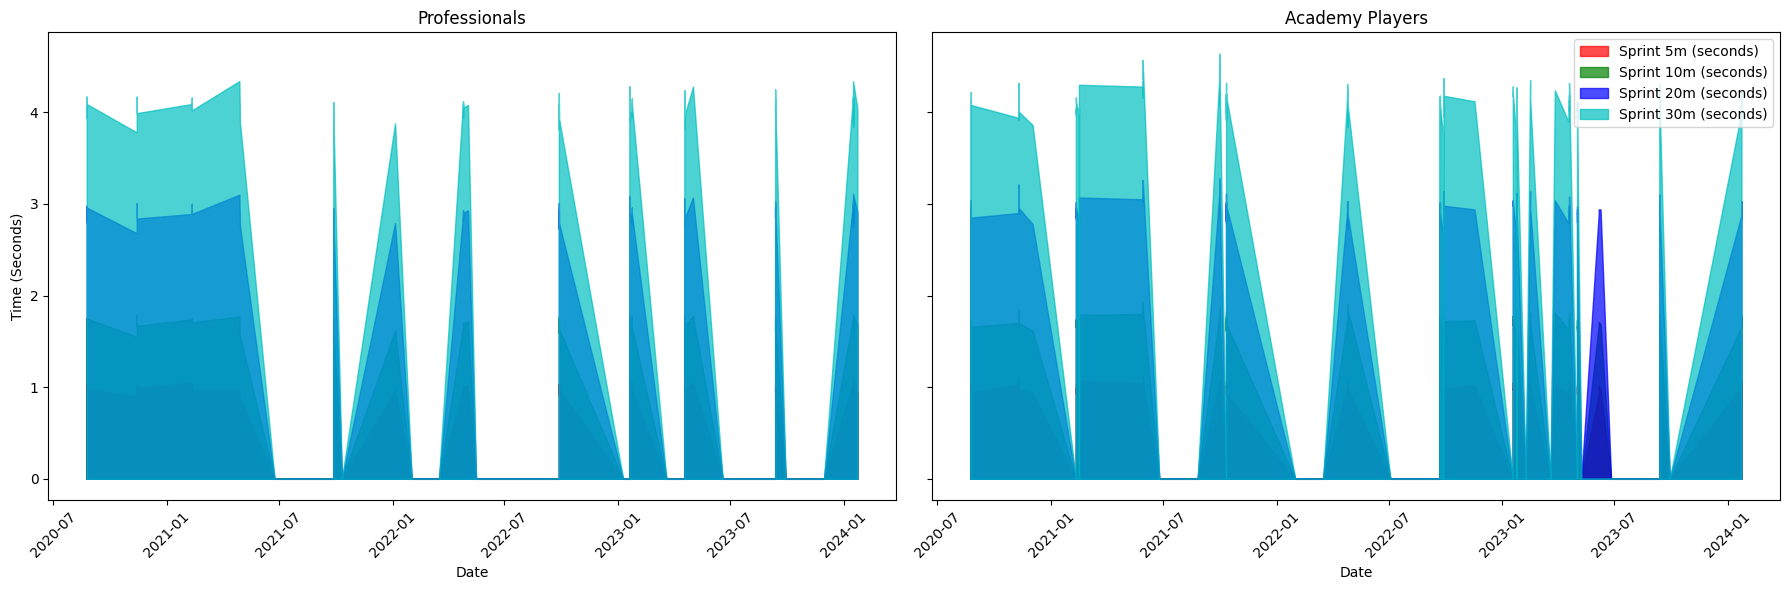

In [ ]:
# Define colors for each metric
colors = ['r', 'g', 'b', 'c']  # red, green, blue, cyan

fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)

# Loop over each sprint distance and plot as area chart
for i, sprint in enumerate(['Sprint 5m (seconds)', 'Sprint 10m (seconds)', 'Sprint 20m (seconds)', 'Sprint 30m (seconds)']):
    # Plot for Professionals
    axes[0].fill_between(pro_saf['Date of measurement'], pro_saf[sprint], label=sprint, alpha=0.7, color=colors[i])
    axes[0].set_title('Professionals')
    axes[0].set_xlabel('Date')
    axes[0].set_ylabel('Time (Seconds)')
    axes[0].tick_params(axis='x', rotation=45)

    # Plot for Academy
    axes[1].fill_between(acad_saf['Date of measurement'], acad_saf[sprint], label=sprint, alpha=0.7, color=colors[i])
    axes[1].set_title('Academy Players')
    axes[1].set_xlabel('Date')
    axes[1].tick_params(axis='x', rotation=45)

# Adjust layout
plt.legend()
plt.tight_layout()
plt.show()

### MultiVariate

In [ ]:
def calculate_saf_stats(data, excluded_columns=['Date of measurement', 'Month/Year']):
    mean_diff = {}
    #sd_diff = {}

    for player_id, player_data in data.items():
        relevant_data = player_data.drop(columns=excluded_columns)
        relevant_data = relevant_data[relevant_data > 0]
        mean_diff[player_id] = relevant_data.mean()
        #sd_diff[player_id] = relevant_data.std()

    #team_data = pd.concat(data.values()).drop(columns=excluded_columns)
    #team_mean_diff = team_data.mean()
    #team_sd_diff = team_data.std()

    return mean_diff #sd_diff, #team_mean_diff, team_sd_diff

# Function to construct the dataframe from the results
def construct_saf_dataframe(mean_diff):  # , sd_diff  #, team_mean_diff, team_sd_diff
    result_df = pd.DataFrame(columns=['Column', 'GK', 'CB', 'FB', 'CM', 'AM', 'ST'])

    for column in mean_diff['GK'].index:  # assuming all players have the same columns
        player_means = [mean_diff[player_id][column] for player_id in mean_diff.keys()]
        #player_sds = [sd_diff[player_id][column] for player_id in sd_diff.keys()]
        #team_mean = team_mean_diff[column]
        #team_sd = team_sd_diff[column]

        result_df.loc[len(result_df)] = [column,
                                         f"{player_means[0]:.2f}",
                                         f"{player_means[1]:.2f}",
                                         f"{player_means[2]:.2f}",
                                         f"{player_means[3]:.2f}",
                                         f"{player_means[4]:.2f}",
                                         f"{player_means[5]:.2f}"]

    return result_df


# Assuming your data is organized in a dictionary where keys are player IDs and values are dataframes
data = {
    'GK': GK_saf_grouped,
    'CB': CB_saf_grouped,
    'FB': FB_saf_grouped,
    'CM': CM_saf_grouped,
    'AM': AM_saf_grouped,
    'ST': ST_saf_grouped,
}

# Call the function to calculate statistics
mean_diff = calculate_saf_stats(data)

# Construct the dataframe from the results
result_df = construct_saf_dataframe(mean_diff)

result_df

,Column,GK,CB,FB,CM,AM,ST
0,PlayerID,92.84,45.65,71.55,42.73,91.52,57.11
1,Sprint 5m (seconds),1.01,1.00,0.96,0.99,0.98,0.98
2,Sprint 10m (seconds),1.73,1.72,1.66,1.73,1.68,1.70
3,Sprint 20m (seconds),2.97,2.95,2.88,2.97,2.89,2.92
4,Sprint 30m (seconds),4.12,4.11,4.02,4.15,4.02,4.08
5,30-15 Fitness Test Score (km/h),20.20,20.82,20.61,20.56,20.99,20.59
6,Agility 505 Right (seconds),2.45,2.43,2.43,2.47,2.40,2.44
7,Agility 505 Left (seconds),2.46,2.44,2.42,2.46,2.43,2.42
8,Agility_Average,2.45,2.44,2.43,2.46,2.41,2.43


In [ ]:
def calculate_rfd_stats(data, excluded_columns=['Date', 'Month/Year']):
    mean_diff = {}
    #sd_diff = {}

    for player_id, player_data in data.items():
        relevant_data = player_data.drop(columns=excluded_columns)
        relevant_data = relevant_data[relevant_data > 0]
        mean_diff[player_id] = relevant_data.mean()
        #sd_diff[player_id] = relevant_data.std()

    #team_data = pd.concat(data.values()).drop(columns=excluded_columns)
    #team_mean_diff = team_data.mean()
    #team_sd_diff = team_data.std()

    return mean_diff #sd_diff, #team_mean_diff, team_sd_diff

# Function to construct the dataframe from the results
def construct_rfd_dataframe(mean_diff):  # , sd_diff  #, team_mean_diff, team_sd_diff
    result_df = pd.DataFrame(columns=['Column', 'GK', 'CB', 'FB', 'CM', 'AM', 'ST'])

    for column in mean_diff['GK'].index:  # assuming all players have the same columns
        player_means = [mean_diff[player_id][column] for player_id in mean_diff.keys()]
        #player_sds = [sd_diff[player_id][column] for player_id in sd_diff.keys()]
        #team_mean = team_mean_diff[column]
        #team_sd = team_sd_diff[column]

        result_df.loc[len(result_df)] = [column,
                                         f"{player_means[0]:.2f}",
                                         f"{player_means[1]:.2f}",
                                         f"{player_means[2]:.2f}",
                                         f"{player_means[3]:.2f}",
                                         f"{player_means[4]:.2f}",
                                         f"{player_means[5]:.2f}"]

    return result_df



# Assuming your data is organized in a dictionary where keys are player IDs and values are dataframes
data = {
    'GK': GK_rfd_grouped,
    'CB': CB_rfd_grouped,
    'FB': FB_rfd_grouped,
    'CM': CM_rfd_grouped,
    'AM': AM_rfd_grouped,
    'ST': ST_rfd_grouped,
}

# Call the function to calculate statistics
mean_diff = calculate_rfd_stats(data)

# Construct the dataframe from the results
result_df = construct_rfd_dataframe(mean_diff)

result_df

,Column,GK,CB,FB,CM,AM,ST
0,PlayerID,85.82,51.45,70.00,40.82,88.40,44.93
1,BW [KG],80.90,80.56,71.58,73.84,69.08,76.77
2,Peak Vertical Force [N],3164.27,2753.95,2634.56,2671.00,2568.53,2975.73
3,Force at 200ms [N],2429.27,2194.82,2009.61,1988.71,1973.93,2209.73
4,RFD - 200ms [N/s],8154.00,6829.32,6358.67,5951.82,6418.00,7068.80
5,Absolute Impulse - 200ms [N s],334.14,295.58,265.43,271.40,273.35,294.62
6,Relative Peak Force,3.99,3.50,3.75,3.69,3.82,3.96
7,Max Peak Vertical Force [N],3671.00,3011.82,2787.50,2888.00,2738.33,3159.33
8,Max Force at 200ms [N],2070.64,1896.73,1717.39,1606.24,1754.33,1778.93
9,Max Relative Peak Force,4.65,3.82,3.97,4.00,4.08,4.18


In [ ]:
def calculate_aerial_stats(data, excluded_columns=['Date', 'Time', 'Month/Year']):
    mean_diff = {}
    #sd_diff = {}

    for player_id, player_data in data.items():
        relevant_data = player_data.drop(columns=excluded_columns)
        relevant_data = relevant_data[relevant_data > 0]
        mean_diff[player_id] = relevant_data.mean()
        #sd_diff[player_id] = relevant_data.std()

    #team_data = pd.concat(data.values()).drop(columns=excluded_columns)
    #team_mean_diff = team_data.mean()
    #team_sd_diff = team_data.std()

    return mean_diff #sd_diff, #team_mean_diff, team_sd_diff

# Function to construct the dataframe from the results
def construct_aerial_dataframe(mean_diff):  # , sd_diff  #, team_mean_diff, team_sd_diff
    result_df = pd.DataFrame(columns=['Column', 'GK', 'CB', 'FB', 'CM', 'AM', 'ST'])

    for column in mean_diff['GK'].index:  # assuming all players have the same columns
        player_means = [mean_diff[player_id][column] for player_id in mean_diff.keys()]
        #player_sds = [sd_diff[player_id][column] for player_id in sd_diff.keys()]
        #team_mean = team_mean_diff[column]
        #team_sd = team_sd_diff[column]

        result_df.loc[len(result_df)] = [column,
                                         f"{player_means[0]:.2f}",
                                         f"{player_means[1]:.2f}",
                                         f"{player_means[2]:.2f}",
                                         f"{player_means[3]:.2f}",
                                         f"{player_means[4]:.2f}",
                                         f"{player_means[5]:.2f}"]

    return result_df




# Assuming your data is organized in a dictionary where keys are player IDs and values are dataframes
data = {
    'GK': GK_aerial_grouped,
    'CB': CB_aerial_grouped,
    'FB': FB_aerial_grouped,
    'CM': CM_aerial_grouped,
    'AM': AM_aerial_grouped,
    'ST': ST_aerial_grouped,
}

# Call the function to calculate statistics
mean_diff = calculate_aerial_stats(data)

# Construct the dataframe from the results
result_df = construct_aerial_dataframe(mean_diff)

result_df

,Column,GK,CB,FB,CM,AM,ST
0,PlayerID,91.73,52.79,78.80,42.09,86.91,52.27
1,BW [KG],79.33,80.57,73.22,70.01,69.62,76.22
2,Jump Height (Imp-Mom) [cm],41.69,38.91,41.35,36.53,38.85,41.07
3,Countermovement Depth [cm],nan,nan,nan,nan,nan,nan
4,Eccentric Duration [ms],477.52,504.58,503.80,523.80,504.90,512.41
5,Eccentric Mean Power / BM [W/kg],8.30,7.77,7.50,7.21,7.57,7.59
6,Concentric Duration [ms],276.00,273.02,269.57,277.67,266.53,265.87
7,Concentric Mean Power / BM [W/kg],32.45,31.37,33.31,30.18,31.62,33.33
8,Eccentric Deceleration RFD [N/s],8774.61,9191.95,8820.33,9677.65,8475.51,10013.04
9,Concentric Peak Force [N],2083.92,2123.84,1956.43,1879.20,1887.35,2137.61


## Statistical Analysis

### Physical Test

In [ ]:
# perform anova
def perform_anova(GK, CB, FB, CM, AM, ST):
    results = []
    for column in GK.columns:
        if column not in ['Date of measurement', 'Month/Year']:
            group1 = GK[column]
            group2 = CB[column]
            group3 = FB[column]
            group4 = CM[column]
            group5 = AM[column]
            group6 = ST[column]

            f_statistic, p_value = f_oneway(group1, group2, group3, group4, group5, group6)

            result = {
                "Variable": column,
                "F-Statistic": round(f_statistic, 4),
                "p-value": round(p_value, 4),
                "Significance": "Significant" if p_value < 0.05 else "Not Significant"
            }
            results.append(result)

    return pd.DataFrame(results)

# Call the function with your datasets
saf_anova_results = perform_anova(GK_saf_grouped, CB_saf_grouped,
                                  FB_saf_grouped, CM_saf_grouped,
                                  AM_saf_grouped, ST_saf_grouped)
saf_anova_results


,Variable,F-Statistic,p-value,Significance
0,PlayerID,32.0439,0.0000,Significant
1,Sprint 5m (seconds),0.6275,0.6789,Not Significant
2,Sprint 10m (seconds),0.5746,0.7195,Not Significant
3,Sprint 20m (seconds),0.6351,0.6731,Not Significant
4,Sprint 30m (seconds),0.6983,0.6249,Not Significant
5,30-15 Fitness Test Score (km/h),4.6701,0.0004,Significant
6,Agility 505 Right (seconds),0.1930,0.9652,Not Significant
7,Agility 505 Left (seconds),0.1943,0.9647,Not Significant
8,Agility_Average,0.1928,0.9653,Not Significant


In [ ]:
# perform anova
def perform_rfd_anova(GK, CB, FB, CM, AM, ST):
    results = []
    for column in GK.columns:
        if column not in ['Date of measurement', 'Month/Year']:
            group1 = GK[column]
            group2 = CB[column]
            group3 = FB[column]
            group4 = CM[column]
            group5 = AM[column]
            group6 = ST[column]

            f_statistic, p_value = f_oneway(group1, group2, group3, group4, group5, group6)

            result = {
                "Variable": column,
                "F-Statistic": round(f_statistic, 4),
                "p-value": round(p_value, 4),
                "Significance": "Significant" if p_value < 0.05 else "Not Significant"
            }
            results.append(result)

    return pd.DataFrame(results)

# Call the function with your datasets
rfd_anova_results = perform_rfd_anova(GK_rfd_grouped, CB_rfd_grouped,
                                      FB_rfd_grouped, CM_rfd_grouped,
                                      AM_rfd_grouped, ST_rfd_grouped)
rfd_anova_results


,Variable,F-Statistic,p-value,Significance
0,PlayerID,4.5390,0.0010,Significant
1,Date,1.0626,0.3863,Not Significant
2,BW [KG],9.0978,0.0000,Significant
3,Peak Vertical Force [N],4.4625,0.0011,Significant
4,Force at 200ms [N],3.7494,0.0039,Significant
5,RFD - 200ms [N/s],2.8826,0.0183,Significant
6,Absolute Impulse - 200ms [N s],4.3565,0.0013,Significant
7,Relative Peak Force,2.1688,0.0643,Not Significant
8,Max Peak Vertical Force [N],10.4771,0.0000,Significant
9,Max Force at 200ms [N],1.9542,0.0929,Not Significant


In [ ]:
# perform anova
def perform_aerial_anova(GK, CB, FB, CM, AM, ST):
    results = []
    for column in GK.columns:
        if column not in ['Date', 'Time', 'Month/Year']:
            group1 = GK[column]
            group2 = CB[column]
            group3 = FB[column]
            group4 = CM[column]
            group5 = AM[column]
            group6 = ST[column]

            f_statistic, p_value = f_oneway(group1, group2, group3, group4, group5, group6)

            result = {
                "Variable": column,
                "F-Statistic": round(f_statistic, 4),
                "p-value": round(p_value, 4),
                "Significance": "Significant" if p_value < 0.05 else "Not Significant"
            }
            results.append(result)

    return pd.DataFrame(results)

# Call the function with your datasets
aerial_anova_results = perform_aerial_anova(GK_aerial_grouped, CB_aerial_grouped,
                                            FB_aerial_grouped, CM_aerial_grouped,
                                            AM_aerial_grouped, ST_aerial_grouped)

aerial_anova_results


,Variable,F-Statistic,p-value,Significance
0,PlayerID,41.2062,0.0000,Significant
1,BW [KG],88.5425,0.0000,Significant
2,Jump Height (Imp-Mom) [cm],30.0819,0.0000,Significant
3,Countermovement Depth [cm],12.1965,0.0000,Significant
4,Eccentric Duration [ms],3.9566,0.0015,Significant
5,Eccentric Mean Power / BM [W/kg],19.4277,0.0000,Significant
6,Concentric Duration [ms],1.6786,0.1373,Not Significant
7,Concentric Mean Power / BM [W/kg],11.4723,0.0000,Significant
8,Eccentric Deceleration RFD [N/s],1.2843,0.2686,Not Significant
9,Concentric Peak Force [N],17.3067,0.0000,Significant


### On-Field Performance

#### General

In [ ]:
model1 = pd.merge(all_phys, all_gps, on='PlayerID', how='inner')

#model1['Month/Year_x'] = model1['Month/Year_x'].dt.to_timestamp()
model1['Month/Year_y'] = model1['Month/Year_y'].dt.to_timestamp()

# Combine the two date columns into a single date column
model1['Date'] = model1['Date_x'].combine_first(model1['Date_y'])
model1['Month/Year'] = model1['Month/Year_x'].combine_first(model1['Month/Year_y'])
model1 = model1.drop(columns=['Date_x', 'Date_y', 'Month/Year_x', 'Month/Year_y'], inplace=False)
# calculate missing data
missing_percentage = (model1.isnull().sum() / len(model1)) * 100
print(missing_percentage)

#remove null values
model1 = model1.dropna()


model1 = model1.rename(columns={"Sprint 5m (seconds)": "Sprint_5m",
                                "Sprint 10m (seconds)": "Sprint_10m",
                                "Sprint 20m (seconds)": "Sprint_20m",
                                "Sprint 30m (seconds)": "Sprint_30m",
                                "30-15 Fitness Test Score (km/h)": "Fitness_score",
                                "Peak Vertical Force [N] ": "Peak_Vertical_Force",
                                "Max Peak Vertical Force [N] ": "Max_Peak_Vertical_Force",
                                "Relative Peak Force": "Relative_Peak_Force",
                                "Jump Height (Imp-Mom) [cm] ": "Jump_Height",
                                "Jump Mean Power/BM [W/kg]" : "Jump_Power",
                                "Meters Per Minute" : "Metres_min",
                                "Meta Energy (Cal/kg)": "Energy_usage",
                                "RHIE Total Bouts": "RHIE_Bouts",
                                "RHIE Bout Recovery - Mean": "RHIE_recovery",
                                "HSR & Sprinting": "HSR_Sprinting",
                                "ACC + DEC/min": "ACC_DEC_min",
                                "Explosive Efforts": "Explosive_Efforts",
                                "Player Load (1D Up)": "Player_Load",
                                "Max Speed (km/h)": "Max_speed" })


# Iterate through the column names and replace spaces with underscores
#for col in model1.columns:
#    model1 = model1.rename(columns={col: col.replace(' ', '_')})

colunss = model1.columns.tolist()
colunss

0
PlayerID                             0.000000
Sprint 5m (seconds)                  0.000000
Sprint 10m (seconds)                 0.000000
Sprint 20m (seconds)                 0.000000
Sprint 30m (seconds)                 0.000000
30-15 Fitness Test Score (km/h)      0.000000
Agility 505 Right (seconds)          0.000000
Agility 505 Left (seconds)           0.000000
Agility_Average                      0.000000
Peak Vertical Force [N]              0.000000
Force at 200ms [N]                   0.000000
RFD - 200ms [N/s]                    0.000000
Absolute Impulse - 200ms [N s]       0.000000
Relative Peak Force                  0.000000
Max Peak Vertical Force [N]          0.000000
Max Force at 200ms [N]               0.000000
Max Relative Peak Force              0.000000
Strength                             0.000000
Time                                 0.000000
Jump Height (Imp-Mom) [cm]           0.000000
Countermovement Depth [cm]           0.000000
Eccentric Duration [ms]         

['PlayerID',
 'Sprint_5m',
 'Sprint_10m',
 'Sprint_20m',
 'Sprint_30m',
 'Fitness_score',
 'Agility 505 Right (seconds)',
 'Agility 505 Left (seconds)',
 'Agility_Average',
 'Peak_Vertical_Force',
 'Force at 200ms [N] ',
 'RFD - 200ms [N/s] ',
 'Absolute Impulse - 200ms [N s] ',
 'Relative_Peak_Force',
 'Max_Peak_Vertical_Force',
 'Max Force at 200ms [N] ',
 'Max Relative Peak Force',
 'Strength',
 'Time',
 'Jump_Height',
 'Countermovement Depth [cm] ',
 'Eccentric Duration [ms] ',
 'Eccentric Mean Power / BM [W/kg] ',
 'Concentric Duration [ms] ',
 'Concentric Mean Power / BM [W/kg]',
 'Eccentric Deceleration RFD [N/s] ',
 'Concentric Peak Force [N] ',
 'Jump Speed [ms]',
 'Jump_Power',
 'BW [KG]',
 'Total Distance',
 'Duration (minutes)',
 'Metres_min',
 'HSR_Sprinting',
 'HSR & Sprinting Per Minute',
 'Sprinting',
 'Sprinting Per Minute',
 'Acceleration B3 Distance (Gen 2)',
 'Max_speed',
 'High Metabolic Power Efforts',
 'Player_Load',
 'Explosive_Efforts',
 'IMA CoD Left High',
 '

In [ ]:
# Assuming 'model1' is your DataFrame
# Convert object-type columns to numeric, except 'Time' column
for column in model1.columns:
    if model1[column].dtype == 'object' and column != 'Time':
        try:
            model1[column] = pd.to_numeric(model1[column])
        except ValueError:
            print(f"Column '{column}' contains non-numeric values and cannot be converted to integer.")

# Display updated DataFrame
model1.head()

,PlayerID,Sprint_5m,Sprint_10m,Sprint_20m,Sprint_30m,Fitness_score,Agility 505 Right (seconds),Agility 505 Left (seconds),Agility_Average,Peak_Vertical_Force,...,RHIE Effort Duration - Mean,RHIE_recovery,Equivalent Distance,HMLD,Energy_usage,EDI,ACC + DEC,ACC_DEC_min,Date,Month/Year
0,25,1.04,1.81,3.09,4.29,0.0,2.58,2.55,2.565,3069.0,...,1.73932,231.12000,5249.83447,168.0,5.18460,1.14765,10.0,0.1,2021-05-29,2021-05-01
1,25,1.04,1.81,3.09,4.29,0.0,2.58,2.55,2.565,3069.0,...,1.58387,225.23529,3087.76367,105.0,3.01965,1.17707,9.0,0.1,2021-05-29,2021-05-01
2,25,1.04,1.81,3.09,4.29,0.0,2.58,2.55,2.565,3069.0,...,1.40667,153.38095,3652.57520,172.0,3.55967,1.18342,17.0,0.2,2021-05-29,2021-05-01
3,25,1.04,1.81,3.09,4.29,0.0,2.58,2.55,2.565,3069.0,...,1.55172,228.05000,4447.85254,131.0,4.30377,1.14859,8.0,0.1,2021-05-29,2021-05-01
4,25,1.04,1.81,3.09,4.29,0.0,2.58,2.55,2.565,3069.0,...,1.96531,102.90323,4369.37793,207.0,4.36908,1.16638,22.0,0.3,2021-05-29,2021-05-01


In [ ]:
def fit_glmm_all(data, output_variables, predictor_variables):
    results = {}  # Dictionary to store results for each output variable

    for output_var in output_variables:
        try:
            # Construct formula dynamically for the current output variable
            formula = f"{output_var} ~ {' + '.join(predictor_variables)} + (1 | PlayerID)"

            # Fit the GLMM for the current output variable
            model = sm.GLM.from_formula(formula, data=data, family=sm.families.Gaussian())
            result = model.fit()

            # Extract summary table
            summary_table = result.summary()
            summary_df = pd.DataFrame(summary_table.tables[1])
            summary_df.columns = summary_df.iloc[0]
            summary_df = summary_df[1:]

            # Store the result DataFrame in the dictionary
            results[output_var] = summary_df
        except Exception as e:
            print(f"Error fitting GLMM for {output_var}: {e}")

    return results

# Example usage:
output_variables = ['Metres_min', 'Sprinting', 'HSR_Sprinting', 'EDI', 'Explosive_Efforts', 'Player_Load', 'Max_speed', 'ACC_DEC_min', 'Energy_usage', 'RHIE_Bouts', 'RHIE_recovery']
predictor_variables = ['Sprint_5m', 'Sprint_10m', 'Agility_Average', 'Sprint_20m', 'Sprint_30m', 'Jump_Power', 'Strength', 'Fitness_score', 'Peak_Vertical_Force', 'Relative_Peak_Force', 'Jump_Height']
# Assuming model1 is your actual dataset containing output and predictor variables
results = fit_glmm_all(model1, output_variables, predictor_variables)

# Access and display each DataFrame separately
for output_var, summary_df in results.items():
    print(f"Summary for {output_var}:")
    display(summary_df)  # Display DataFrame


Summary for Metres_min:


,,coef,std err,z,P>|z|,[0.025,0.975]
1,Intercept,76.8024,0.164,469.129,0.000,76.481,77.123
2,Sprint_5m,-0.1703,0.449,-0.379,0.705,-1.050,0.710
3,Sprint_10m,-0.7337,0.268,-2.737,0.006,-1.259,-0.208
4,Agility_Average,-0.5560,0.015,-38.051,0.000,-0.585,-0.527
5,Sprint_20m,2.3540,0.100,23.656,0.000,2.159,2.549
6,Sprint_30m,-1.2733,0.044,-29.168,0.000,-1.359,-1.188
7,Jump_Power,0.5483,0.005,111.111,0.000,0.539,0.558
8,Strength,0.4926,0.001,352.943,0.000,0.490,0.495
9,Fitness_score,0.0865,0.001,70.740,0.000,0.084,0.089
10,Peak_Vertical_Force,-0.0235,5.92e-05,-397.019,0.000,-0.024,-0.023


Summary for Sprinting:


,,coef,std err,z,P>|z|,[0.025,0.975]
1,Intercept,-30.9838,0.614,-50.443,0.000,-32.188,-29.780
2,Sprint_5m,-40.6096,1.684,-24.108,0.000,-43.911,-37.308
3,Sprint_10m,30.7906,1.006,30.609,0.000,28.819,32.762
4,Agility_Average,-0.3763,0.055,-6.864,0.000,-0.484,-0.269
5,Sprint_20m,-6.6605,0.373,-17.840,0.000,-7.392,-5.929
6,Sprint_30m,0.9424,0.164,5.754,0.000,0.621,1.263
7,Jump_Power,2.0448,0.019,110.451,0.000,2.009,2.081
8,Strength,0.8658,0.005,165.342,0.000,0.856,0.876
9,Fitness_score,0.0450,0.005,9.800,0.000,0.036,0.054
10,Peak_Vertical_Force,-0.0467,0.000,-210.495,0.000,-0.047,-0.046


Summary for HSR_Sprinting:


,,coef,std err,z,P>|z|,[0.025,0.975]
1,Intercept,196.8146,2.309,85.225,0.000,192.288,201.341
2,Sprint_5m,-216.1747,6.333,-34.133,0.000,-228.588,-203.762
3,Sprint_10m,120.9376,3.782,31.977,0.000,113.525,128.350
4,Agility_Average,-2.3869,0.206,-11.581,0.000,-2.791,-1.983
5,Sprint_20m,-2.1915,1.404,-1.561,0.118,-4.943,0.560
6,Sprint_30m,1.6817,0.616,2.731,0.006,0.475,2.889
7,Jump_Power,7.0183,0.070,100.829,0.000,6.882,7.155
8,Strength,4.2258,0.020,214.637,0.000,4.187,4.264
9,Fitness_score,0.5447,0.017,31.568,0.000,0.511,0.578
10,Peak_Vertical_Force,-0.2516,0.001,-301.434,0.000,-0.253,-0.250


Summary for EDI:


,,coef,std err,z,P>|z|,[0.025,0.975]
1,Intercept,1.0913,0.001,1409.126,0.000,1.090,1.093
2,Sprint_5m,-0.0749,0.002,-35.282,0.000,-0.079,-0.071
3,Sprint_10m,0.0449,0.001,35.368,0.000,0.042,0.047
4,Agility_Average,0.0009,6.91e-05,13.400,0.000,0.001,0.001
5,Sprint_20m,-0.0114,0.000,-24.135,0.000,-0.012,-0.010
6,Sprint_30m,0.0066,0.000,32.194,0.000,0.006,0.007
7,Jump_Power,0.0015,2.33e-05,65.611,0.000,0.001,0.002
8,Strength,0.0003,6.6e-06,48.224,0.000,0.000,0.000
9,Fitness_score,-2.043e-05,5.79e-06,-3.531,0.000,-3.18e-05,-9.09e-06
10,Peak_Vertical_Force,-6.201e-06,2.8e-07,-22.150,0.000,-6.75e-06,-5.65e-06


Summary for Explosive_Efforts:


,,coef,std err,z,P>|z|,[0.025,0.975]
1,Intercept,44.3032,0.440,100.789,0.000,43.442,45.165
2,Sprint_5m,-34.3156,1.205,-28.466,0.000,-36.678,-31.953
3,Sprint_10m,8.5975,0.720,11.943,0.000,7.187,10.008
4,Agility_Average,1.4239,0.039,36.297,0.000,1.347,1.501
5,Sprint_20m,5.5052,0.267,20.605,0.000,4.982,6.029
6,Sprint_30m,0.5095,0.117,4.347,0.000,0.280,0.739
7,Jump_Power,-1.4150,0.013,-106.799,0.000,-1.441,-1.389
8,Strength,-0.1978,0.004,-52.794,0.000,-0.205,-0.190
9,Fitness_score,0.0077,0.003,2.342,0.019,0.001,0.014
10,Peak_Vertical_Force,-0.0146,0.000,-92.105,0.000,-0.015,-0.014


Summary for Player_Load:


,,coef,std err,z,P>|z|,[0.025,0.975]
1,Intercept,355.8506,1.351,263.379,0.000,353.202,358.499
2,Sprint_5m,-30.8758,3.705,-8.333,0.000,-38.138,-23.614
3,Sprint_10m,20.5452,2.213,9.285,0.000,16.208,24.882
4,Agility_Average,-0.1111,0.121,-0.922,0.357,-0.347,0.125
5,Sprint_20m,1.1160,0.821,1.359,0.174,-0.494,2.726
6,Sprint_30m,-2.0892,0.360,-5.799,0.000,-2.795,-1.383
7,Jump_Power,0.7440,0.041,18.270,0.000,0.664,0.824
8,Strength,2.0993,0.012,182.255,0.000,2.077,2.122
9,Fitness_score,0.4269,0.010,42.287,0.000,0.407,0.447
10,Peak_Vertical_Force,-0.1814,0.000,-371.421,0.000,-0.182,-0.180


Summary for Max_speed:


,,coef,std err,z,P>|z|,[0.025,0.975]
1,Intercept,21.7297,0.036,602.268,0.000,21.659,21.800
2,Sprint_5m,-1.7118,0.099,-17.300,0.000,-1.906,-1.518
3,Sprint_10m,1.2901,0.059,21.834,0.000,1.174,1.406
4,Agility_Average,-0.0565,0.003,-17.559,0.000,-0.063,-0.050
5,Sprint_20m,-0.0572,0.022,-2.606,0.009,-0.100,-0.014
6,Sprint_30m,-0.1166,0.010,-12.117,0.000,-0.135,-0.098
7,Jump_Power,0.1520,0.001,139.810,0.000,0.150,0.154
8,Strength,0.0886,0.000,288.172,0.000,0.088,0.089
9,Fitness_score,0.0122,0.000,45.420,0.000,0.012,0.013
10,Peak_Vertical_Force,-0.0039,1.3e-05,-296.901,0.000,-0.004,-0.004


Summary for ACC_DEC_min:


,,coef,std err,z,P>|z|,[0.025,0.975]
1,Intercept,0.2293,0.003,88.500,0.000,0.224,0.234
2,Sprint_5m,-0.6026,0.007,-84.815,0.000,-0.617,-0.589
3,Sprint_10m,0.3493,0.004,82.322,0.000,0.341,0.358
4,Agility_Average,0.0014,0.000,6.091,0.000,0.001,0.002
5,Sprint_20m,-0.0408,0.002,-25.921,0.000,-0.044,-0.038
6,Sprint_30m,0.0240,0.001,34.741,0.000,0.023,0.025
7,Jump_Power,0.0168,7.81e-05,215.204,0.000,0.017,0.017
8,Strength,0.0053,2.21e-05,239.865,0.000,0.005,0.005
9,Fitness_score,0.0006,1.94e-05,29.477,0.000,0.001,0.001
10,Peak_Vertical_Force,-0.0003,9.37e-07,-372.774,0.000,-0.000,-0.000


Summary for Energy_usage:


,,coef,std err,z,P>|z|,[0.025,0.975]
1,Intercept,6.1379,0.024,258.826,0.000,6.091,6.184
2,Sprint_5m,-0.0759,0.065,-1.168,0.243,-0.203,0.052
3,Sprint_10m,-0.0493,0.039,-1.269,0.204,-0.125,0.027
4,Agility_Average,-0.0036,0.002,-1.692,0.091,-0.008,0.001
5,Sprint_20m,0.1031,0.014,7.155,0.000,0.075,0.131
6,Sprint_30m,-0.0295,0.006,-4.669,0.000,-0.042,-0.017
7,Jump_Power,0.0069,0.001,9.702,0.000,0.006,0.008
8,Strength,0.0269,0.000,132.876,0.000,0.026,0.027
9,Fitness_score,0.0074,0.000,41.693,0.000,0.007,0.008
10,Peak_Vertical_Force,-0.0021,8.57e-06,-249.551,0.000,-0.002,-0.002


Summary for RHIE_Bouts:


,,coef,std err,z,P>|z|,[0.025,0.975]
1,Intercept,16.1005,0.091,177.035,0.000,15.922,16.279
2,Sprint_5m,2.4437,0.249,9.798,0.000,1.955,2.933
3,Sprint_10m,-0.5039,0.149,-3.383,0.001,-0.796,-0.212
4,Agility_Average,0.0205,0.008,2.530,0.011,0.005,0.036
5,Sprint_20m,-0.3084,0.055,-5.579,0.000,-0.417,-0.200
6,Sprint_30m,-0.1746,0.024,-7.200,0.000,-0.222,-0.127
7,Jump_Power,0.0626,0.003,22.823,0.000,0.057,0.068
8,Strength,0.0234,0.001,30.150,0.000,0.022,0.025
9,Fitness_score,0.0098,0.001,14.425,0.000,0.008,0.011
10,Peak_Vertical_Force,-0.0027,3.29e-05,-82.898,0.000,-0.003,-0.003


Summary for RHIE_recovery:


,,coef,std err,z,P>|z|,[0.025,0.975]
1,Intercept,140.4629,1.409,99.656,0.000,137.700,143.225
2,Sprint_5m,-12.8148,3.865,-3.315,0.001,-20.391,-5.239
3,Sprint_10m,4.3289,2.308,1.875,0.061,-0.195,8.853
4,Agility_Average,1.5083,0.126,11.991,0.000,1.262,1.755
5,Sprint_20m,0.3895,0.857,0.455,0.649,-1.290,2.069
6,Sprint_30m,1.2779,0.376,3.400,0.001,0.541,2.015
7,Jump_Power,-3.3827,0.042,-79.626,0.000,-3.466,-3.299
8,Strength,-1.5151,0.012,-126.089,0.000,-1.539,-1.492
9,Fitness_score,-0.2298,0.011,-21.823,0.000,-0.250,-0.209
10,Peak_Vertical_Force,0.0410,0.001,80.389,0.000,0.040,0.042


#### Professionals

In [ ]:
pro_model1 = pd.merge(pro_all_phys, pro_all_gps, on='PlayerID', how='inner')

#model1['Month/Year_x'] = model1['Month/Year_x'].dt.to_timestamp()
pro_model1['Month/Year_y'] = pro_model1['Month/Year_y'].dt.to_timestamp()

# Combine the two date columns into a single date column
pro_model1['Date'] = pro_model1['Date_x'].combine_first(pro_model1['Date_y'])
pro_model1['Month/Year'] = pro_model1['Month/Year_x'].combine_first(pro_model1['Month/Year_y'])
pro_model1 = pro_model1.drop(columns=['Date_x', 'Date_y', 'Month/Year_x', 'Month/Year_y'], inplace=False)
# calculate missing data
missing_percentage = (pro_model1.isnull().sum() / len(pro_model1)) * 100
print(missing_percentage)

#remove null values
pro_model1 = pro_model1.dropna()


pro_model1 = pro_model1.rename(columns={"Sprint 5m (seconds)": "Sprint_5m",
                                "Sprint 10m (seconds)": "Sprint_10m",
                                "Sprint 20m (seconds)": "Sprint_20m",
                                "Sprint 30m (seconds)": "Sprint_30m",
                                "30-15 Fitness Test Score (km/h)": "Fitness_score",
                                "Peak Vertical Force [N] ": "Peak_Vertical_Force",
                                "Max Peak Vertical Force [N] ": "Max_Peak_Vertical_Force",
                                "Relative Peak Force": "Relative_Peak_Force",
                                "Jump Height (Imp-Mom) [cm] ": "Jump_Height",
                                "Jump Mean Power/BM [W/kg]" : "Jump_Power",
                                "Meters Per Minute" : "Metres_min",
                                "Meta Energy (Cal/kg)": "Energy_usage",
                                "RHIE Total Bouts": "RHIE_Bouts",
                                "RHIE Bout Recovery - Mean": "RHIE_recovery",
                                "HSR & Sprinting": "HSR_Sprinting",
                                "ACC + DEC/min": "ACC_DEC_min",
                                "Explosive Efforts": "Explosive_Efforts",
                                "Player Load (1D Up)": "Player_Load",
                                "Max Speed (km/h)": "Max_speed" })


# Iterate through the column names and replace spaces with underscores
#for col in model1.columns:
#    model1 = model1.rename(columns={col: col.replace(' ', '_')})

colunss = pro_model1.columns.tolist()
colunss

0
PlayerID                             0.000000
Sprint 5m (seconds)                  0.000000
Sprint 10m (seconds)                 0.000000
Sprint 20m (seconds)                 0.000000
Sprint 30m (seconds)                 0.000000
30-15 Fitness Test Score (km/h)      0.000000
Agility 505 Right (seconds)          0.000000
Agility 505 Left (seconds)           0.000000
Agility_Average                      0.000000
Peak Vertical Force [N]              5.981703
Force at 200ms [N]                   5.981703
RFD - 200ms [N/s]                    5.981703
Absolute Impulse - 200ms [N s]       5.981703
Relative Peak Force                  5.981703
Max Peak Vertical Force [N]          5.981703
Max Force at 200ms [N]               5.981703
Max Relative Peak Force              5.981703
Strength                             5.981703
Time                                 0.005046
Jump Height (Imp-Mom) [cm]           0.005046
Countermovement Depth [cm]           0.005046
Eccentric Duration [ms]         

['PlayerID',
 'Sprint_5m',
 'Sprint_10m',
 'Sprint_20m',
 'Sprint_30m',
 'Fitness_score',
 'Agility 505 Right (seconds)',
 'Agility 505 Left (seconds)',
 'Agility_Average',
 'Peak_Vertical_Force',
 'Force at 200ms [N] ',
 'RFD - 200ms [N/s] ',
 'Absolute Impulse - 200ms [N s] ',
 'Relative_Peak_Force',
 'Max_Peak_Vertical_Force',
 'Max Force at 200ms [N] ',
 'Max Relative Peak Force',
 'Strength',
 'Time',
 'Jump_Height',
 'Countermovement Depth [cm] ',
 'Eccentric Duration [ms] ',
 'Eccentric Mean Power / BM [W/kg] ',
 'Concentric Duration [ms] ',
 'Concentric Mean Power / BM [W/kg]',
 'Eccentric Deceleration RFD [N/s] ',
 'Concentric Peak Force [N] ',
 'Jump Speed [ms]',
 'Jump_Power',
 'BW [KG]',
 'Total Distance',
 'Duration (minutes)',
 'Metres_min',
 'HSR_Sprinting',
 'HSR & Sprinting Per Minute',
 'Sprinting',
 'Sprinting Per Minute',
 'Acceleration B3 Distance (Gen 2)',
 'Max_speed',
 'High Metabolic Power Efforts',
 'Player_Load',
 'Explosive_Efforts',
 'IMA CoD Left High',
 '

In [ ]:
# Assuming 'model1' is your DataFrame
# Convert object-type columns to numeric, except 'Time' column
for column in pro_model1.columns:
    if pro_model1[column].dtype == 'object' and column != 'Time':
        try:
            pro_model1[column] = pd.to_numeric(pro_model1[column])
        except ValueError:
            print(f"Column '{column}' contains non-numeric values and cannot be converted to integer.")

# Display updated DataFrame
pro_model1.head()

Column 'Month/Year' contains non-numeric values and cannot be converted to integer.


,PlayerID,Sprint_5m,Sprint_10m,Sprint_20m,Sprint_30m,Fitness_score,Agility 505 Right (seconds),Agility 505 Left (seconds),Agility_Average,Peak_Vertical_Force,...,RHIE Effort Duration - Mean,RHIE_recovery,Equivalent Distance,HMLD,Energy_usage,EDI,ACC + DEC,ACC_DEC_min,Date,Month/Year
5,59,0.0,0.0,0.0,0.0,18.0,0.0,0.0,0.0,2646.0,...,2.12,233.04,6214.94,166.0,6.31,1.09,9.0,0.1,2022-06-20,2022-06
6,59,0.0,0.0,0.0,0.0,18.0,0.0,0.0,0.0,2646.0,...,1.46,373.00,2526.56,51.0,2.49,1.10,3.0,0.0,2022-06-20,2022-06
7,59,0.0,0.0,0.0,0.0,18.0,0.0,0.0,0.0,2646.0,...,1.07,206.20,3181.90,111.0,3.15,1.15,3.0,0.0,2022-06-20,2022-06
8,59,0.0,0.0,0.0,0.0,18.0,0.0,0.0,0.0,2646.0,...,0.93,313.22,2176.18,37.0,2.15,1.10,2.0,0.0,2022-06-20,2022-06
9,59,0.0,0.0,0.0,0.0,18.0,0.0,0.0,0.0,2646.0,...,1.60,193.67,4623.24,163.0,4.56,1.14,27.0,0.3,2022-06-20,2022-06


In [ ]:
# Example usage:
output_variables = ['Metres_min', 'Sprinting', 'HSR_Sprinting', 'EDI', 'Explosive_Efforts', 'Player_Load', 'Max_speed', 'ACC_DEC_min', 'Energy_usage', 'RHIE_Bouts', 'RHIE_recovery']
predictor_variables = ['Sprint_5m', 'Sprint_10m', 'Agility_Average', 'Sprint_20m', 'Sprint_30m', 'Jump_Power', 'Strength', 'Fitness_score', 'Peak_Vertical_Force', 'Relative_Peak_Force', 'Jump_Height']
# Assuming model1 is your actual dataset containing output and predictor variables
pro_results = fit_glmm_all(pro_model1, output_variables, predictor_variables)

# Access and display each DataFrame separately
for output_var, summary_df in pro_results.items():
    print(f"Summary for {output_var}:")
    display(summary_df)  # Display DataFrame

Summary for Metres_min:


,,coef,std err,z,P>|z|,[0.025,0.975]
1,Intercept,66.1693,0.452,146.532,0.000,65.284,67.054
2,Sprint_5m,-40.2422,1.402,-28.705,0.000,-42.990,-37.495
3,Sprint_10m,-1.7866,0.485,-3.688,0.000,-2.736,-0.837
4,Agility_Average,0.7820,0.047,16.764,0.000,0.691,0.873
5,Sprint_20m,0.8076,1.719,0.470,0.639,-2.562,4.177
6,Sprint_30m,9.2375,1.217,7.591,0.000,6.853,11.623
7,Jump_Power,0.3543,0.014,24.631,0.000,0.326,0.382
8,Strength,0.0700,0.003,22.307,0.000,0.064,0.076
9,Fitness_score,0.1297,0.003,39.401,0.000,0.123,0.136
10,Peak_Vertical_Force,-0.0131,0.000,-77.166,0.000,-0.013,-0.013


Summary for Sprinting:


,,coef,std err,z,P>|z|,[0.025,0.975]
1,Intercept,-28.4593,1.911,-14.895,0.000,-32.204,-24.714
2,Sprint_5m,-2.5584,5.932,-0.431,0.666,-14.184,9.068
3,Sprint_10m,9.6412,2.050,4.703,0.000,5.623,13.659
4,Agility_Average,1.8117,0.197,9.179,0.000,1.425,2.199
5,Sprint_20m,-2.2985,7.274,-0.316,0.752,-16.555,11.958
6,Sprint_30m,-3.2717,5.149,-0.635,0.525,-13.363,6.820
7,Jump_Power,0.1511,0.061,2.483,0.013,0.032,0.270
8,Strength,0.1660,0.013,12.494,0.000,0.140,0.192
9,Fitness_score,0.1366,0.014,9.809,0.000,0.109,0.164
10,Peak_Vertical_Force,-0.0349,0.001,-48.613,0.000,-0.036,-0.033


Summary for HSR_Sprinting:


,,coef,std err,z,P>|z|,[0.025,0.975]
1,Intercept,100.3142,6.782,14.792,0.000,87.022,113.606
2,Sprint_5m,-228.7435,21.054,-10.865,0.000,-270.009,-187.478
3,Sprint_10m,8.1088,7.276,1.114,0.265,-6.153,22.370
4,Agility_Average,6.3374,0.701,9.046,0.000,4.964,7.711
5,Sprint_20m,55.2994,25.818,2.142,0.032,4.698,105.901
6,Sprint_30m,6.3566,18.275,0.348,0.728,-29.462,42.175
7,Jump_Power,2.0645,0.216,9.558,0.000,1.641,2.488
8,Strength,0.9015,0.047,19.119,0.000,0.809,0.994
9,Fitness_score,0.9715,0.049,19.653,0.000,0.875,1.068
10,Peak_Vertical_Force,-0.1315,0.003,-51.629,0.000,-0.137,-0.127


Summary for EDI:


,,coef,std err,z,P>|z|,[0.025,0.975]
1,Intercept,1.1367,0.001,880.337,0.000,1.134,1.139
2,Sprint_5m,-0.0226,0.004,-5.648,0.000,-0.030,-0.015
3,Sprint_10m,0.0002,0.001,0.146,0.884,-0.003,0.003
4,Agility_Average,0.0015,0.000,10.949,0.000,0.001,0.002
5,Sprint_20m,0.0187,0.005,3.800,0.000,0.009,0.028
6,Sprint_30m,-0.0088,0.003,-2.522,0.012,-0.016,-0.002
7,Jump_Power,-0.0009,4.11e-05,-21.456,0.000,-0.001,-0.001
8,Strength,-5.643e-05,8.98e-06,-6.285,0.000,-7.4e-05,-3.88e-05
9,Fitness_score,0.0001,9.41e-06,12.131,0.000,9.57e-05,0.000
10,Peak_Vertical_Force,-2.282e-05,4.85e-07,-47.048,0.000,-2.38e-05,-2.19e-05


Summary for Explosive_Efforts:


,,coef,std err,z,P>|z|,[0.025,0.975]
1,Intercept,12.8595,0.333,38.632,0.000,12.207,13.512
2,Sprint_5m,38.0192,1.033,36.790,0.000,35.994,40.045
3,Sprint_10m,-3.8320,0.357,-10.730,0.000,-4.532,-3.132
4,Agility_Average,-0.4268,0.034,-12.410,0.000,-0.494,-0.359
5,Sprint_20m,25.2858,1.267,19.954,0.000,22.802,27.770
6,Sprint_30m,-25.1407,0.897,-28.028,0.000,-26.899,-23.383
7,Jump_Power,-0.7071,0.011,-66.698,0.000,-0.728,-0.686
8,Strength,-0.2381,0.002,-102.878,0.000,-0.243,-0.234
9,Fitness_score,-0.0109,0.002,-4.489,0.000,-0.016,-0.006
10,Peak_Vertical_Force,0.0030,0.000,24.163,0.000,0.003,0.003


Summary for Player_Load:


,,coef,std err,z,P>|z|,[0.025,0.975]
1,Intercept,268.0517,3.648,73.485,0.000,260.902,275.201
2,Sprint_5m,14.9521,11.324,1.320,0.187,-7.243,37.148
3,Sprint_10m,-32.2042,3.914,-8.228,0.000,-39.875,-24.533
4,Agility_Average,4.9935,0.377,13.251,0.000,4.255,5.732
5,Sprint_20m,1.3196,13.887,0.095,0.924,-25.898,28.537
6,Sprint_30m,5.2122,9.830,0.530,0.596,-14.053,24.478
7,Jump_Power,1.6541,0.116,14.237,0.000,1.426,1.882
8,Strength,-0.0672,0.025,-2.650,0.008,-0.117,-0.017
9,Fitness_score,0.4109,0.027,15.453,0.000,0.359,0.463
10,Peak_Vertical_Force,-0.0971,0.001,-70.868,0.000,-0.100,-0.094


Summary for Max_speed:


,,coef,std err,z,P>|z|,[0.025,0.975]
1,Intercept,20.7130,0.094,220.165,0.000,20.529,20.897
2,Sprint_5m,-2.4246,0.292,-8.301,0.000,-2.997,-1.852
3,Sprint_10m,0.5022,0.101,4.975,0.000,0.304,0.700
4,Agility_Average,0.2038,0.010,20.971,0.000,0.185,0.223
5,Sprint_20m,-0.3692,0.358,-1.031,0.303,-1.071,0.333
6,Sprint_30m,0.4511,0.254,1.779,0.075,-0.046,0.948
7,Jump_Power,0.0228,0.003,7.611,0.000,0.017,0.029
8,Strength,0.0148,0.001,22.556,0.000,0.013,0.016
9,Fitness_score,0.0187,0.001,27.309,0.000,0.017,0.020
10,Peak_Vertical_Force,-0.0027,3.53e-05,-76.058,0.000,-0.003,-0.003


Summary for ACC_DEC_min:


,,coef,std err,z,P>|z|,[0.025,0.975]
1,Intercept,0.2208,0.010,22.338,0.000,0.201,0.240
2,Sprint_5m,-0.7882,0.031,-25.685,0.000,-0.848,-0.728
3,Sprint_10m,0.0218,0.011,2.059,0.039,0.001,0.043
4,Agility_Average,0.0079,0.001,7.698,0.000,0.006,0.010
5,Sprint_20m,0.1550,0.038,4.120,0.000,0.081,0.229
6,Sprint_30m,0.0637,0.027,2.391,0.017,0.011,0.116
7,Jump_Power,0.0012,0.000,3.780,0.000,0.001,0.002
8,Strength,0.0006,6.87e-05,9.182,0.000,0.000,0.001
9,Fitness_score,0.0013,7.2e-05,18.605,0.000,0.001,0.001
10,Peak_Vertical_Force,-0.0003,3.71e-06,-69.115,0.000,-0.000,-0.000


Summary for Energy_usage:


,,coef,std err,z,P>|z|,[0.025,0.975]
1,Intercept,4.6323,0.065,70.770,0.000,4.504,4.761
2,Sprint_5m,-2.2584,0.203,-11.114,0.000,-2.657,-1.860
3,Sprint_10m,-0.5501,0.070,-7.832,0.000,-0.688,-0.412
4,Agility_Average,0.0773,0.007,11.425,0.000,0.064,0.091
5,Sprint_20m,0.5562,0.249,2.232,0.026,0.068,1.045
6,Sprint_30m,0.3163,0.176,1.793,0.073,-0.029,0.662
7,Jump_Power,0.0197,0.002,9.449,0.000,0.016,0.024
8,Strength,0.0035,0.000,7.744,0.000,0.003,0.004
9,Fitness_score,0.0086,0.000,17.963,0.000,0.008,0.010
10,Peak_Vertical_Force,-0.0010,2.46e-05,-39.802,0.000,-0.001,-0.001


Summary for RHIE_Bouts:


,,coef,std err,z,P>|z|,[0.025,0.975]
1,Intercept,16.2354,0.265,61.159,0.000,15.715,16.756
2,Sprint_5m,5.2829,0.824,6.410,0.000,3.668,6.898
3,Sprint_10m,0.1213,0.285,0.426,0.670,-0.437,0.680
4,Agility_Average,0.2847,0.027,10.383,0.000,0.231,0.338
5,Sprint_20m,3.3446,1.011,3.310,0.001,1.364,5.325
6,Sprint_30m,-3.9423,0.715,-5.511,0.000,-5.344,-2.540
7,Jump_Power,0.0207,0.008,2.443,0.015,0.004,0.037
8,Strength,-0.0079,0.002,-4.284,0.000,-0.012,-0.004
9,Fitness_score,0.0126,0.002,6.514,0.000,0.009,0.016
10,Peak_Vertical_Force,-0.0014,9.97e-05,-14.184,0.000,-0.002,-0.001


Summary for RHIE_recovery:


,,coef,std err,z,P>|z|,[0.025,0.975]
1,Intercept,115.2795,2.932,39.317,0.000,109.533,121.026
2,Sprint_5m,113.0605,9.103,12.421,0.000,95.220,130.901
3,Sprint_10m,-4.2573,3.146,-1.353,0.176,-10.423,1.908
4,Agility_Average,-2.9694,0.303,-9.803,0.000,-3.563,-2.376
5,Sprint_20m,10.8198,11.162,0.969,0.332,-11.057,32.697
6,Sprint_30m,-30.5112,7.901,-3.862,0.000,-45.997,-15.025
7,Jump_Power,0.1261,0.093,1.350,0.177,-0.057,0.309
8,Strength,-0.2089,0.020,-10.248,0.000,-0.249,-0.169
9,Fitness_score,-0.4159,0.021,-19.463,0.000,-0.458,-0.374
10,Peak_Vertical_Force,0.0431,0.001,39.088,0.000,0.041,0.045


#### Academy Players

In [ ]:
acad_model1 = pd.merge(acad_all_phys, acad_all_gps, on='PlayerID', how='inner')

#model1['Month/Year_x'] = model1['Month/Year_x'].dt.to_timestamp()
acad_model1['Month/Year_y'] = acad_model1['Month/Year_y'].dt.to_timestamp()

# Combine the two date columns into a single date column
acad_model1['Date'] = acad_model1['Date_x'].combine_first(acad_model1['Date_y'])
acad_model1['Month/Year'] = acad_model1['Month/Year_x'].combine_first(acad_model1['Month/Year_y'])
acad_model1 = acad_model1.drop(columns=['Date_x', 'Date_y', 'Month/Year_x', 'Month/Year_y'], inplace=False)
# calculate missing data
missing_percentage = (acad_model1.isnull().sum() / len(acad_model1)) * 100
print(missing_percentage)

#remove null values
acad_model1 = acad_model1.dropna()


acad_model1 = acad_model1.rename(columns={"Sprint 5m (seconds)": "Sprint_5m",
                                "Sprint 10m (seconds)": "Sprint_10m",
                                "Sprint 20m (seconds)": "Sprint_20m",
                                "Sprint 30m (seconds)": "Sprint_30m",
                                "30-15 Fitness Test Score (km/h)": "Fitness_score",
                                "Peak Vertical Force [N] ": "Peak_Vertical_Force",
                                "Max Peak Vertical Force [N] ": "Max_Peak_Vertical_Force",
                                "Relative Peak Force": "Relative_Peak_Force",
                                "Jump Height (Imp-Mom) [cm] ": "Jump_Height",
                                "Jump Mean Power/BM [W/kg]" : "Jump_Power",
                                "Meters Per Minute" : "Metres_min",
                                "Meta Energy (Cal/kg)": "Energy_usage",
                                "RHIE Total Bouts": "RHIE_Bouts",
                                "RHIE Bout Recovery - Mean": "RHIE_recovery",
                                "HSR & Sprinting": "HSR_Sprinting",
                                "ACC + DEC/min": "ACC_DEC_min",
                                "Explosive Efforts": "Explosive_Efforts",
                                "Player Load (1D Up)": "Player_Load",
                                "Max Speed (km/h)": "Max_speed" })


# Iterate through the column names and replace spaces with underscores
#for col in model1.columns:
#    model1 = model1.rename(columns={col: col.replace(' ', '_')})

colunss = acad_model1.columns.tolist()
colunss

0
PlayerID                             0.000000
Sprint 5m (seconds)                  0.000000
Sprint 10m (seconds)                 0.000000
Sprint 20m (seconds)                 0.000000
Sprint 30m (seconds)                 0.000000
30-15 Fitness Test Score (km/h)      0.000000
Agility 505 Right (seconds)          0.000000
Agility 505 Left (seconds)           0.000000
Agility_Average                      0.000000
Peak Vertical Force [N]              1.166419
Force at 200ms [N]                   1.166419
RFD - 200ms [N/s]                    1.166419
Absolute Impulse - 200ms [N s]       1.166419
Relative Peak Force                  1.166419
Max Peak Vertical Force [N]          1.166419
Max Force at 200ms [N]               1.166419
Max Relative Peak Force              1.166419
Strength                             1.166419
Time                                 0.020226
Jump Height (Imp-Mom) [cm]           0.020226
Countermovement Depth [cm]           0.020226
Eccentric Duration [ms]         

['PlayerID',
 'Sprint_5m',
 'Sprint_10m',
 'Sprint_20m',
 'Sprint_30m',
 'Fitness_score',
 'Agility 505 Right (seconds)',
 'Agility 505 Left (seconds)',
 'Agility_Average',
 'Peak_Vertical_Force',
 'Force at 200ms [N] ',
 'RFD - 200ms [N/s] ',
 'Absolute Impulse - 200ms [N s] ',
 'Relative_Peak_Force',
 'Max_Peak_Vertical_Force',
 'Max Force at 200ms [N] ',
 'Max Relative Peak Force',
 'Strength',
 'Time',
 'Jump_Height',
 'Countermovement Depth [cm] ',
 'Eccentric Duration [ms] ',
 'Eccentric Mean Power / BM [W/kg] ',
 'Concentric Duration [ms] ',
 'Concentric Mean Power / BM [W/kg]',
 'Eccentric Deceleration RFD [N/s] ',
 'Concentric Peak Force [N] ',
 'Jump Speed [ms]',
 'Jump_Power',
 'BW [KG]',
 'Total Distance',
 'Duration (minutes)',
 'Metres_min',
 'HSR_Sprinting',
 'HSR & Sprinting Per Minute',
 'Sprinting',
 'Sprinting Per Minute',
 'Acceleration B3 Distance (Gen 2)',
 'Max_speed',
 'High Metabolic Power Efforts',
 'Player_Load',
 'Explosive_Efforts',
 'IMA CoD Left High',
 '

In [ ]:
# Assuming 'model1' is your DataFrame
# Convert object-type columns to numeric, except 'Time' column
for column in acad_model1.columns:
    if acad_model1[column].dtype == 'object' and column != 'Time':
        try:
            acad_model1[column] = pd.to_numeric(acad_model1[column])
        except ValueError:
            print(f"Column '{column}' contains non-numeric values and cannot be converted to integer.")

# Display updated DataFrame
acad_model1.head()

Column 'Month/Year' contains non-numeric values and cannot be converted to integer.


,PlayerID,Sprint_5m,Sprint_10m,Sprint_20m,Sprint_30m,Fitness_score,Agility 505 Right (seconds),Agility 505 Left (seconds),Agility_Average,Peak_Vertical_Force,...,RHIE Effort Duration - Mean,RHIE_recovery,Equivalent Distance,HMLD,Energy_usage,EDI,ACC + DEC,ACC_DEC_min,Date,Month/Year
0,25,1.04,1.81,3.09,4.29,0.0,2.58,2.55,2.565,3069.0,...,1.73932,231.12000,5249.83447,168.0,5.18460,1.14765,10.0,0.1,2021-05-29,2021-05
1,25,1.04,1.81,3.09,4.29,0.0,2.58,2.55,2.565,3069.0,...,1.58387,225.23529,3087.76367,105.0,3.01965,1.17707,9.0,0.1,2021-05-29,2021-05
2,25,1.04,1.81,3.09,4.29,0.0,2.58,2.55,2.565,3069.0,...,1.40667,153.38095,3652.57520,172.0,3.55967,1.18342,17.0,0.2,2021-05-29,2021-05
3,25,1.04,1.81,3.09,4.29,0.0,2.58,2.55,2.565,3069.0,...,1.55172,228.05000,4447.85254,131.0,4.30377,1.14859,8.0,0.1,2021-05-29,2021-05
4,25,1.04,1.81,3.09,4.29,0.0,2.58,2.55,2.565,3069.0,...,1.96531,102.90323,4369.37793,207.0,4.36908,1.16638,22.0,0.3,2021-05-29,2021-05


In [ ]:
# Example usage:
output_variables = ['Metres_min', 'Sprinting', 'HSR_Sprinting', 'EDI', 'Explosive_Efforts', 'Player_Load', 'Max_speed', 'ACC_DEC_min', 'Energy_usage', 'RHIE_Bouts', 'RHIE_recovery']
predictor_variables = ['Sprint_5m', 'Sprint_10m', 'Agility_Average', 'Sprint_20m', 'Sprint_30m', 'Jump_Power', 'Strength', 'Fitness_score', 'Peak_Vertical_Force', 'Relative_Peak_Force', 'Jump_Height']
# Assuming model1 is your actual dataset containing output and predictor variables
acad_results = fit_glmm_all(acad_model1, output_variables, predictor_variables)

# Access and display each DataFrame separately
for output_var, summary_df in acad_results.items():
    print(f"Summary for {output_var}:")
    display(summary_df)  # Display DataFrame

Summary for Metres_min:


,,coef,std err,z,P>|z|,[0.025,0.975]
1,Intercept,70.9665,0.225,314.995,0.000,70.525,71.408
2,Sprint_5m,5.6372,0.661,8.533,0.000,4.342,6.932
3,Sprint_10m,-3.2880,0.399,-8.239,0.000,-4.070,-2.506
4,Agility_Average,-0.1722,0.024,-7.327,0.000,-0.218,-0.126
5,Sprint_20m,-0.3284,0.145,-2.258,0.024,-0.614,-0.043
6,Sprint_30m,0.3781,0.077,4.933,0.000,0.228,0.528
7,Jump_Power,0.7958,0.006,126.084,0.000,0.783,0.808
8,Strength,0.5555,0.002,265.377,0.000,0.551,0.560
9,Fitness_score,0.0660,0.002,41.298,0.000,0.063,0.069
10,Peak_Vertical_Force,-0.0299,8.7e-05,-343.984,0.000,-0.030,-0.030


Summary for Sprinting:


,,coef,std err,z,P>|z|,[0.025,0.975]
1,Intercept,-38.8255,0.859,-45.185,0.000,-40.510,-37.141
2,Sprint_5m,-73.4093,2.520,-29.135,0.000,-78.348,-68.471
3,Sprint_10m,47.7832,1.522,31.393,0.000,44.800,50.766
4,Agility_Average,0.0384,0.090,0.429,0.668,-0.137,0.214
5,Sprint_20m,-9.4159,0.555,-16.971,0.000,-10.503,-8.328
6,Sprint_30m,3.6698,0.292,12.555,0.000,3.097,4.243
7,Jump_Power,3.2468,0.024,134.878,0.000,3.200,3.294
8,Strength,1.1081,0.008,138.804,0.000,1.092,1.124
9,Fitness_score,0.0011,0.006,0.178,0.859,-0.011,0.013
10,Peak_Vertical_Force,-0.0426,0.000,-128.477,0.000,-0.043,-0.042


Summary for HSR_Sprinting:


,,coef,std err,z,P>|z|,[0.025,0.975]
1,Intercept,212.8969,3.282,64.877,0.000,206.465,219.329
2,Sprint_5m,-315.4898,9.623,-32.787,0.000,-334.350,-296.630
3,Sprint_10m,169.7430,5.813,29.200,0.000,158.350,181.136
4,Agility_Average,0.8993,0.342,2.626,0.009,0.228,1.570
5,Sprint_20m,-23.3536,2.119,-11.022,0.000,-27.507,-19.201
6,Sprint_30m,19.5409,1.116,17.505,0.000,17.353,21.729
7,Jump_Power,11.2300,0.092,122.154,0.000,11.050,11.410
8,Strength,4.9548,0.030,162.519,0.000,4.895,5.015
9,Fitness_score,0.2787,0.023,11.967,0.000,0.233,0.324
10,Peak_Vertical_Force,-0.2789,0.001,-220.017,0.000,-0.281,-0.276


Summary for EDI:


,,coef,std err,z,P>|z|,[0.025,0.975]
1,Intercept,1.0882,0.001,873.537,0.000,1.086,1.091
2,Sprint_5m,-0.1376,0.004,-37.674,0.000,-0.145,-0.130
3,Sprint_10m,0.0787,0.002,35.683,0.000,0.074,0.083
4,Agility_Average,0.0013,0.000,10.225,0.000,0.001,0.002
5,Sprint_20m,-0.0133,0.001,-16.589,0.000,-0.015,-0.012
6,Sprint_30m,0.0088,0.000,20.746,0.000,0.008,0.010
7,Jump_Power,0.0024,3.49e-05,67.789,0.000,0.002,0.002
8,Strength,0.0007,1.16e-05,61.361,0.000,0.001,0.001
9,Fitness_score,4.481e-05,8.84e-06,5.069,0.000,2.75e-05,6.21e-05
10,Peak_Vertical_Force,1.874e-05,4.81e-07,38.945,0.000,1.78e-05,1.97e-05


Summary for Explosive_Efforts:


,,coef,std err,z,P>|z|,[0.025,0.975]
1,Intercept,57.7280,0.780,74.037,0.000,56.200,59.256
2,Sprint_5m,-58.1527,2.286,-25.435,0.000,-62.634,-53.671
3,Sprint_10m,15.5925,1.381,11.289,0.000,12.885,18.300
4,Agility_Average,2.3518,0.081,28.906,0.000,2.192,2.511
5,Sprint_20m,10.8609,0.503,21.572,0.000,9.874,11.848
6,Sprint_30m,-1.2495,0.265,-4.711,0.000,-1.769,-0.730
7,Jump_Power,-1.4185,0.022,-64.938,0.000,-1.461,-1.376
8,Strength,0.0266,0.007,3.674,0.000,0.012,0.041
9,Fitness_score,-0.0013,0.006,-0.226,0.821,-0.012,0.010
10,Peak_Vertical_Force,-0.0183,0.000,-60.850,0.000,-0.019,-0.018


Summary for Player_Load:


,,coef,std err,z,P>|z|,[0.025,0.975]
1,Intercept,362.0191,1.996,181.385,0.000,358.107,365.931
2,Sprint_5m,25.1105,5.852,4.291,0.000,13.640,36.581
3,Sprint_10m,-21.3333,3.536,-6.034,0.000,-28.263,-14.404
4,Agility_Average,-2.2964,0.208,-11.027,0.000,-2.705,-1.888
5,Sprint_20m,0.1352,1.289,0.105,0.916,-2.391,2.661
6,Sprint_30m,4.2979,0.679,6.330,0.000,2.967,5.629
7,Jump_Power,2.0103,0.056,35.954,0.000,1.901,2.120
8,Strength,3.4835,0.019,187.863,0.000,3.447,3.520
9,Fitness_score,0.3973,0.014,28.049,0.000,0.370,0.425
10,Peak_Vertical_Force,-0.1752,0.001,-227.335,0.000,-0.177,-0.174


Summary for Max_speed:


,,coef,std err,z,P>|z|,[0.025,0.975]
1,Intercept,21.1161,0.051,410.828,0.000,21.015,21.217
2,Sprint_5m,-2.0127,0.151,-13.354,0.000,-2.308,-1.717
3,Sprint_10m,1.3676,0.091,15.020,0.000,1.189,1.546
4,Agility_Average,-0.0201,0.005,-3.749,0.000,-0.031,-0.010
5,Sprint_20m,-0.3836,0.033,-11.557,0.000,-0.449,-0.319
6,Sprint_30m,0.1757,0.017,10.048,0.000,0.141,0.210
7,Jump_Power,0.2325,0.001,161.437,0.000,0.230,0.235
8,Strength,0.1076,0.000,225.245,0.000,0.107,0.108
9,Fitness_score,0.0087,0.000,23.862,0.000,0.008,0.009
10,Peak_Vertical_Force,-0.0043,1.99e-05,-215.154,0.000,-0.004,-0.004


Summary for ACC_DEC_min:


,,coef,std err,z,P>|z|,[0.025,0.975]
1,Intercept,0.2596,0.003,93.517,0.000,0.254,0.265
2,Sprint_5m,-0.9020,0.008,-110.830,0.000,-0.918,-0.886
3,Sprint_10m,0.5210,0.005,105.971,0.000,0.511,0.531
4,Agility_Average,0.0033,0.000,11.306,0.000,0.003,0.004
5,Sprint_20m,-0.0773,0.002,-43.118,0.000,-0.081,-0.074
6,Sprint_30m,0.0500,0.001,52.952,0.000,0.048,0.052
7,Jump_Power,0.0253,7.78e-05,324.832,0.000,0.025,0.025
8,Strength,0.0076,2.58e-05,294.082,0.000,0.008,0.008
9,Fitness_score,0.0005,1.97e-05,25.056,0.000,0.000,0.001
10,Peak_Vertical_Force,-0.0003,1.07e-06,-244.063,0.000,-0.000,-0.000


Summary for Energy_usage:


,,coef,std err,z,P>|z|,[0.025,0.975]
1,Intercept,6.4316,0.035,184.517,0.000,6.363,6.500
2,Sprint_5m,1.5278,0.102,14.948,0.000,1.327,1.728
3,Sprint_10m,-0.9863,0.062,-15.973,0.000,-1.107,-0.865
4,Agility_Average,-0.0286,0.004,-7.874,0.000,-0.036,-0.022
5,Sprint_20m,-0.0240,0.023,-1.065,0.287,-0.068,0.020
6,Sprint_30m,0.0931,0.012,7.852,0.000,0.070,0.116
7,Jump_Power,0.0170,0.001,17.362,0.000,0.015,0.019
8,Strength,0.0369,0.000,114.063,0.000,0.036,0.038
9,Fitness_score,0.0073,0.000,29.626,0.000,0.007,0.008
10,Peak_Vertical_Force,-0.0023,1.35e-05,-170.545,0.000,-0.002,-0.002


Summary for RHIE_Bouts:


,,coef,std err,z,P>|z|,[0.025,0.975]
1,Intercept,17.1411,0.129,132.409,0.000,16.887,17.395
2,Sprint_5m,9.3691,0.380,24.681,0.000,8.625,10.113
3,Sprint_10m,-4.4382,0.229,-19.353,0.000,-4.888,-3.989
4,Agility_Average,-0.1262,0.014,-9.343,0.000,-0.153,-0.100
5,Sprint_20m,-0.0839,0.084,-1.004,0.316,-0.248,0.080
6,Sprint_30m,-0.2675,0.044,-6.075,0.000,-0.354,-0.181
7,Jump_Power,0.1228,0.004,33.870,0.000,0.116,0.130
8,Strength,0.0562,0.001,46.730,0.000,0.054,0.059
9,Fitness_score,0.0107,0.001,11.617,0.000,0.009,0.012
10,Peak_Vertical_Force,-0.0028,5e-05,-55.980,0.000,-0.003,-0.003


Summary for RHIE_recovery:


,,coef,std err,z,P>|z|,[0.025,0.975]
1,Intercept,167.0357,1.782,93.750,0.000,163.544,170.528
2,Sprint_5m,-15.9653,5.225,-3.056,0.002,-26.205,-5.725
3,Sprint_10m,7.4759,3.156,2.369,0.018,1.290,13.662
4,Agility_Average,0.9607,0.186,5.168,0.000,0.596,1.325
5,Sprint_20m,5.6310,1.150,4.895,0.000,3.376,7.886
6,Sprint_30m,-3.7994,0.606,-6.269,0.000,-4.987,-2.611
7,Jump_Power,-4.2898,0.050,-85.942,0.000,-4.388,-4.192
8,Strength,-1.6584,0.017,-100.187,0.000,-1.691,-1.626
9,Fitness_score,-0.2151,0.013,-17.013,0.000,-0.240,-0.190
10,Peak_Vertical_Force,0.0350,0.001,50.919,0.000,0.034,0.036


## Performance Analysis

In [ ]:
def calculate_stats(data, excluded_columns=['Date', 'Month/Year']):
    mean_diff = {}
    sd_diff = {}
    f_statistic = {}
    p_value = {}

    # Calculate mean and standard deviation for each player
    for player_id, player_data in data.items():
        relevant_data = player_data.drop(columns=excluded_columns)
        relevant_data = relevant_data[relevant_data > 0]
        mean_diff[player_id] = relevant_data.mean()
        sd_diff[player_id] = relevant_data.std()

    # Calculate team mean and standard deviation (not included in ANOVA)
    team_data = pd.concat(data.values()).drop(columns=excluded_columns)
    team_mean = team_data.mean()
    team_sd = team_data.std()

    # Perform one-way ANOVA for each column
    for column in data['GK'].columns:
        if column not in excluded_columns:
            anova_data = [player_data[column].dropna() for player_data in data.values()]
            f_statistic[column], p_value[column] = f_oneway(*anova_data)

    return mean_diff, sd_diff, team_mean, team_sd, f_statistic, p_value

def construct_dataframe(mean_diff, sd_diff, team_mean, team_sd, f_statistic, p_value):
    result_df = pd.DataFrame(columns=['Column', 'GK', 'CB', 'FB', 'CM', 'AM', 'ST', 'Team Mean ± SD', 'F-Statistic', 'p-value', 'Significance'])

    for column in mean_diff['GK'].index:  # assuming all players have the same columns
        player_means = [mean_diff[player_id][column] for player_id in mean_diff.keys()]
        player_sds = [sd_diff[player_id][column] for player_id in sd_diff.keys()]

        result_df.loc[len(result_df)] = [column,
                                      f"{player_means[0]:.2f} ± {player_sds[0]:.2f}",
                                      f"{player_means[1]:.2f} ± {player_sds[1]:.2f}",
                                      f"{player_means[2]:.2f} ± {player_sds[2]:.2f}",
                                      f"{player_means[3]:.2f} ± {player_sds[3]:.2f}",
                                      f"{player_means[4]:.2f} ± {player_sds[4]:.2f}",
                                      f"{player_means[5]:.2f} ± {player_sds[5]:.2f}",
                                      f"{team_mean[column]:.2f} ± {team_sd[column]:.2f}",
                                      f"{f_statistic[column]:.4f}",
                                      f"{p_value[column]:.4f}",
                                      "Significant" if p_value[column] < 0.05 else "Not Significant"]

    return result_df

# Assuming your data is organized in a dictionary where keys are player IDs and values are dataframes
data = {
    'GK': GK_gps_grouped,
    'CB': CB_gps_grouped,
    'FB': FB_gps_grouped,
    'CM': CM_gps_grouped,
    'AM': AM_gps_grouped,
    'ST': ST_gps_grouped,
}

# Call the function to calculate statistics
mean_diff, sd_diff, team_mean, team_sd, f_statistic, p_value = calculate_stats(data)

# Construct the dataframe from the results
result_df = construct_dataframe(mean_diff, sd_diff, team_mean, team_sd, f_statistic, p_value)

result_df

,Column,GK,CB,FB,CM,AM,ST,Team Mean ± SD,F-Statistic,p-value,Significance
0,PlayerID,88.42 ± 40.31,50.01 ± 36.60,72.30 ± 29.59,54.29 ± 32.43,96.29 ± 36.49,55.58 ± 49.23,65.14 ± 40.18,542.9437,0.0000,Significant
1,Total Distance,3636.68 ± 1405.10,5224.91 ± 2701.80,5108.80 ± 2492.00,5486.20 ± 2867.52,5525.56 ± 2742.83,5118.60 ± 2457.86,5219.78 ± 2658.34,53.1196,0.0000,Significant
2,Duration (minutes),83.85 ± 25.48,68.88 ± 24.31,68.21 ± 24.60,69.16 ± 25.16,68.90 ± 23.38,67.42 ± 23.65,69.20 ± 24.57,43.0752,0.0000,Significant
3,Meters Per Minute,44.16 ± 14.12,74.82 ± 21.97,74.66 ± 20.22,78.36 ± 22.98,79.04 ± 21.49,75.77 ± 21.61,74.85 ± 22.86,245.8644,0.0000,Significant
4,HSR & Sprinting,50.24 ± 114.13,295.13 ± 290.06,333.89 ± 319.22,336.93 ± 325.75,373.24 ± 345.20,354.23 ± 332.41,307.74 ± 321.26,109.6090,0.0000,Significant
5,HSR & Sprinting Per Minute,0.93 ± 4.64,4.44 ± 6.88,5.18 ± 7.30,4.91 ± 6.68,5.07 ± 5.56,5.49 ± 7.59,4.55 ± 6.72,49.3179,0.0000,Significant
6,Sprinting,43.12 ± 56.10,80.78 ± 79.28,96.34 ± 109.19,85.12 ± 83.98,104.95 ± 106.16,102.40 ± 101.59,57.48 ± 88.30,73.5865,0.0000,Significant
7,Sprinting Per Minute,0.01 ± 0.01,0.02 ± 0.03,0.03 ± 0.03,0.02 ± 0.02,0.03 ± 0.03,0.03 ± 0.03,0.01 ± 0.02,41.1000,0.0000,Significant
8,Acceleration B3 Distance (Gen 2),2.57 ± 3.23,6.32 ± 7.90,8.58 ± 9.12,5.73 ± 6.29,8.42 ± 8.86,8.30 ± 9.29,5.22 ± 7.75,90.1088,0.0000,Significant
9,Max Speed (km/h),20.18 ± 3.46,25.86 ± 4.11,26.71 ± 4.31,26.09 ± 3.96,26.99 ± 4.31,26.47 ± 4.40,26.02 ± 4.65,219.0718,0.0000,Significant


## Injury Risk Prediction

### Data Preprocessing

In [ ]:
# injury data
injury_df = pd.read_excel('/content/drive/MyDrive/Ddrive/Injury Data/Injury Data Set Single Anon.xlsx')
new_header = injury_df.iloc[0]
injury_df = injury_df[1:]
injury_df.columns = new_header

injury_df['Injured'] = 1
injury_df['Date'] = pd.to_datetime(injury_df['InjuryDate'])
injury_df['PlayerID'] = injury_df['PlayerId']

le = LabelEncoder()


# outline the player IDs that are common in both dataframes
common_player_ids2 = set(gps['PlayerID']).intersection(injury_df['PlayerID'])

# create data frame that has only the data for these player ids
new_gps = gps[gps['PlayerID'].isin(common_player_ids2)]
new_injury = injury_df[injury_df['PlayerID'].isin(common_player_ids2)]

print('unique player IDS:', common_player_ids2)
total_unique_players2 = len(common_player_ids2)
print('Total number of unique player IDs:', total_unique_players2)

print('injured:', injury_df['Injured'].value_counts())

unique player IDS: {128, 129, 2, 3, 4, 5, 134, 7, 6, 9, 11, 140, 13, 142, 139, 144, 17, 146, 147, 21, 22, 23, 151, 150, 25, 27, 28, 30, 35, 36, 38, 42, 44, 46, 47, 48, 50, 51, 52, 53, 54, 57, 58, 59, 61, 62, 63, 65, 66, 68, 72, 75, 76, 77, 81, 83, 88, 90, 91, 93, 95, 96, 100, 102, 104, 107, 108, 110, 111, 114, 115, 119, 121, 122, 123, 125}
Total number of unique player IDs: 76
injured: Injured
1    289
Name: count, dtype: int64


In [ ]:
# Filter only the total session
def filter_data_for_period(df, period_number):
    # Filter the dataframe for period number 0
    period_0_data = df[df['Period Number'] == period_number]
    return period_0_data

# Example usage:
# Assuming gps_common_df is your dataframe containing player data
new_gps = filter_data_for_period(new_gps, 0)
print('Unique ni of player:', len(new_gps['PlayerID'].unique()))


# outline only injuries that occur in training
selected_columns = ['SquadSession', 'DaysMissedLimited', 'PreviousInjuryReturnDate', 'Notes', 'InjuryClassfication', 'AvailableDate', 'Estimated Return Date']

# Creating a new DataFrame with selected columns
grouped_injury_df = new_injury.drop(columns=selected_columns)

#Drop null values
#grouped_injury_df = grouped_injury_df.dropna()
'''
# outline for only training injury
def filter_data_for_injury(df, injury_location):
    # Filter the dataframe for period number 0
    period_0_data = df[df['WhereDidTheInjuryOccur'] == injury_location]
    return period_0_data

# Example usage:
# Assuming gps_common_df is your dataframe containing player data
grouped_injury_df = filter_data_for_injury(grouped_injury_df, injury_location='Training')
'''
print('injured:', grouped_injury_df['Injured'].value_counts())

Unique ni of player: 76
injured: Injured
1    285
Name: count, dtype: int64


In [ ]:
# Convert 'InjuryDate' column to datetime format
grouped_injury_df['Date'] = pd.to_datetime(grouped_injury_df['InjuryDate'])

# Now you can use the .dt accessor to extract the date component
#grouped_injury_df['Date'] = grouped_injury_df['InjuryDate']
# Display the resulting DataFrame
grouped_injury_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 285 entries, 1 to 289
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   InjuryId                    285 non-null    object        
 1   PlayerId                    285 non-null    object        
 2   GroupId                     281 non-null    object        
 3   GroupName                   282 non-null    object        
 4   InjuryStatus                285 non-null    object        
 5   InjuryDate                  285 non-null    object        
 6   DaysMissedInjured           279 non-null    object        
 7   InjuryType                  285 non-null    object        
 8   InjuryCode                  285 non-null    object        
 9   InjuryName                  285 non-null    object        
 10  Season                      285 non-null    object        
 11  BodyArea                    285 non-null    object        
 12 

In [ ]:
# Select and encode labels
selected_columns = ['PlayerID', 'Date', 'InjuryType' , 'RecurrenceOfPreviousInjury', 'BodyArea', 'Injured']

# Creating a new DataFrame with selected columns
grouped_injury_df = grouped_injury_df[selected_columns].copy()

# Using .fit_transform function to fit label encoder and return encoded label
grouped_injury_df["RecurrenceOfPreviousInjury"] = le.fit_transform(grouped_injury_df["RecurrenceOfPreviousInjury"])
grouped_injury_df["InjuryType"] = le.fit_transform(grouped_injury_df["InjuryType"])
grouped_injury_df["BodyArea"] = le.fit_transform(grouped_injury_df["BodyArea"])


# Assuming you've already encoded the "BodyArea" column
# Get the unique encoded values and their original labels
body_area_encoded = grouped_injury_df["BodyArea"].unique()
body_area_labels = le.inverse_transform(body_area_encoded)

# Create a dictionary to map encoded values to original labels
body_area_mapping = dict(zip(body_area_encoded, body_area_labels))

# Display the mapping
print("Encoded value  : Original label")
for encoded_value, label in body_area_mapping.items():
    print(f"{encoded_value} : {label}")

# Assuming you've already encoded the "RecurrenceOfPreviousInjury" and "InjuryType" columns
# Get the unique encoded values and their original labels for RecurrenceOfPreviousInjury
recurrence_encoded = grouped_injury_df["RecurrenceOfPreviousInjury"].unique()
recurrence_labels = le.inverse_transform(recurrence_encoded)

# Create a dictionary to map encoded values to original labels for RecurrenceOfPreviousInjury
recurrence_mapping = dict(zip(recurrence_encoded, recurrence_labels))

# Display the mapping for RecurrenceOfPreviousInjury
print("Encoded value  : Original label (RecurrenceOfPreviousInjury)")
for encoded_value, label in recurrence_mapping.items():
    print(f"{encoded_value} : {label}")

# Get the unique encoded values and their original labels for InjuryType
injury_type_encoded = grouped_injury_df["InjuryType"].unique()
injury_type_labels = le.inverse_transform(injury_type_encoded)

# Create a dictionary to map encoded values to original labels for InjuryType
injury_type_mapping = dict(zip(injury_type_encoded, injury_type_labels))

# Display the mapping for InjuryType
print("\nEncoded value  : Original label (InjuryType)")
for encoded_value, label in injury_type_mapping.items():
    print(f"{encoded_value} : {label}")



Encoded value  : Original label
1 : Ankle
7 : Knee
15 : Thigh
2 : Foot / Toe
16 : Wrist
9 : Lower Leg /Achilles Tendon
10 : Lumbar Spine
5 : Hip / Groin
3 : Forearm
12 : Paediatric
8 : Lower Back / Sacrum / Pelvis
4 : Head / Face
14 : Shoulder / Clavicula
0 : Abdomen
11 : Neck / Cervical Spine
13 : Pelvis/Buttock Injuries ( excl Groin )
6 : Injury Location Unspecified
Encoded value  : Original label (RecurrenceOfPreviousInjury)
0 : Abdomen
1 : Ankle

Encoded value  : Original label (InjuryType)
9 : Lower Leg /Achilles Tendon
6 : Injury Location Unspecified
5 : Hip / Groin
3 : Forearm
8 : Lower Back / Sacrum / Pelvis
2 : Foot / Toe
11 : Neck / Cervical Spine
12 : Paediatric
0 : Abdomen
4 : Head / Face
7 : Knee
10 : Lumbar Spine
1 : Ankle


In [ ]:
'''
def filter_data_for_period(df, period_number):
    # Filter the dataframe for period number 0
    period_0_data = df[df['Period Number'] == period_number]
    return period_0_data

# Example usage:
# Assuming gps_common_df is your dataframe containing player data
new_gps = filter_data_for_period(new_gps, 0)
'''
new_gps['Distance/minute'] = new_gps['Total Distance'] / new_gps['Duration (minutes)']
new_gps['HSR/minute'] = new_gps['HSR & Sprinting'] / new_gps['Duration (minutes)']
new_gps['Sprinting/minute'] = new_gps['Sprinting'] / new_gps['Duration (minutes)']
new_gps['Total Player Load/minute'] = new_gps['Total Player Load'] / new_gps['Duration (minutes)']
new_gps['ACC + DEC/minute'] = new_gps['ACC + DEC'] / new_gps['Duration (minutes)']

Selected_columns = ['Date', 'PlayerID', 'Period Number', 'Position Name', 'Total Distance','Duration (minutes)', 'Distance/minute', 'HSR & Sprinting',
                    'HSR/minute', 'Sprinting', 'Sprinting/minute', 'Total Player Load',
                    'Total Player Load/minute', 'ACC + DEC', 'ACC + DEC/minute', 'Accelerations',
                    'Acceleration B3 Efforts (Gen 2)', 'Deceleerations', 'Deceleration B3 Efforts (Gen 2)',
                    'Profile Max Velocity', 'Explosive Efforts', 'Meta Energy (Cal/kg)', 'EDI']

new_gps = new_gps[Selected_columns].copy()

# Convert object-type columns containing numeric data to numeric type
#numeric_columns = new_gps.select_dtypes(include=['object']).columns
#new_gps[numeric_columns] = new_gps[numeric_columns].apply(pd.to_numeric, errors='coerce')

#print(new_gps.isnull().sum())
new_gps.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15949 entries, 2 to 81829
Data columns (total 23 columns):
 #   Column                           Non-Null Count  Dtype 
---  ------                           --------------  ----- 
 0   Date                             15949 non-null  object
 1   PlayerID                         15949 non-null  object
 2   Period Number                    15949 non-null  object
 3   Position Name                    15938 non-null  object
 4   Total Distance                   15932 non-null  object
 5   Duration (minutes)               15931 non-null  object
 6   Distance/minute                  15931 non-null  object
 7   HSR & Sprinting                  15930 non-null  object
 8   HSR/minute                       15929 non-null  object
 9   Sprinting                        15922 non-null  object
 10  Sprinting/minute                 15921 non-null  object
 11  Total Player Load                15899 non-null  object
 12  Total Player Load/minute         1589

In [ ]:
# Calculate the total number of rows
total_rows = new_gps.shape[0]

# Calculate the percentage of missing values in each column
percentage_missing = (new_gps.isnull().sum() / total_rows) * 100

# Display the percentage of missing values
print(percentage_missing)

# drop missing values
new_gps = new_gps.dropna()

0
Date                               0.000000
PlayerID                           0.000000
Period Number                      0.000000
Position Name                      0.068970
Total Distance                     0.106590
Duration (minutes)                 0.112860
Distance/minute                    0.112860
HSR & Sprinting                    0.119130
HSR/minute                         0.125400
Sprinting                          0.169290
Sprinting/minute                   0.175560
Total Player Load                  0.313499
Total Player Load/minute           0.313499
ACC + DEC                          0.156750
ACC + DEC/minute                   0.163020
Accelerations                      0.965578
Acceleration B3 Efforts (Gen 2)    1.103517
Deceleerations                     0.965578
Deceleration B3 Efforts (Gen 2)    1.103517
Profile Max Velocity               1.097247
Explosive Efforts                  1.097247
Meta Energy (Cal/kg)               1.097247
EDI                           

In [ ]:
new_gps["Position Name"] = le.fit_transform(new_gps["Position Name"])

# Assuming you've already encoded the "BodyArea" column
# Get the unique encoded values and their original labels
position_encoded = new_gps["Position Name"].unique()
position_labels = le.inverse_transform(position_encoded)

# Create a dictionary to map encoded values to original labels
position_mapping = dict(zip(position_encoded, position_labels))

# Display the mapping
print("Encoded value  : Original label")
for encoded_value, label in position_mapping.items():
    print(f"{encoded_value} : {label}")



Encoded value  : Original label
4 : Centre Back
13 : Striker
1 : Attacking Midfielder
8 : GK
6 : Full Back
14 : Wing
15 : Wing Back
0 : Attacker
3 : Central Midfielder
5 : Forward
11 : Left Back
10 : Goalkeeper
9 : Goal Keeper
12 : Srtiker
2 : Central Defender
7 : Fullback


In [ ]:
new_gps['Date'] = pd.to_datetime(new_gps['Date'])
new_gps.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15764 entries, 2 to 81829
Data columns (total 23 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   Date                             15764 non-null  datetime64[ns]
 1   PlayerID                         15764 non-null  object        
 2   Period Number                    15764 non-null  object        
 3   Position Name                    15764 non-null  int64         
 4   Total Distance                   15764 non-null  object        
 5   Duration (minutes)               15764 non-null  object        
 6   Distance/minute                  15764 non-null  object        
 7   HSR & Sprinting                  15764 non-null  object        
 8   HSR/minute                       15764 non-null  object        
 9   Sprinting                        15764 non-null  object        
 10  Sprinting/minute                 15764 non-null  object        

In [ ]:
ml_df = pd.merge(grouped_injury_df, new_gps, on=['Date', 'PlayerID'], how='outer')

# Combine the two date columns into a single date column
#ml_df['Date'] = ml_df['Date_x'].combine_first(ml_df['Date_y'])
# Fill missing values in 'BodyArea' and 'Injured' columns with 0
ml_df['BodyArea'].fillna(0, inplace=True)
ml_df['Injured'].fillna(0, inplace=True)
ml_df['RecurrenceOfPreviousInjury'].fillna(0, inplace=True)
ml_df['InjuryType'].fillna(0, inplace=True)

ml_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15888 entries, 0 to 15887
Data columns (total 27 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   PlayerID                         15888 non-null  object        
 1   Date                             15888 non-null  datetime64[ns]
 2   InjuryType                       15888 non-null  float64       
 3   RecurrenceOfPreviousInjury       15888 non-null  float64       
 4   BodyArea                         15888 non-null  float64       
 5   Injured                          15888 non-null  float64       
 6   Period Number                    15768 non-null  object        
 7   Position Name                    15768 non-null  float64       
 8   Total Distance                   15768 non-null  object        
 9   Duration (minutes)               15768 non-null  object        
 10  Distance/minute                  15768 non-null  object   

In [ ]:
# Combine the two date columns into a single date column
#ml_df['Date'] = ml_df['Date_x'].combine_first(ml_df['Date_y'])
# Calculate the total number of rows
total_rows = ml_df.shape[0]


# Calculate the percentage of missing values in each column
percentage_missing = (ml_df.isnull().sum() / total_rows) * 100

# Display the percentage of missing values
print(percentage_missing)

print(ml_df['Injured'].unique())
#print('value count', ml_df)

0
PlayerID                           0.000000
Date                               0.000000
InjuryType                         0.000000
RecurrenceOfPreviousInjury         0.000000
BodyArea                           0.000000
Injured                            0.000000
Period Number                      0.755287
Position Name                      0.755287
Total Distance                     0.755287
Duration (minutes)                 0.755287
Distance/minute                    0.755287
HSR & Sprinting                    0.755287
HSR/minute                         0.755287
Sprinting                          0.755287
Sprinting/minute                   0.755287
Total Player Load                  0.755287
Total Player Load/minute           0.755287
ACC + DEC                          0.755287
ACC + DEC/minute                   0.755287
Accelerations                      0.755287
Acceleration B3 Efforts (Gen 2)    0.755287
Deceleerations                     0.755287
Deceleration B3 Efforts (Gen 2

In [ ]:
ml_df = ml_df.dropna()

# Calculate the total number of rows
total_rows = ml_df.shape[0]

# Calculate the percentage of missing values in each column
percentage_missing = (ml_df.isnull().sum() / total_rows) * 100

# Display the percentage of missing values
print(percentage_missing)

print(ml_df['Injured'].unique())
ml_df.info()

0
PlayerID                           0.0
Date                               0.0
InjuryType                         0.0
RecurrenceOfPreviousInjury         0.0
BodyArea                           0.0
Injured                            0.0
Period Number                      0.0
Position Name                      0.0
Total Distance                     0.0
Duration (minutes)                 0.0
Distance/minute                    0.0
HSR & Sprinting                    0.0
HSR/minute                         0.0
Sprinting                          0.0
Sprinting/minute                   0.0
Total Player Load                  0.0
Total Player Load/minute           0.0
ACC + DEC                          0.0
ACC + DEC/minute                   0.0
Accelerations                      0.0
Acceleration B3 Efforts (Gen 2)    0.0
Deceleerations                     0.0
Deceleration B3 Efforts (Gen 2)    0.0
Profile Max Velocity               0.0
Explosive Efforts                  0.0
Meta Energy (Cal/kg)   

In [ ]:
# Convert object-type columns containing numeric data to numeric type
numeric_columns = ml_df.select_dtypes(include=['object']).columns
ml_df[numeric_columns] = ml_df[numeric_columns].apply(pd.to_numeric, errors='coerce')

ml_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15768 entries, 0 to 15887
Data columns (total 27 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   PlayerID                         15768 non-null  int64         
 1   Date                             15768 non-null  datetime64[ns]
 2   InjuryType                       15768 non-null  float64       
 3   RecurrenceOfPreviousInjury       15768 non-null  float64       
 4   BodyArea                         15768 non-null  float64       
 5   Injured                          15768 non-null  float64       
 6   Period Number                    15768 non-null  int64         
 7   Position Name                    15768 non-null  float64       
 8   Total Distance                   15768 non-null  int64         
 9   Duration (minutes)               15768 non-null  float64       
 10  Distance/minute                  15768 non-null  float64       

In [ ]:
ml_df
# Separate features and target variable
X = ml_df.drop(columns=['Injured'])
y = ml_df['Injured']

# Split the dataset into training and validation sets
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.1, random_state=104)


print("Shape of x_train :", X_train.shape)
print("Shape of y_train :", y_train.shape)
print("Shape of x_test :", X_valid.shape)
print("Shape of y_test :", y_valid.shape)

# Check the distribution of the target class in each dataset
train_class_distribution = y_train.value_counts()
valid_class_distribution = y_valid.value_counts()

print("Distribution of the target class in training set:")
print(train_class_distribution)

print("\nDistribution of the target class in testing set:")
print(valid_class_distribution)

# Assuming train_X and train_y are numpy arrays
train_df_X = pd.DataFrame(X_train, columns=X.columns)
train_df_y = pd.DataFrame(y_train, columns=['Injured'])
train_df = pd.concat([train_df_X, train_df_y], axis=1)

# Do same for valid
valid_df_X = pd.DataFrame(X_valid, columns=X.columns)
valid_df_y = pd.DataFrame(y_valid, columns=['Injured'])
valid_df = pd.concat([valid_df_X, valid_df_y], axis=1)

# Now train_df contains both features and target variable
print("Shape of training DataFrame:", train_df.shape)
print("Shape of training DataFrame:", valid_df.shape)

ml_df = train_df.copy()
ml_df.info()

Shape of x_train : (14191, 26)
Shape of y_train : (14191,)
Shape of x_test : (1577, 26)
Shape of y_test : (1577,)
Distribution of the target class in training set:
Injured
0.0    14035
1.0      156
Name: count, dtype: int64

Distribution of the target class in testing set:
Injured
0.0    1565
1.0      12
Name: count, dtype: int64
Shape of training DataFrame: (14191, 27)
Shape of training DataFrame: (1577, 27)
<class 'pandas.core.frame.DataFrame'>
Index: 14191 entries, 6993 to 8381
Data columns (total 27 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   PlayerID                         14191 non-null  int64         
 1   Date                             14191 non-null  datetime64[ns]
 2   InjuryType                       14191 non-null  float64       
 3   RecurrenceOfPreviousInjury       14191 non-null  float64       
 4   BodyArea                         14191 non-null  float64      

In [ ]:
# save data
valid_df.to_excel('/content/drive/MyDrive/Ddrive/validation_data_beta.xlsx', index=False)
#ml_df.to_csv('/content/drive/MyDrive/Ddrive/ml_data_beta.csv', index=False)

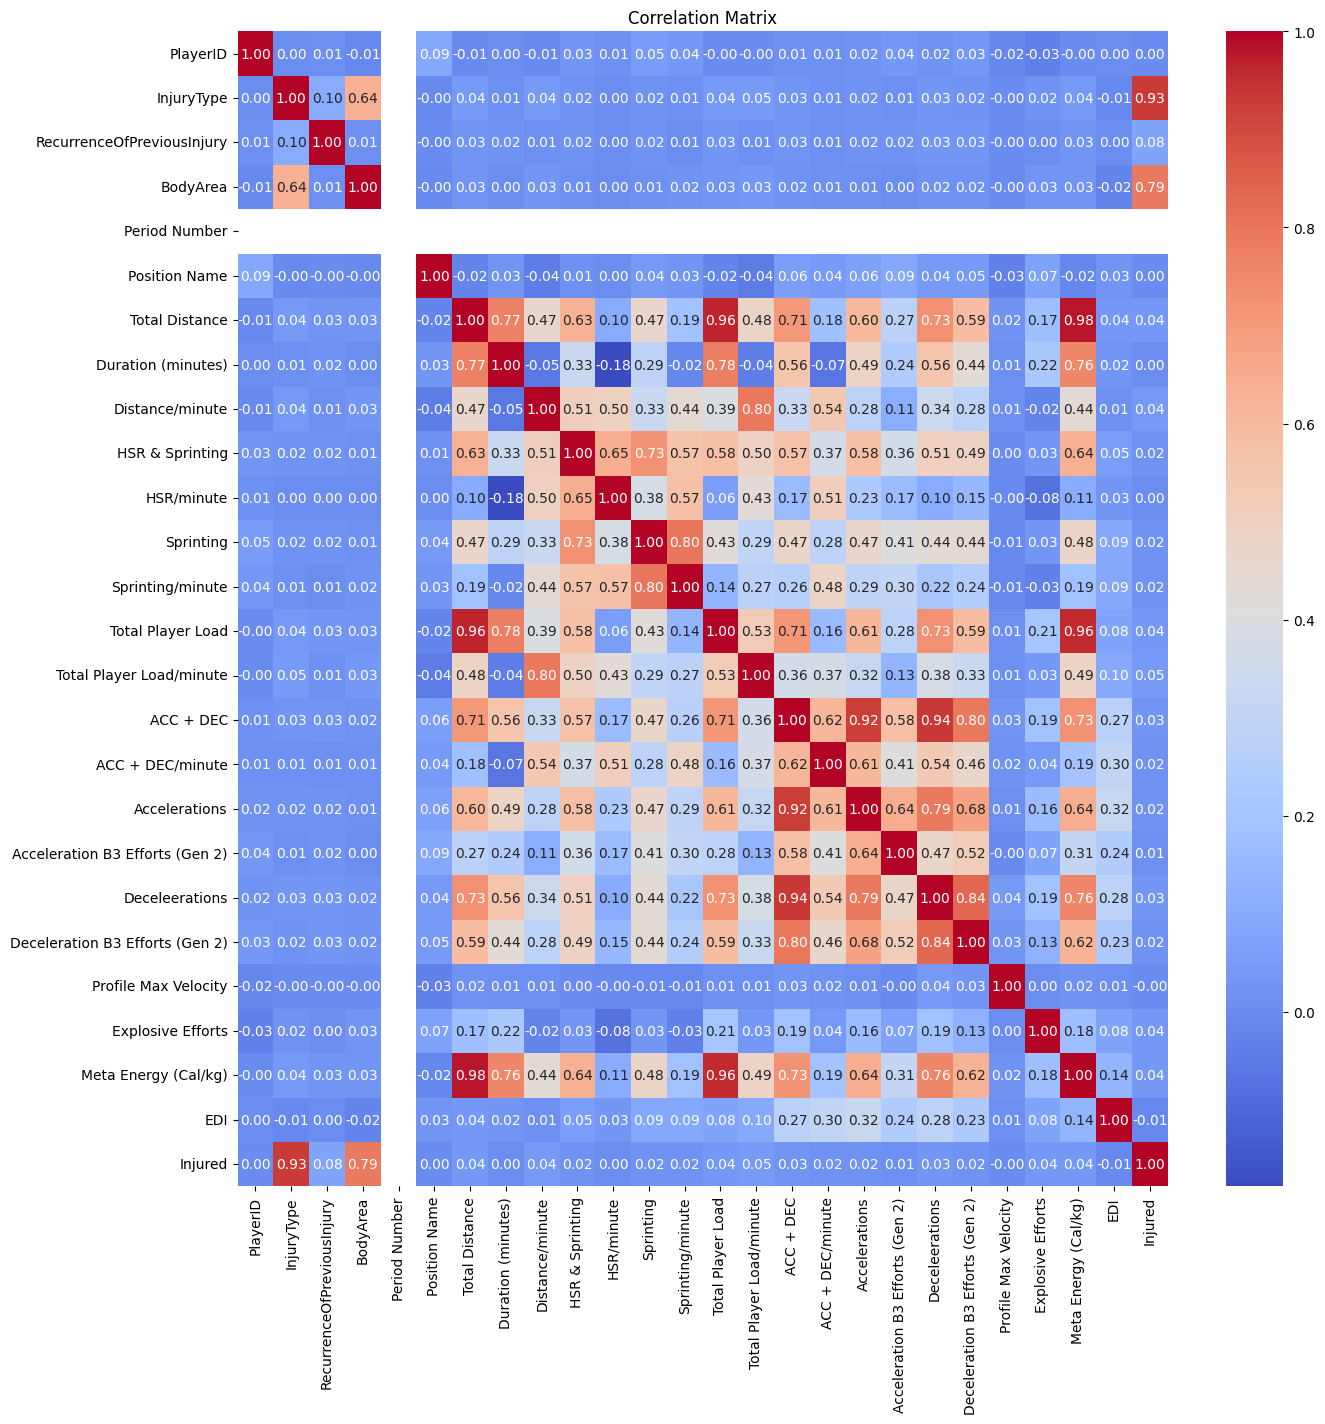

In [ ]:
# Assuming 'target_column_name' is the name of your target variable column
target_column_name = 'Injured'

# Move the target variable to the last column
ml_df = pd.concat([ml_df.drop(columns=[target_column_name]), ml_df[target_column_name]], axis=1)
ml_df = ml_df.fillna(0, inplace=False)
ml_df['InjuryType'] = ml_df['InjuryType'].astype(int)
ml_df['RecurrenceOfPreviousInjury'] = ml_df['RecurrenceOfPreviousInjury'].astype(int)
ml_df['BodyArea'] = ml_df['BodyArea'].astype(int)
ml_df['Injured'] = ml_df['Injured'].astype(int)

# drop date column
ml_df = ml_df.drop(columns=['Date'])

# Calculate the correlation matrix
correlation_matrix = ml_df.corr()
# Plot the heatmap
plt.figure(figsize=(15, 15))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

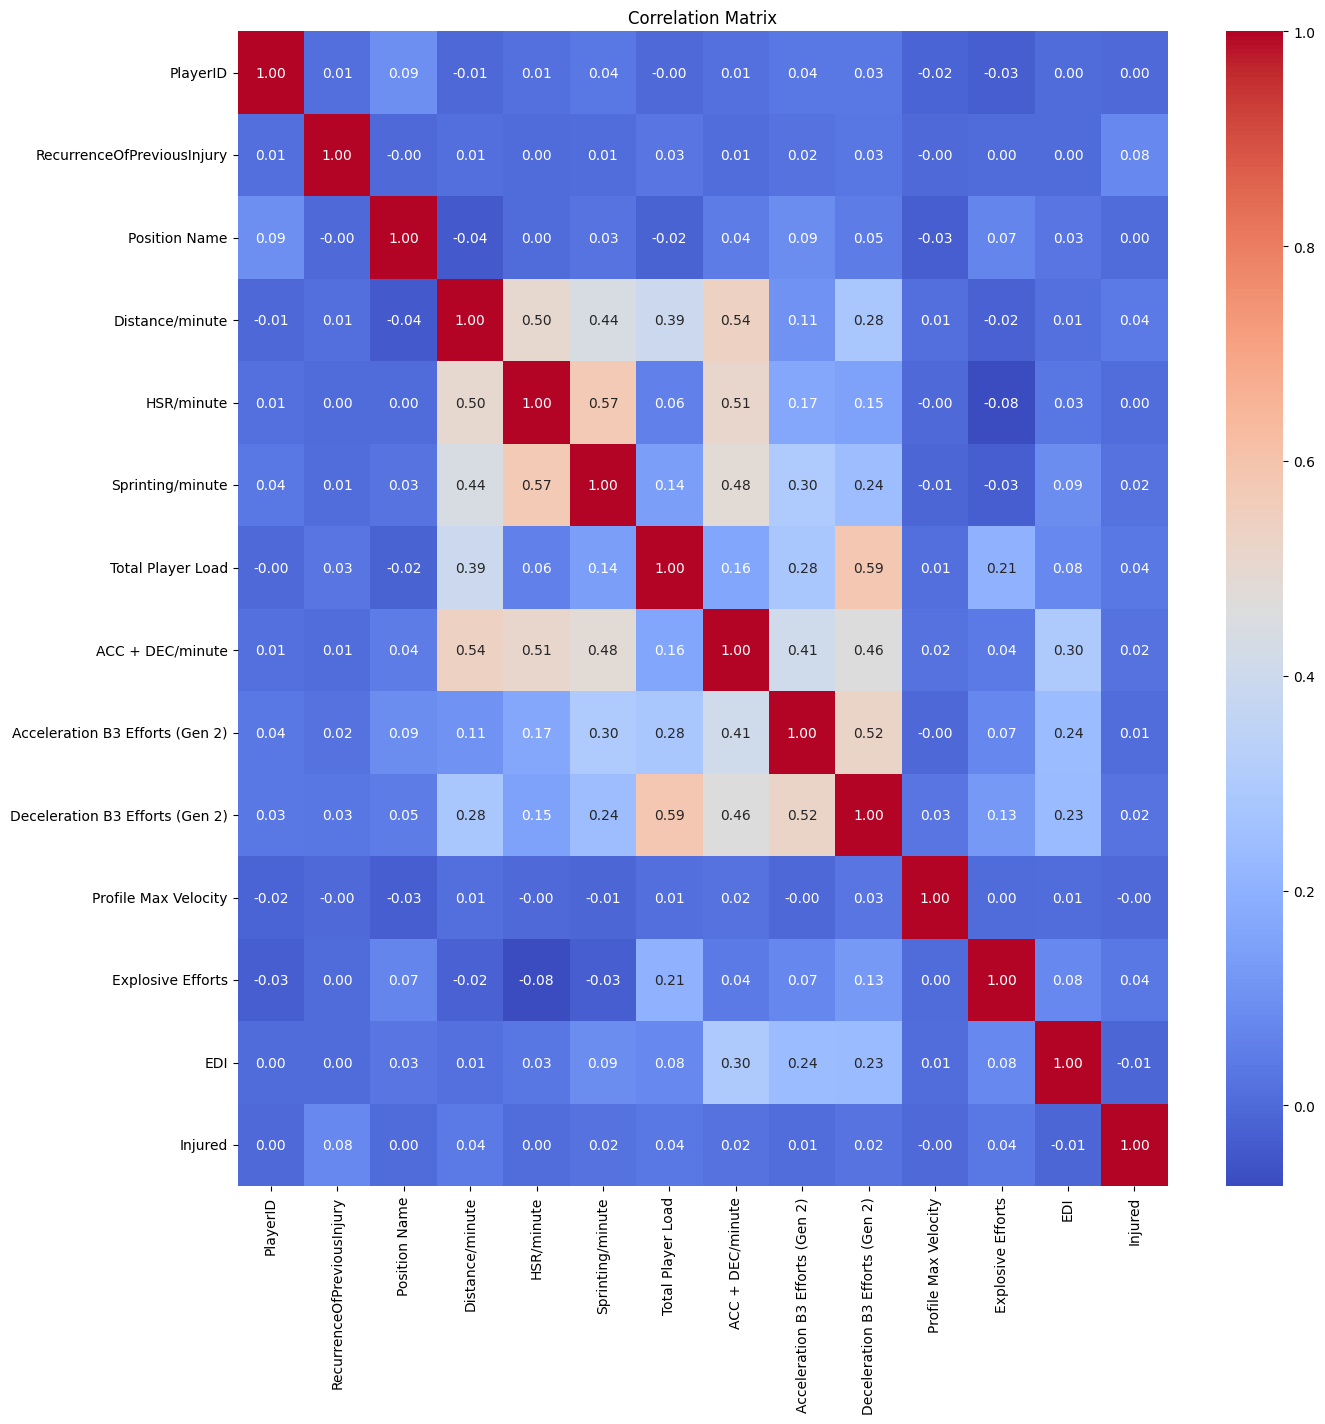

In [ ]:
# Drop correlating columns
excluded_columns = ['InjuryType', 'HSR & Sprinting', 'BodyArea',
                    'Sprinting', 'Deceleerations',
                    'Total Distance','Duration (minutes)', 'Meta Energy (Cal/kg)',
                    'Accelerations', 'Total Player Load/minute',
                    'ACC + DEC', 'Period Number']
ml_df = ml_df.drop(columns=excluded_columns)


# Calculate the correlation matrix
correlation_matrix = ml_df.corr()

# Plot the heatmap
plt.figure(figsize=(15, 15))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

In [ ]:
ml_df.to_csv('/content/drive/MyDrive/Ddrive/ml_data_beta.csv', index=False)

### Train Data

In [ ]:
ml_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 14191 entries, 6993 to 8381
Data columns (total 14 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   PlayerID                         14191 non-null  int64  
 1   RecurrenceOfPreviousInjury       14191 non-null  int64  
 2   Position Name                    14191 non-null  float64
 3   Distance/minute                  14191 non-null  float64
 4   HSR/minute                       14191 non-null  float64
 5   Sprinting/minute                 14191 non-null  float64
 6   Total Player Load                14191 non-null  int64  
 7   ACC + DEC/minute                 14191 non-null  float64
 8   Acceleration B3 Efforts (Gen 2)  14191 non-null  float64
 9   Deceleration B3 Efforts (Gen 2)  14191 non-null  float64
 10  Profile Max Velocity             14191 non-null  float64
 11  Explosive Efforts                14191 non-null  int64  
 12  EDI                  

In [ ]:

def scale_dataset(data, oversample=False):
    # Convert datetime column to numerical representation
    #data['Date'] = pd.to_numeric(data['Date'])

    # Separate features and target variable
    X = data.drop(columns=['Injured'])
    y = data['Injured']

    # Split the dataset into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=12)

    # Oversample the training set if specified
    # Oversample the training set using SMOTE
    smote = SMOTE(random_state=12)
    X_train, y_train = smote.fit_resample(X_train, y_train)


    return (X_train, y_train), (X_test, y_test)

# Assuming 'train' is your dataset
(train_X, train_y), (test_X, test_y) = scale_dataset(ml_df, oversample=True)


print("Shape of x_train :", train_X.shape)
print("Shape of y_train :", train_y.shape)
print("Shape of x_test :", test_X.shape)
print("Shape of y_test :", test_y.shape)

Shape of x_train : (22462, 13)
Shape of y_train : (22462,)
Shape of x_test : (2839, 13)
Shape of y_test : (2839,)


In [ ]:
# Check the distribution of the target class in each dataset
train_class_distribution = train_y.value_counts()
test_class_distribution = test_y.value_counts()

print("Distribution of the target class in training set:")
print(train_class_distribution)

print("\nDistribution of the target class in testing set:")
print(test_class_distribution)

Distribution of the target class in training set:
Injured
0    11231
1    11231
Name: count, dtype: int64

Distribution of the target class in testing set:
Injured
0    2804
1      35
Name: count, dtype: int64


#### Random Forest

Train Accuracy:  0.9999109607336836
Test Accuracy:  0.9873194786896795
recall score: 0.05714285714285714
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      2804
           1       0.40      0.06      0.10        35

    accuracy                           0.99      2839
   macro avg       0.69      0.53      0.55      2839
weighted avg       0.98      0.99      0.98      2839



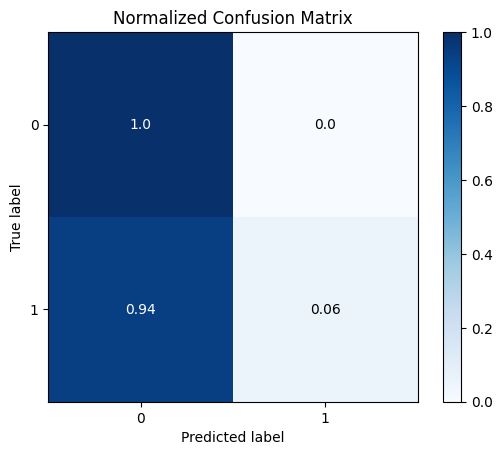

In [ ]:
model = RandomForestClassifier()
rf_model1 = model.fit(train_X, train_y)

rf_y_pred = rf_model1.predict(test_X)

# evaluating the model
print("Train Accuracy: ", rf_model1.score(train_X, train_y))
print("Test Accuracy: ", rf_model1.score(test_X, test_y))

# recall score
rf_recall = recall_score(test_y, rf_y_pred)
print("recall score:", rf_recall)
# Confusion Matrix
rf_confusion_m = skplt.metrics.plot_confusion_matrix(test_y, rf_y_pred, normalize=True)

# Classification report
print(classification_report(test_y, rf_y_pred))

#### Decision Tree

Train Accuracy:  0.9999109607336836
Test Accuracy:  0.9718210637548432
recall score: 0.17142857142857143
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      2804
           1       0.11      0.17      0.13        35

    accuracy                           0.97      2839
   macro avg       0.55      0.58      0.56      2839
weighted avg       0.98      0.97      0.98      2839



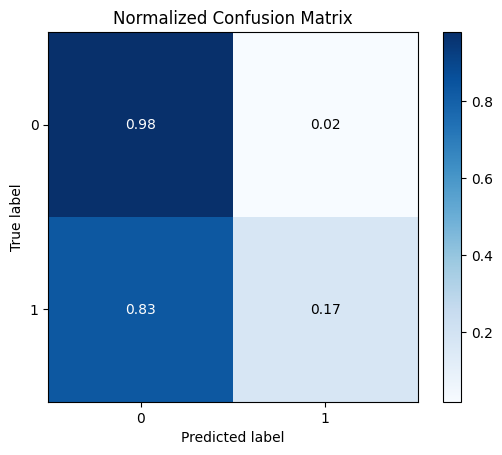

In [ ]:
# Model definition and training
dt_model = DecisionTreeClassifier()
dt_model = dt_model.fit(train_X, train_y)
dt_y_pred = dt_model.predict(test_X)

# evaluating the model
print("Train Accuracy: ", dt_model.score(train_X, train_y))
print("Test Accuracy: ", dt_model.score(test_X, test_y))

# recall score
dt_recall = recall_score(test_y, dt_y_pred)
print("recall score:", dt_recall)
# Confusion Matrix
dt_confusion_m = skplt.metrics.plot_confusion_matrix(test_y, dt_y_pred, normalize=True)

# Classification report
print(classification_report(test_y, dt_y_pred))

#### Extreme Gradient Boosting

Train Accuracy:  0.9997774018342089
Test Accuracy:  0.9876717153927439
recall score: 0.05714285714285714
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      2804
           1       0.50      0.06      0.10        35

    accuracy                           0.99      2839
   macro avg       0.74      0.53      0.55      2839
weighted avg       0.98      0.99      0.98      2839



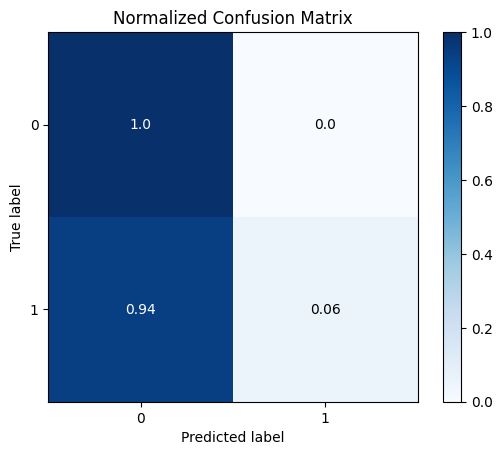

In [ ]:
# Model definition and training
gb_model = XGBClassifier()
gb_model = gb_model.fit(train_X,train_y)
gb_y_pred = gb_model.predict(test_X)

# evaluating the model
print("Train Accuracy: ", gb_model.score(train_X, train_y))
print("Test Accuracy: ", gb_model.score(test_X, test_y))

# recall score
gb_recall = recall_score(test_y, gb_y_pred)
print("recall score:", gb_recall)
# Confusion Matrix
gb_confusion_m = skplt.metrics.plot_confusion_matrix(test_y, gb_y_pred, normalize=True)

# Classification report
print(classification_report(test_y, gb_y_pred))

#### Logistic Regression

Train Accuracy:  0.6294185735909537
Test Accuracy:  0.6199365973934484
recall score: 0.7428571428571429
              precision    recall  f1-score   support

           0       0.99      0.62      0.76      2804
           1       0.02      0.74      0.05        35

    accuracy                           0.62      2839
   macro avg       0.51      0.68      0.40      2839
weighted avg       0.98      0.62      0.75      2839



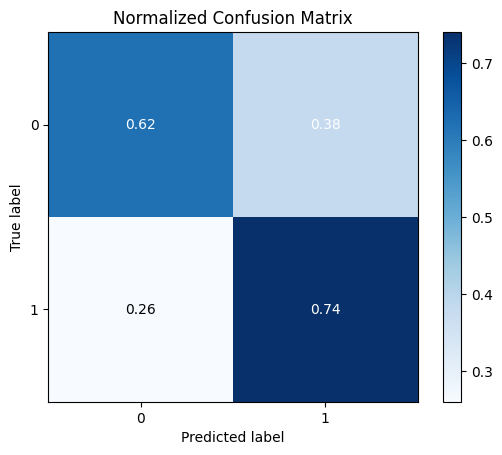

In [ ]:
# Model definition and training
lg_model = LogisticRegression()
lg_model = lg_model.fit(train_X, train_y)
lg_y_pred = lg_model.predict(test_X)

# evaluating the model
print("Train Accuracy: ", lg_model.score(train_X, train_y))
print("Test Accuracy: ", lg_model.score(test_X, test_y))

# recall score
lg_recall = recall_score(test_y, lg_y_pred)
print("recall score:", lg_recall)

# Confusion Matrix
lg_confusion_m = skplt.metrics.plot_confusion_matrix(test_y, lg_y_pred, normalize=True)

# Classification report
print(classification_report(test_y, lg_y_pred))

### Training Summary

In [ ]:
# Model Summary

#give model report in dataframe
def model_report(model,train_x,train_y,test_x,test_y,name):
    model.fit(train_x,train_y)
    predictions  = model.predict(test_x)
    accuracy     = accuracy_score(test_y,predictions)
    recallscore  = recall_score(test_y,predictions)
    precision    = precision_score(test_y,predictions)
    f1score      = f1_score(test_y,predictions)
    df = pd.DataFrame({"Model"           : [name],
                       "Accuracy_score"  : [accuracy],
                       "Recall_score"    : [recallscore],
                       "Precision"       : [precision],
                       "f1_score"        : [f1score]
                      })
    return df

# outline models

model3 = model_report(lg_model,train_X,train_y,test_X,test_y, "Logistic Regression")
model5 = model_report(dt_model,train_X,train_y,test_X,test_y, "Decision Trees")
model6 = model_report(gb_model,train_X,train_y,test_X,test_y, "Gradient Boost")
model7 = model_report(rf_model1,train_X,train_y,test_X,test_y, "Random Forest")

# Concat models
model_all = pd.concat([model3,model5,model6,model7],axis = 0).reset_index()
model_all = model_all.drop(columns = "index",axis =1)

model_all

,Model,Accuracy_score,Recall_score,Precision,f1_score
0,Logistic Regression,0.619937,0.742857,0.023723,0.045977
1,Decision Trees,0.971117,0.114286,0.072727,0.088889
2,Gradient Boost,0.987672,0.057143,0.500000,0.102564
3,Random Forest,0.986615,0.057143,0.285714,0.095238


### HyperParameter Tuning

In [ ]:
x_train = train_X
y_train = train_y
x_test = test_X
y_test = test_y

# Making set of parameters to test
para_grid = {
    'n_estimators': [int(i) for i in np.linspace(start=1, stop=100, num=5)], # any 5 numbers between 1 and 100
    'max_features': ['auto','sqrt','log2'],
    'criterion': ['entropy','gini'],
    'max_depth': [3, 5, 7, 9]
}
cv = StratifiedKFold()
# running
rscv = RandomizedSearchCV(estimator=rf_model1, param_distributions=para_grid, n_iter=100, cv=cv, verbose=0, n_jobs=-1)

#training to find best parameters
rscv.fit(x_train, y_train)

RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=False),
                   estimator=RandomForestClassifier(), n_iter=100, n_jobs=-1,
                   param_distributions={'criterion': ['entropy', 'gini'],
                                        'max_depth': [3, 5, 7, 9],
                                        'max_features': ['auto', 'sqrt',
                                                         'log2'],
                                        'n_estimators': [1, 25, 50, 75, 100]})

In [ ]:
# getting the best parameters
rscv.best_params_

{'n_estimators': 75,
 'max_features': 'sqrt',
 'max_depth': 9,
 'criterion': 'gini'}

Train Accuracy:  0.9575727896002137
Test Accuracy:  0.8957379358929201
recall score: 0.2
Precision: 0.025454545454545455
F1 Score: 0.04516129032258065
              precision    recall  f1-score   support

           0       0.99      0.90      0.94      2804
           1       0.03      0.20      0.05        35

    accuracy                           0.90      2839
   macro avg       0.51      0.55      0.50      2839
weighted avg       0.98      0.90      0.93      2839



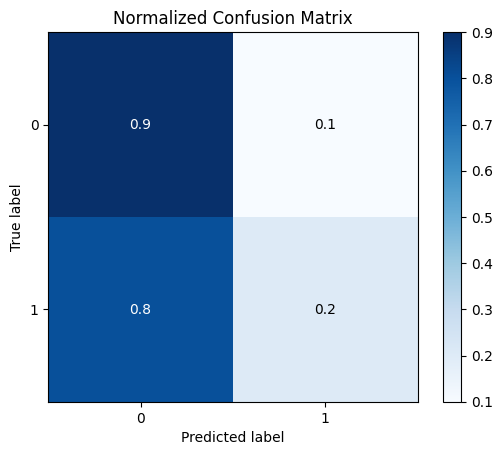

In [ ]:
# train model with best parameters found
optimized_rf_model = RandomForestClassifier(**rscv.best_params_)
optimized_rf_model.fit(x_train, y_train)
optimized_rf_y_pred = optimized_rf_model.predict(x_test)

# evaluating the model
print("Train Accuracy: ", optimized_rf_model.score(x_train, y_train))
print("Test Accuracy: ", optimized_rf_model.score(x_test, y_test))

# recall score
opt_rf_recall = recall_score(y_test, optimized_rf_y_pred)
opt_rf_precision = precision_score(y_test, optimized_rf_y_pred)
opt_rf_f1score = f1_score(y_test, optimized_rf_y_pred)

print("recall score:", opt_rf_recall)
print("Precision:", opt_rf_precision)
print("F1 Score:", opt_rf_f1score)

# Confusion Matrix
optimized_rf_confusion_m = skplt.metrics.plot_confusion_matrix(y_test, optimized_rf_y_pred, normalize=True)

# Classification report
print(classification_report(y_test, optimized_rf_y_pred))

In [ ]:
# Making set of parameters to test
param_grid = {
    'n_estimators': [int(i) for i in np.linspace(start=1, stop=100, num=5)], # any 5 numbers between 1 and 100
    'learning_rate': [0.001, 0.01, 0.1],
    'max_features': ['auto','sqrt','log2'],
    'criterion': ['friedman_mse', 'squared_error']
}
cv = StratifiedKFold()

# running
gscv = GridSearchCV(estimator=gb_model, param_grid=param_grid, cv=cv, verbose=0, n_jobs=-1)

#training to find best parameters
gscv.fit(x_train, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=False),
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, gamma=None,
                                     grow_policy=None, importance_...
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None,
                                     random_state=None, ...),
             n_jobs=-1,
             param_grid={'criterion': ['friedman_mse', 'squared_error'],
                         'learning_rate': [0.001, 0.01, 0.1],
                         'max_features': ['auto', 'sqrt', 'log2'],
                         'n_estimators': [1, 25, 50, 75, 100]})

In [ ]:
# getting the best parameters
gscv.best_params_

{'criterion': 'friedman_mse',
 'learning_rate': 0.1,
 'max_features': 'auto',
 'n_estimators': 100}

Train Accuracy:  0.9945240851215386
Test Accuracy:  0.9855582951743571
recall score: 0.02857142857142857
Precision: 0.125
F1 Score: 0.04651162790697674
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      2804
           1       0.12      0.03      0.05        35

    accuracy                           0.99      2839
   macro avg       0.56      0.51      0.52      2839
weighted avg       0.98      0.99      0.98      2839



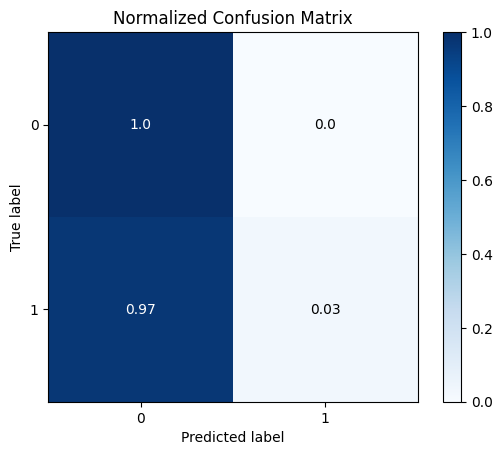

In [ ]:
# train model with best parameters found
optimized_gb_model = XGBClassifier(**gscv.best_params_)
optimized_gb_model.fit(x_train, y_train)
optimized_gb_y_pred = optimized_gb_model.predict(x_test)

# evaluating the model
print("Train Accuracy: ", optimized_gb_model.score(x_train, y_train))
print("Test Accuracy: ", optimized_gb_model.score(x_test, y_test))

# recall score
opt_gb_recall = recall_score(y_test, optimized_gb_y_pred)
opt_gb_precision = precision_score(y_test, optimized_gb_y_pred)
opt_gb_f1score = f1_score(y_test, optimized_gb_y_pred)

print("recall score:", opt_gb_recall)
print("Precision:", opt_gb_precision)
print("F1 Score:", opt_gb_f1score)
# Confusion Matrix
optimized_gb_confusion_m = skplt.metrics.plot_confusion_matrix(y_test, optimized_gb_y_pred, normalize=True)

# Classification report
print(classification_report(y_test, optimized_gb_y_pred))

In [ ]:
# Save the trained model
joblib.dump(optimized_gb_model, 'xgb_model.pkl')

# Load the saved model
#loaded_model = joblib.load('xgb_model.pkl')
# Load the saved model
#loaded_model = joblib.load('xgb_model.pkl')

# Make predictions on new data
#new_data = ... # Load or prepare your new data
#predictions = loaded_model.predict(new_data)
# Import the required functions

# Save the trained model
optimized_gb_model.save_model('/content/drive/MyDrive/Ddrive/xgb_model.json')

# Load the saved model
loaded_model = xgb.XGBClassifier()
loaded_model.load_model('/content/drive/MyDrive/Ddrive/xgb_model.json')

In [ ]:
# Create DecisionTreeClassifier object
dt_model = DecisionTreeClassifier()

# Define the set of parameters to test
param_grid = {
    'max_depth': [3, 5, 7, 9],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['auto', 'sqrt', 'log2'],
    'criterion': ['entropy', 'gini']
}

# Define cross-validation strategy
cv = StratifiedKFold()

# Instantiate RandomizedSearchCV
dtcv = RandomizedSearchCV(estimator=dt_model, param_distributions=param_grid, n_iter=100, cv=cv, verbose=1, n_jobs=-1)

# Fit the RandomizedSearchCV instance
dtcv.fit(x_train, y_train)


Fitting 5 folds for each of 100 candidates, totalling 500 fits


RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=False),
                   estimator=DecisionTreeClassifier(), n_iter=100, n_jobs=-1,
                   param_distributions={'criterion': ['entropy', 'gini'],
                                        'max_depth': [3, 5, 7, 9],
                                        'max_features': ['auto', 'sqrt',
                                                         'log2'],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10]},
                   verbose=1)

In [ ]:
# Print the best parameters found
dtcv.best_params_

{'min_samples_split': 2,
 'min_samples_leaf': 4,
 'max_features': 'sqrt',
 'max_depth': 9,
 'criterion': 'gini'}

Train Accuracy:  0.8824236488291336
Test Accuracy:  0.7935892920042268
recall score: 0.4
Precision: 0.024179620034542316
F1 Score: 0.04560260586319218
              precision    recall  f1-score   support

           0       0.99      0.80      0.88      2804
           1       0.02      0.40      0.05        35

    accuracy                           0.79      2839
   macro avg       0.51      0.60      0.46      2839
weighted avg       0.98      0.79      0.87      2839



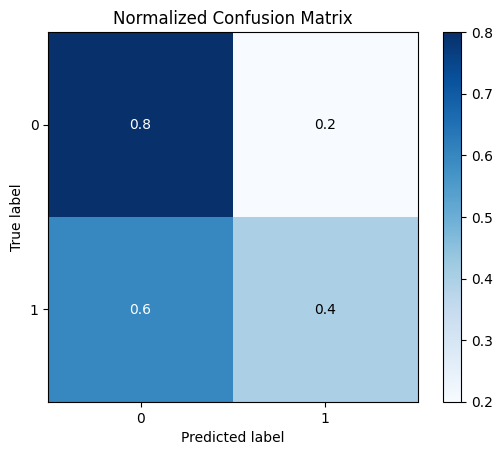

In [ ]:
# train model with best parameters found
optimized_dt_model = DecisionTreeClassifier(**dtcv.best_params_)
optimized_dt_model.fit(x_train, y_train)
optimized_dt_y_pred = optimized_dt_model.predict(x_test)

# evaluating the model
print("Train Accuracy: ", optimized_dt_model.score(x_train, y_train))
print("Test Accuracy: ", optimized_dt_model.score(x_test, y_test))

# recall score
opt_dt_recall = recall_score(y_test, optimized_dt_y_pred)
opt_dt_precision = precision_score(y_test, optimized_dt_y_pred)
opt_dt_f1score = f1_score(y_test, optimized_dt_y_pred)

print("recall score:", opt_dt_recall)
print("Precision:", opt_dt_precision)
print("F1 Score:", opt_dt_f1score)

# Confusion Matrix
optimized_dt_confusion_m = skplt.metrics.plot_confusion_matrix(y_test, optimized_dt_y_pred, normalize=True)

# Classification report
print(classification_report(y_test, optimized_dt_y_pred))

### SHAP

Shape of sample_df2: (100, 13)
Shape of SHAP values: (100, 13, 2)


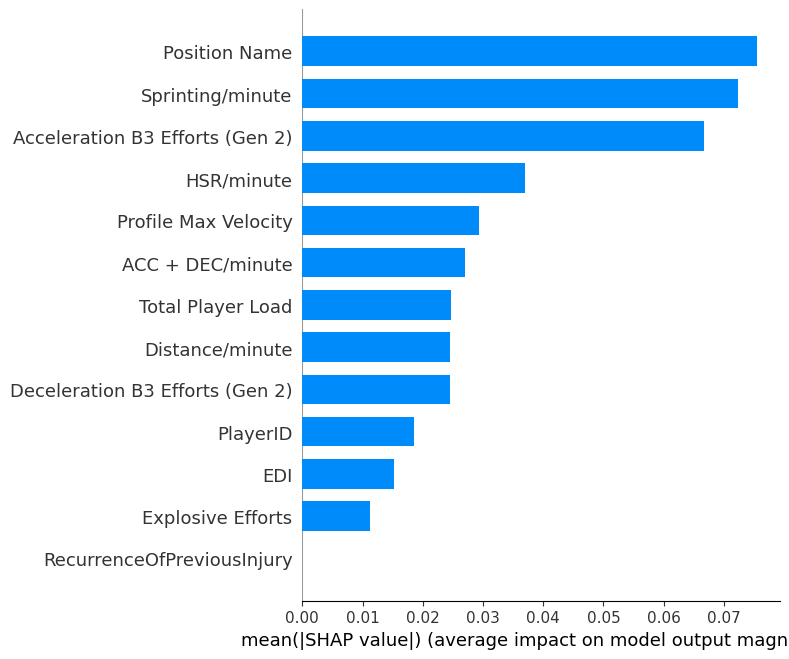

In [ ]:

# Assuming rf_model1 and ml_df are defined properly

# Assuming train_X is defined properly
sample_df = pd.DataFrame(train_X, columns=ml_df.columns[:-1])

# Sampling data
sample_df2 = sample_df.sample(n=100, random_state=10)

# Create a SHAP explainer for the random forest model
explainer = shap.TreeExplainer(optimized_rf_model)

# Compute SHAP values for the sampled data
shap_values = explainer.shap_values(sample_df2)

# Check shapes
print("Shape of sample_df2:", sample_df2.shape)
print("Shape of SHAP values:", shap_values.shape)

# Select SHAP values for the positive class (change index if needed)
shap_values_positive_class = shap_values[:, :, 1]

# Convert SHAP values to a DataFrame
shap_df = pd.DataFrame(shap_values_positive_class, columns=ml_df.columns[:-1])


# Assuming shap_values_positive_class is computed properly


# Create a summary plot
shap.summary_plot(shap_values_positive_class, sample_df2, plot_type="bar")

# Show the plot
plt.show()

Shape of sample_df2: (100, 13)
Shape of SHAP values: (100, 13)


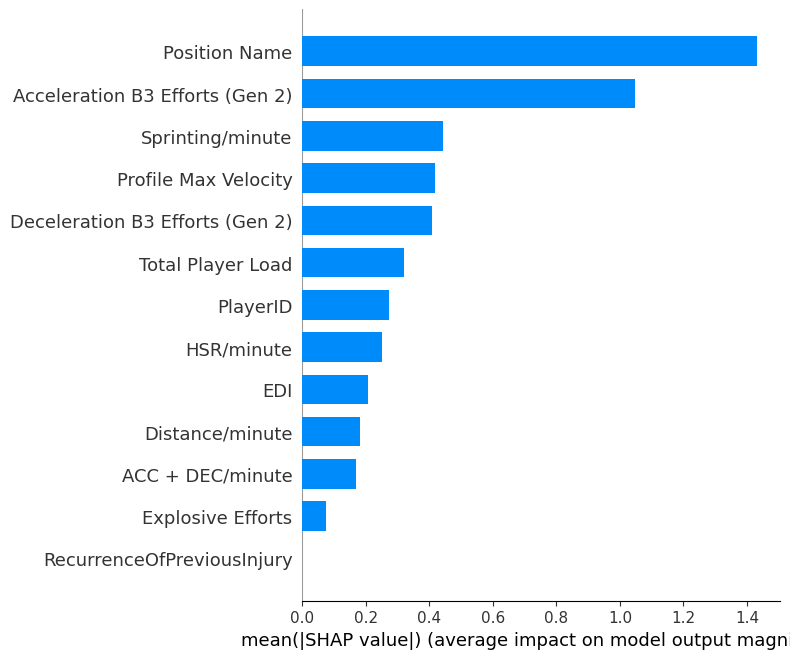

In [ ]:
# Assuming rf_model1 and ml_df are defined properly

# Assuming train_X is defined properly
sample_df = pd.DataFrame(train_X, columns=ml_df.columns[:-1])

# Sampling data
sample_df2 = sample_df.sample(n=100, random_state=10)

# Create a SHAP explainer for the gradient boost model model
explainer1 = shap.TreeExplainer(optimized_gb_model)

# Compute SHAP values for the sampled data
shap_values1 = explainer1.shap_values(sample_df2)

# Check shapes
print("Shape of sample_df2:", sample_df2.shape)
print("Shape of SHAP values:", shap_values1.shape)

# Convert SHAP values to a DataFrame
shap_df1 = pd.DataFrame(shap_values1, columns=ml_df.columns[:-1])


# Plot SHAP summary bar plot
shap.summary_plot(shap_values1, sample_df2, plot_type="bar", show=False)

# If you want to save the plot to a file, you can use savefig
#plt.savefig('shap_summary_bar_plot.png')

# Show the plot
plt.show()

### LLM

In [ ]:
ml_df1 = ml_df.copy()

# because data is much and would take longer to train
#sample_size = 5000
#ml_df1 = ml_df1.sample(n=sample_size, random_state=104)


(X_train, y_train), (X_test, y_test) = scale_dataset(ml_df1, oversample=True)


print("Shape of x_train :", X_train.shape)
print("Shape of y_train :", y_train.shape)
print("Shape of x_test :", X_test.shape)
print("Shape of y_test :", y_test.shape)

# Check the distribution of the target class in each dataset
train_class_distribution = y_train.value_counts()
test_class_distribution = y_test.value_counts()

print("Distribution of the target class in training set:")
print(train_class_distribution)

print("\nDistribution of the target class in testing set:")
print(test_class_distribution)

Shape of x_train : (22462, 13)
Shape of y_train : (22462,)
Shape of x_test : (2839, 13)
Shape of y_test : (2839,)
Distribution of the target class in training set:
Injured
0    11231
1    11231
Name: count, dtype: int64

Distribution of the target class in testing set:
Injured
0    2804
1      35
Name: count, dtype: int64


In [ ]:
# Create LLM prompt

def concatenate_text(x):
    full_text = (
        f"This player performance during training in position {x['Position Name']} shows that, ",
        f"he ran a distance of {x['Distance/minute']}, ",
        f"with HSR speed of {x['HSR/minute']} metres/min, ",
        f"and  sprinting speed {x['Sprinting/minute']}. ",
        f"The player completed {x['Explosive Efforts']} efforts, ",
        f"covering {x['Acceleration B3 Efforts (Gen 2)']} metres accelerating, ",
        f"and {x['Deceleration B3 Efforts (Gen 2)']} metres decelerating. " ,
        f"He has a Player load of {x['Total Player Load']}. "
        f"The energy usage by the player was {x['EDI']}, "
        f"with the profile max velocity being {x['Profile Max Velocity']}, "
        f"and completing {x['ACC + DEC/minute']} number of accelerations per minute of the training session"


    )
    return ''.join(full_text)



X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22462 entries, 0 to 22461
Data columns (total 13 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   PlayerID                         22462 non-null  int64  
 1   RecurrenceOfPreviousInjury       22462 non-null  int64  
 2   Position Name                    22462 non-null  float64
 3   Distance/minute                  22462 non-null  float64
 4   HSR/minute                       22462 non-null  float64
 5   Sprinting/minute                 22462 non-null  float64
 6   Total Player Load                22462 non-null  int64  
 7   ACC + DEC/minute                 22462 non-null  float64
 8   Acceleration B3 Efforts (Gen 2)  22462 non-null  float64
 9   Deceleration B3 Efforts (Gen 2)  22462 non-null  float64
 10  Profile Max Velocity             22462 non-null  float64
 11  Explosive Efforts                22462 non-null  int64  
 12  EDI               

In [ ]:
X_train['label'] = y_train
X_test['label'] = y_test

X_train['text'] = X_train.apply(lambda x: concatenate_text(x), axis=1)
X_test['text'] = X_test.apply(lambda x: concatenate_text(x), axis=1)

X_train['text'].iloc[0]

'This player performance during training in position 1.0 shows that, he ran a distance of 109.21621621621621, with HSR speed of 7.297297297297297 metres/min, and  sprinting speed 1.027027027027027. The player completed 13.0 efforts, covering 0.0 metres accelerating, and 3.0 metres decelerating. He has a Player load of 398.0. The energy usage by the player was 1.14, with the profile max velocity being 31.68, and completing 0.43243243243243246 number of accelerations per minute of the training session'

In [ ]:
# Define label mappings
id2label = {0: "NOT-INJURED", 1: "INJURED"}
label2id = {"NOT-INJURED": 0, "INJURED": 1}


# Convert to Hugging Face Dataset format
train_dataset = Dataset.from_pandas(X_train)
test_dataset = Dataset.from_pandas(X_test)

In [ ]:
# Tokenization
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

def tokenize_function(examples):
    # Adjust based on the structure of your dataset
    return tokenizer(examples['text'], padding='max_length', truncation=True, max_length=128)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

In [ ]:
tokenized_train_dataset = train_dataset.map(tokenize_function, batched=True)
tokenized_test_dataset = test_dataset.map(tokenize_function, batched=True)


# Format the datasets correctly with labels
tokenized_train_dataset = tokenized_train_dataset.map(lambda x: {'labels': x['label']})
tokenized_test_dataset = tokenized_test_dataset.map(lambda x: {'labels': x['label']})

Map:   0%|          | 0/22462 [00:00<?, ? examples/s]

Map:   0%|          | 0/2839 [00:00<?, ? examples/s]

Map:   0%|          | 0/22462 [00:00<?, ? examples/s]

Map:   0%|          | 0/2839 [00:00<?, ? examples/s]

In [ ]:
# Define the model with label mappings
model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=len(label2id),
    id2label=id2label,
    label2id=label2id
)

# Define training arguments
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=1,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    warmup_steps=100,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=100,
    evaluation_strategy="epoch"
)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
# Evaluation metric
f1 = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=1)
    return f1.compute(predictions=predictions, references=labels)

In [ ]:
# Check the shape of label arrays
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

# Check the unique values in label arrays
print("Unique values in y_train:", np.unique(y_train))
print("Unique values in y_test:", np.unique(y_test))

Shape of y_train: (22462,)
Shape of y_test: (2839,)
Unique values in y_train: [0 1]
Unique values in y_test: [0 1]


In [ ]:
# Define the trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train_dataset,
    eval_dataset=tokenized_test_dataset,
    compute_metrics=compute_metrics
)

# Train the model
trainer.train()

Epoch,Training Loss,Validation Loss,F1
1,0.014200,0.075273,0.000000


TrainOutput(global_step=1404, training_loss=0.0647435479092961, metrics={'train_runtime': 541.14, 'train_samples_per_second': 41.509, 'train_steps_per_second': 2.595, 'total_flos': 1477500131374080.0, 'train_loss': 0.0647435479092961, 'epoch': 1.0})

In [ ]:
# Evaluate the model
results = trainer.evaluate()
print(results)

{'eval_loss': 0.0752728208899498, 'eval_f1': 0.0, 'eval_runtime': 21.0375, 'eval_samples_per_second': 134.949, 'eval_steps_per_second': 8.461, 'epoch': 1.0}


In [ ]:
model.save_pretrained("/content/drive/MyDrive/Ddrive")
tokenizer.save_pretrained("/content/drive/MyDrive/Ddrive")

('/content/drive/MyDrive/Ddrive/tokenizer_config.json',
 '/content/drive/MyDrive/Ddrive/special_tokens_map.json',
 '/content/drive/MyDrive/Ddrive/vocab.txt',
 '/content/drive/MyDrive/Ddrive/added_tokens.json')

Configuration and Deployment of the model is outlined in the next Notebook